Необходимо проверить качество моделей на тестовых данных, полученных на основе полуэмпирических методов прогноза оседания земной поверхности при строительстве подземных сооружений. 

**Входные признаки модели (гиперпараметры)**
1. Координата x в поперечном направлении тоннеля (-100 до 100)
2. Тип грунтов (глинистые - 0, песчаные - 1, смешанные - 2)
3. Глубина заложения тоннеля (взято среднее значение для перегонных тоннелей в окрестности спб - 50 м)
4. Тип тоннеля - одиночный тоннель
5. Технология строительства - щитовая проходка (ТМПК)
6. Параметр K, характеризующий ширину мульды оседания земной поверхности (0,5 - глинистые грунты; 0,35 - песчаные; 0,4 - смещанные)

**Параметры, которые зависят от гиперпараметров, но которые так же относятся к признакам модели**
1. Расстояние от центра тоннеля до точки перегиба ix (18,4 - для глинистых грунтов; 15 - для песчаных, 17,4 - для смешанных)
2. GLR - Относительное значение потерянного объема сечения тоннеля  (2% - для глинистых; 1,5 - для песчаных; 1 - смешанные)
3. Величина максимальной осадки земной поверхности над продольной осью тоннеля - будет считаться при обработке данных

**Целевая переменная**
1. Вертикальные осадки земной поверхности

    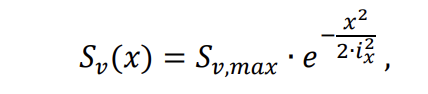
2. Горизонтальные абсолютные деформации земной поверхности

    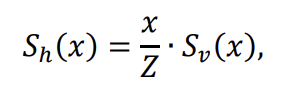
3. Относительные горизонтальные деформации земной поверхности в поперечном направлении.

    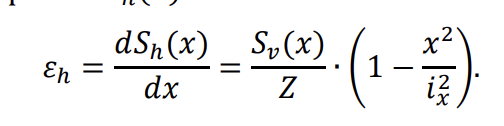




Порядок работы:
1. Подготовим данные:
    - из общих данных удалим столбцы с целевыми метками и с максимальными оседаниями, чтобы посчитать их через питон.
    - посчитаем эти столбцы
    - разделенеи выборки на тестовую и обучающуюся
2. Обучение трех моделей: 
    - градиентный бустинг, 
    - рекуррентная НС,
    -  случайный лес 
3. Выборка модели с меньшей ошибкой на тестовой выборке
4. Построение графика предсказаний модели и исходного ряда


## Подготовка данных и признаков

In [102]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 1.8 MB/s eta 0:00:00a 0:00:01


In [134]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import math
import time

from sklearn.preprocessing import LabelEncoder
from keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense,Dropout
from tensorflow.keras.optimizers import Adam
import xgboost as xgb

from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error,mean_absolute_error

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

In [148]:
data_600 = pd.read_excel('/Users/sofagusina/Desktop/учеба/Диплом/Код/Калибровка моделей/Выборки разных размеров для одного тоннеля/Модель 10,4.xlsx')
data_1800 = pd.read_excel('/Users/sofagusina/Desktop/учеба/Диплом/Код/Калибровка моделей/Выборки разных размеров для одного тоннеля/1800.xlsx')
data_4800 = pd.read_excel('/Users/sofagusina/Desktop/учеба/Диплом/Код/Калибровка моделей/Выборки разных размеров для одного тоннеля/4800.xlsx')
data_7200 = pd.read_excel('/Users/sofagusina/Desktop/учеба/Диплом/Код/Калибровка моделей/Выборки разных размеров для одного тоннеля/7200.xlsx')
data_14400 = pd.read_excel('/Users/sofagusina/Desktop/учеба/Диплом/Код/Калибровка моделей/Выборки разных размеров для одного тоннеля/14400.xlsx')
data_28800 = pd.read_excel('/Users/sofagusina/Desktop/учеба/Диплом/Код/Калибровка моделей/Выборки разных размеров для одного тоннеля/28800.xlsx')


In [75]:
data_600

,x,y,Тип грунтов,ix,K,"Диаметр тоннеля, м",Тип тоннеля,Технология строительства,GLR %,"Глубина заложения тоннеля, м","Svmax, мм",Sv(x),"Sh(x), мм",εh
0,-100,NaN,Глинистые,NaN,0.6,10.4,Одиночный,ТПМК,0.5,15,NaN,NaN,NaN,NaN
1,-99,NaN,Глинистые,NaN,0.6,10.4,Одиночный,ТПМК,0.5,15,NaN,NaN,NaN,NaN
2,-98,NaN,Глинистые,NaN,0.6,10.4,Одиночный,ТПМК,0.5,15,NaN,NaN,NaN,NaN
3,-97,NaN,Глинистые,NaN,0.6,10.4,Одиночный,ТПМК,0.5,15,NaN,NaN,NaN,NaN
4,-96,NaN,Глинистые,NaN,0.6,10.4,Одиночный,ТПМК,0.5,15,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
598,96,NaN,Смешанные,NaN,0.5,10.4,Одиночный,ТПМК,0.5,15,NaN,NaN,NaN,NaN
599,97,NaN,Смешанные,NaN,0.5,10.4,Одиночный,ТПМК,0.5,15,NaN,NaN,NaN,NaN
600,98,NaN,Смешанные,NaN,0.5,10.4,Одиночный,ТПМК,0.5,15,NaN,NaN,NaN,NaN
601,99,NaN,Смешанные,NaN,0.5,10.4,Одиночный,ТПМК,0.5,15,NaN,NaN,NaN,NaN


In [76]:
# Новый датасет
new_data = pd.DataFrame([
    {'x': -50, 'Тип грунтов': 'Глинистые', 'K': 0.5, 'Диаметр тоннеля, м': 10.4,
     'Тип тоннеля': 'Одиночный', 'Технология строительства': 'ТПМК', 'GLR %': 0.5, 'Глубина заложения тоннеля, м': 25},
    {'x': 10, 'Тип грунтов': 'Смешанные', 'K': 0.6, 'Диаметр тоннеля, м': 10.4,
     'Тип тоннеля': 'Одиночный', 'Технология строительства': 'ТПМК', 'GLR %': 0.5, 'Глубина заложения тоннеля, м': 30},
    {'x': -10, 'Тип грунтов': 'Песчаные', 'K': 0.4, 'Диаметр тоннеля, м': 10.4,
     'Тип тоннеля': 'Одиночный', 'Технология строительства': 'ТПМК', 'GLR %': 0.5, 'Глубина заложения тоннеля, м': 15},
    {'x': 50, 'Тип грунтов': 'Смешанные', 'K': 0.5, 'Диаметр тоннеля, м': 10.4,
     'Тип тоннеля': 'Одиночный', 'Технология строительства': 'ТПМК', 'GLR %': 0.5, 'Глубина заложения тоннеля, м': 20},
])
y_true = [-1.34953546e-03, -9.40439551e+00, -2.11095311e+00, -5.19913987e-05]

## Градиентный бустинг

### Класс для обучения модели градиентного бустинга

In [271]:
class TunnelSettlementModel:
    def __init__(self, main_data, new_data=None):
        self.main_data_raw = main_data.copy()
        self.new_data_raw = new_data.copy() if new_data is not None else None
        self.data = None
        self.model = None
        self.label_encoders = {}  # для категориальных колонок
        self.prepared_X = None
        self.prepared_Y = None
        self.prepared_new_X = None
        self.prepare_main_data()
        if self.new_data_raw is not None:
            self.prepare_new_data()

    """Функции расчета признаков"""
    @staticmethod
    def calc_ix(row):
        ix = 0
        if row['Тип грунтов'] == 'Глинистые':
            ix = 0.4 * row['Глубина заложения тоннеля, м'] + 1.6
        elif row['Тип грунтов'] == 'Песчаные':
            ix = 0.28 * row['Глубина заложения тоннеля, м'] - 0.1
        elif row['Тип грунтов'] == 'Смешанные':
            ix = 0.4 * row['Глубина заложения тоннеля, м'] + 1.92
        return ix

    @staticmethod
    def calc_feature_Sv_max(row):
        return ((np.pi * (row['Диаметр тоннеля, м'])**2 * (row['GLR %'] / 100)) /
                (4 * row['ix'] * (2 * np.pi)**0.5)) * 1000

    @staticmethod
    def calc_feature_S_v(row):
        return -row['Sv_max'] * np.exp(-(row['x']**2) / (2 * row['ix']**2))


    """Функции для подготовки основного датасета"""
    def prepare_main_data(self):
        data = self.main_data_raw.copy()
        data = data[['x','Тип грунтов','K','Диаметр тоннеля, м',
                     'Тип тоннеля','Технология строительства',
                     'GLR %','Глубина заложения тоннеля, м']]

        # Вычисляем признаки
        data['ix'] = data.apply(self.calc_ix, axis=1)
        data['Sv_max'] = data.apply(self.calc_feature_Sv_max, axis=1)
        data['Sv'] = data.apply(self.calc_feature_S_v, axis=1)

        # Кодируем категориальные переменные 
        for col in ['Технология строительства','Тип грунтов','Тип тоннеля']:
            le = LabelEncoder()
            data[col] = le.fit_transform(data[col])
            self.label_encoders[col] = le

        # Проверка и очистка данных от нулевых значений
        data.replace([np.inf, -np.inf], np.nan, inplace=True)
        data.dropna(inplace=True)

        self.data = data
        self.prepared_X = data[['x','Тип грунтов','ix','K','Диаметр тоннеля, м',
                                'Тип тоннеля','Технология строительства',
                                'GLR %','Глубина заложения тоннеля, м','Sv_max']]
        self.prepared_Y = data['Sv']

    """Подготовка данных для анализа качества работы модели"""
    def prepare_new_data(self):
        if self.new_data_raw is None:
            return None
        data = self.new_data_raw.copy()
        data = data[['x','Тип грунтов','K','Диаметр тоннеля, м',
                     'Тип тоннеля','Технология строительства',
                     'GLR %','Глубина заложения тоннеля, м']]
        data['ix'] = data.apply(self.calc_ix, axis=1)
        data['Sv_max'] = data.apply(self.calc_feature_Sv_max, axis=1)

        # Кодируем категориальные с использованием тех же LabelEncoder, что и на основном датасете
        for col in ['Тип грунтов','Тип тоннеля','Технология строительства']:
            le = self.label_encoders.get(col, LabelEncoder())
            data[col] = le.transform(data[col])
            self.label_encoders[col] = le

        data.replace([np.inf, -np.inf], np.nan, inplace=True)
        data.dropna(inplace=True)

        self.prepared_new_X = data

    """Обучение модели"""
    def train_model(self):
        X_train, X_test, y_train, y_test = train_test_split(
            self.prepared_X, self.prepared_Y, test_size=0.2, random_state=42
        )

        # # Подбор параметров для градиентного бустинга
        # param_grid = {
        #     'n_estimators':[5,10,25,50,100,200,500],
        #     'learning_rate':[0.01,0.05,0.1,1],
        #     'min_samples_split':[2,5,10,15,20]
        # }
   

        start_time = time.time()
        # grid = GridSearchCV(GradientBoostingRegressor(random_state=10),
        #                     param_grid, cv=min(5, len(X_train)))
        # grid.fit(X_train, y_train)
        # print(f"Лучшие параметры: {grid.best_params_}")

        # Обучаем модель с лучшими параметрами

        self.model = xgb.XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            objective='reg:pseudohubererror',  # <-- устойчиво к выбросам
            random_state=10
        )
        if len(self.prepared_X) >= 5000:
            self.model = xgb.XGBRegressor(
                n_estimators=500,
                learning_rate=0.03,
                max_depth=6,
                min_child_weight=5,
                subsample=0.8,
                colsample_bytree=0.8,
                objective='reg:pseudohubererror',
                random_state=10
            )
        # self.model = GradientBoostingRegressor(
        #     n_estimators=grid.best_params_['n_estimators'],
        #     learning_rate=grid.best_params_['learning_rate'],
        #     min_samples_split=grid.best_params_['min_samples_split'],
        #     random_state=10
        # )
        self.model.fit(
                X_train, y_train,
            )

        end_time = time.time()  # <-- сохраняем время окончания
        elapsed_time = end_time - start_time  # время в секундах
        # Проверка точности
        y_train_pred = self.model.predict(X_train)
        y_test_pred = self.model.predict(X_test)
        train_rmse = mean_squared_error(y_train, y_train_pred, squared=False)
        test_rmse = mean_squared_error(y_test, y_test_pred, squared=False)
        test_mae = mean_absolute_error(y_test, y_test_pred)
        print(f"Train Score: {train_rmse:.2e} RMSE")
        print(f"Test Score: {test_rmse:.2e} RMSE")

        # Добавляем предсказания в основной датасет
        self.data['Sv_pred'] = self.model.predict(self.prepared_X)

        return {'test_score':test_mae, 'elapsed_time': elapsed_time}

    """Оценка качества модели на новых данных"""
    def check_new_data(self, new_data, y_true):
        self.new_data_raw = new_data
        self.prepare_new_data()
        X_new = self.prepared_new_X[self.model.feature_names_in_]

        y_pred = self.model.predict(X_new)

        RMSE = mean_squared_error(y_true, y_pred, squared=False)
        MAE = mean_absolute_error(y_true, y_pred)

        print(f"Предсказанные значения: {np.array(y_pred)}")
        print(f"Истинные значения: {np.array(y_true)}")
        print(f"Ошибка RMSE: {RMSE:.5e}, ошибка MAE: {MAE:.5e}")
        return {'y_pred':y_pred,'MAE':MAE}

    """Визуализация результатов работы модели"""
    def plot_result(self, type_soil, column_pred='Sv_pred', column='Sv', ax=None):
        subset = self.data[(self.data['x'] >= -100) & (self.data['x'] <= 100)]

        # 2. Фильтр по типу грунта
        if type_soil == 'Глинистые грунты':
            subset = subset[subset["Тип грунтов"] == 0]
        elif type_soil == 'Песчаные грунты':
            subset = subset[subset["Тип грунтов"] == 1]
        elif type_soil == 'Смешанные грунты':
            subset = subset[subset["Тип грунтов"] == 2]
        else:
            raise ValueError(f"Неизвестный тип грунта: {type_soil}")

        # 3. (Если нужно) оставить только первые уникальные x
        subset = subset.iloc[:subset['x'].nunique()]

        if ax is None:
            ax = plt.gca()

        real_line = ax.plot(
            subset["x"], subset[column],
            color="#3A7CA5", linewidth=2.2, linestyle='-',
            label="Реальное значение Sv"
        )
        pred_line = ax.plot(
            subset["x"], subset[column_pred],
            color="#E36C48", linewidth=2.2, linestyle='--',
            label="Предсказанное значение Sv"
        )

        ax.set_title(type_soil, fontsize=12, pad=10)
        ax.set_xlabel("x, м", fontsize=11)
        ax.set_ylabel("Sv, мм", fontsize=11)
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.spines['bottom'].set_position('zero')
        ax.spines['top'].set_visible(False)
        ax.spines['left'].set_color('#444')
        ax.spines['bottom'].set_color('#444')
        ax.tick_params(axis='both', which='major', labelsize=10)

        return real_line[0], pred_line[0]

    def vizual_result(self):
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        line1_real, line1_pred = self.plot_result('Глинистые грунты', ax=axes[0])
        line2_real, line2_pred = self.plot_result('Песчаные грунты', ax=axes[1])
        line3_real, line3_pred = self.plot_result('Смешанные грунты', ax=axes[2])

        fig.suptitle(
            "Сравнение реальных и предсказанных значений Sv",
            fontsize=16, fontweight='bold'
        )
        fig.legend(
            handles=[line1_real, line1_pred],
            labels=["Реальное значение Sv", "Предсказанное значение Sv"],
            loc='lower center',
            ncol=2,
            frameon=False,
            fontsize=12,
            bbox_to_anchor=(0.5, -0.05)
        )
        plt.tight_layout(rect=[0, 0.05, 1, 0.95])
        plt.show()


### Результаты работы модели Градиентно Бустинга

Лучшие параметры: {'learning_rate': 1, 'min_samples_split': 10, 'n_estimators': 100}
Train Score: 3.09e-02 RMSE
Test Score: 6.15e-01 RMSE


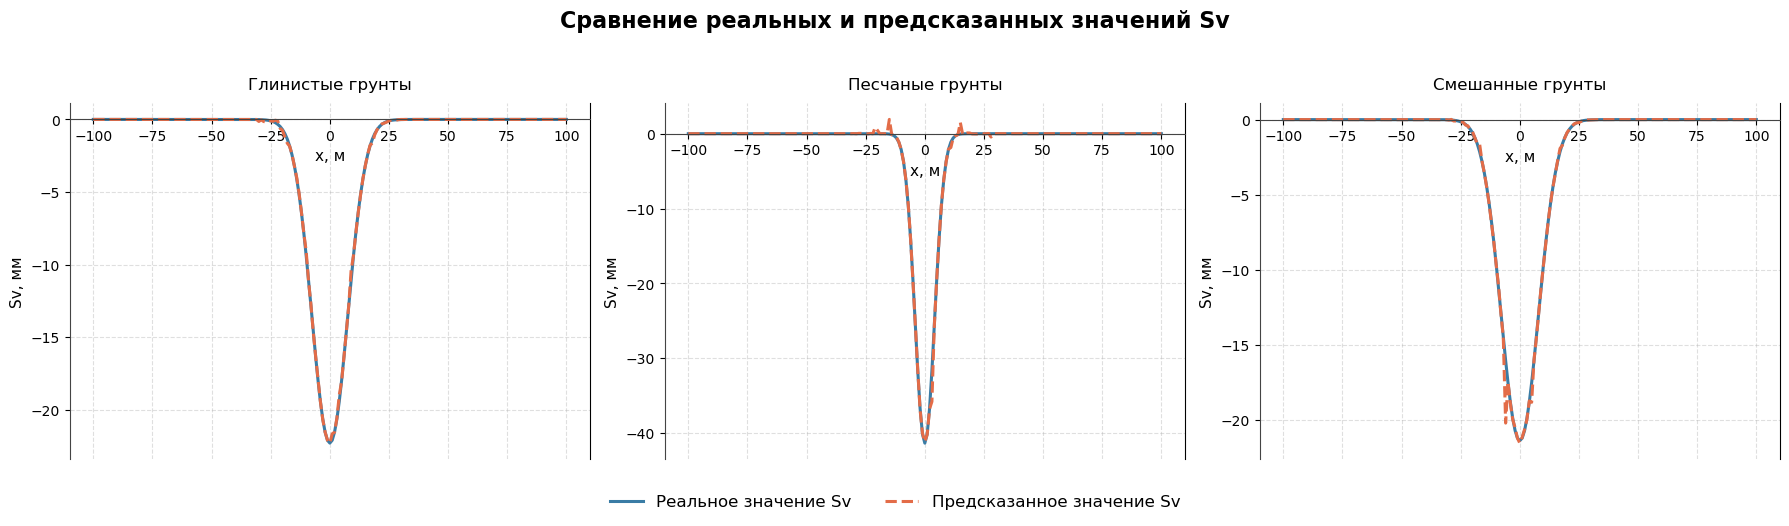

Предсказанные значения: [-1.09056321e-02 -9.78445248e+00 -2.12175188e+00 -7.11465893e-04]
Истинные значения: [-1.34953546e-03 -9.40439551e+00 -2.11095311e+00 -5.19913987e-05]
Ошибка RMSE: 1.90166e-01, ошибка MAE: 1.00268e-01


In [78]:

# Создаем объект класса
model_obj_GB = TunnelSettlementModel(data_600, new_data)

# Обучаем модель
model_obj_GB.train_model()

# Визуализируем результаты на основном датасете
model_obj_GB.vizual_result()

# Предсказания и проверка на новых данных
y_pred = model_obj_GB.check_new_data(new_data, y_true)

### Выводы по работе
Так как наша цель — воспроизвести формулу с помощью модели, то все работает как надо:
1. Нулевая ошибка — нормальный результат, потому что модель полностью «узнала» формулу.

В будущем наща цель — предсказывать реальные измеренные оседания, которые могут отклоняться от формулы, тогда ошибки, близкие к нулю, тут некорректны, так как модель просто запоминает формулу и на новых данных, которые имеют шум вследствии измерения реальных наблюдений, модель будет давать низкую точность
 

### Обучение рекуррентной НС

#### Изменение размера входных признаков

In [214]:
class TunnelSettlementModelRNN:
    def __init__(self, main_data, new_data=None):
        self.main_data_raw = main_data.copy()
        self.new_data_raw = new_data.copy() if new_data is not None else None
        self.data = None
        self.model = None
        self.label_encoders = {}  # для категориальных колонок
        self.prepared_X = None
        self.prepared_Y = None
        self.prepared_new_X = None
        self.prepare_main_data()
        if self.new_data_raw is not None:
            self.prepare_new_data()

    """Функции расчета признаков"""
    @staticmethod
    def calc_ix(row):
        ix = 0
        if row['Тип грунтов'] == 'Глинистые':
            ix = 0.4 * row['Глубина заложения тоннеля, м'] + 1.6
        elif row['Тип грунтов'] == 'Песчаные':
            ix = 0.28 * row['Глубина заложения тоннеля, м'] - 0.1
        elif row['Тип грунтов'] == 'Смешанные':
            ix = 0.4 * row['Глубина заложения тоннеля, м'] + 1.92
        return ix

    @staticmethod
    def calc_feature_Sv_max(row):
        return ((np.pi * (row['Диаметр тоннеля, м'])**2 * (row['GLR %'] / 100)) /
                (4 * row['ix'] * (2 * np.pi)**0.5)) * 1000

    @staticmethod
    def calc_feature_S_v(row):
        return -row['Sv_max'] * np.exp(-(row['x']**2) / (2 * row['ix']**2))


    """Функции для подготовки основного датасета"""
    def prepare_main_data(self):
        data = self.main_data_raw.copy()
        data = data[['x','Тип грунтов','K','Диаметр тоннеля, м',
                     'Тип тоннеля','Технология строительства',
                     'GLR %','Глубина заложения тоннеля, м']]

        # Вычисляем признаки
        data['ix'] = data.apply(self.calc_ix, axis=1)
        data['Sv_max'] = data.apply(self.calc_feature_Sv_max, axis=1)
        data['Sv'] = data.apply(self.calc_feature_S_v, axis=1)

        # Кодируем категориальные переменные 
        for col in ['Технология строительства','Тип грунтов','Тип тоннеля']:
            le = LabelEncoder()
            data[col] = le.fit_transform(data[col])
            self.label_encoders[col] = le

        # Проверка и очистка данных от нулевых значений
        data.replace([np.inf, -np.inf], np.nan, inplace=True)
        data.dropna(inplace=True)

        self.data = data
        self.prepared_X = data[['x','Тип грунтов','ix','K','Диаметр тоннеля, м',
                                'Тип тоннеля','Технология строительства',
                                'GLR %','Глубина заложения тоннеля, м','Sv_max']]
        self.prepared_Y = data['Sv']

    """Подготовка данных для анализа качества работы модели"""
    def prepare_new_data(self):
        if self.new_data_raw is None:
            return None
        data = self.new_data_raw.copy()
        data = data[['x','Тип грунтов','K','Диаметр тоннеля, м',
                     'Тип тоннеля','Технология строительства',
                     'GLR %','Глубина заложения тоннеля, м']]
        data['ix'] = data.apply(self.calc_ix, axis=1)
        data['Sv_max'] = data.apply(self.calc_feature_Sv_max, axis=1)

        # Кодируем категориальные с использованием тех же LabelEncoder, что и на основном датасете
        for col in ['Тип грунтов','Тип тоннеля','Технология строительства']:
            le = self.label_encoders.get(col, LabelEncoder())
            data[col] = le.fit_transform(data[col])
            self.label_encoders[col] = le

        data.replace([np.inf, -np.inf], np.nan, inplace=True)
        data.dropna(inplace=True)

        self.prepared_new_X = data

    """Обучение модели"""
    def train_model(self):
        X_train, X_test, y_train, y_test = train_test_split(
            self.prepared_X, self.prepared_Y, test_size=0.2, random_state=42
        )

        start_time = time.time()
        X_train_reshaped = X_train.values.reshape((X_train.shape[0], X_train.shape[1], 1))
        X_test_reshaped  = X_test.values.reshape((X_test.shape[0], X_test.shape[1], 1))

        self.model = Sequential()
        self.model.add(SimpleRNN(25, input_shape=(X_train_reshaped.shape[1], X_train_reshaped.shape[2]), activation='tanh', return_sequences=True))
        self.model.add(SimpleRNN(50, input_shape=(X_train_reshaped.shape[1], X_train_reshaped.shape[2]), activation='tanh'))
        self.model.add(Dense(1))  # выход один, для регрессии
        self.model.compile(optimizer='adam', loss='mean_squared_error')

        
        self.model.fit(X_train_reshaped, y_train, epochs=100, batch_size=32, verbose=2)

        end_time = time.time()  # <-- сохраняем время окончания
        elapsed_time = end_time - start_time  # время в секундах
        # Проверка точности
        y_train_pred = self.model.predict(X_train_reshaped)
        y_test_pred = self.model.predict(X_test_reshaped)
        train_score = math.sqrt(mean_squared_error(y_train, y_train_pred))
        test_score = math.sqrt(mean_squared_error(y_test, y_test_pred))
        test_mae = mean_absolute_error(y_test, y_test_pred)
        print('Train Score: %.2f RMSE' % train_score)
        print('Test Score: %.2f RMSE' % test_score)

        # Добавляем предсказания в основной датасет
        self.data['Sv_pred_RNN'] = self.model.predict(self.prepared_X.values.reshape((self.prepared_X.shape[0], self.prepared_X.shape[1], 1)))
        return {'test_score':test_mae, 'elapsed_time': elapsed_time}

    """Оценка качества модели на новых данных"""
    def check_new_data(self, new_data, y_true):
        self.new_data_raw = new_data
        self.prepare_new_data()
        X_new = self.prepared_new_X

        y_pred = self.model.predict(X_new.values.reshape((X_new.shape[0], X_new.shape[1], 1)))

        RMSE = mean_squared_error(y_true, y_pred, squared=False)
        MAE = mean_absolute_error(y_true, y_pred)

        print(f"Предсказанные значения: {np.array(y_pred)}")
        print(f"Истинные значения: {np.array(y_true)}")
        print(f"Ошибка RMSE: {RMSE:.5e}, ошибка MAE: {MAE:.5e}")
        return {'y_pred':y_pred,'MAE':MAE}

    """Визуализация результатов работы модели"""
    def plot_result(self, type_soil, column_pred='Sv_pred_RNN', column='Sv', ax=None):
        subset = self.data[(self.data['x'] >= -100) & (self.data['x'] <= 100)]

        # 2. Фильтр по типу грунта
        if type_soil == 'Глинистые грунты':
            subset = subset[subset["Тип грунтов"] == 0]
        elif type_soil == 'Песчаные грунты':
            subset = subset[subset["Тип грунтов"] == 1]
        elif type_soil == 'Смешанные грунты':
            subset = subset[subset["Тип грунтов"] == 2]
        else:
            raise ValueError(f"Неизвестный тип грунта: {type_soil}")

        # 3. (Если нужно) оставить только первые уникальные x
        subset = subset.iloc[:subset['x'].nunique()]

        if ax is None:
            ax = plt.gca()

        real_line = ax.plot(
            subset["x"], subset[column],
            color="#3A7CA5", linewidth=2.2, linestyle='-',
            label="Реальное значение Sv"
        )
        pred_line = ax.plot(
            subset["x"], subset[column_pred],
            color="#E36C48", linewidth=2.2, linestyle='--',
            label="Предсказанное значение Sv"
        )

        ax.set_title(type_soil, fontsize=12, pad=10)
        ax.set_xlabel("x, м", fontsize=11)
        ax.set_ylabel("Sv, мм", fontsize=11)
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.spines['bottom'].set_position('zero')
        ax.spines['top'].set_visible(False)
        ax.spines['left'].set_color('#444')
        ax.spines['bottom'].set_color('#444')
        ax.tick_params(axis='both', which='major', labelsize=10)

        return real_line[0], pred_line[0]

    def vizual_result(self):
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        line1_real, line1_pred = self.plot_result('Глинистые грунты', ax=axes[0])
        line2_real, line2_pred = self.plot_result('Песчаные грунты', ax=axes[1])
        line3_real, line3_pred = self.plot_result('Смешанные грунты', ax=axes[2])

        fig.suptitle(
            "Сравнение реальных и предсказанных значений Sv",
            fontsize=16, fontweight='bold'
        )
        fig.legend(
            handles=[line1_real, line1_pred],
            labels=["Реальное значение Sv", "Предсказанное значение Sv"],
            loc='lower center',
            ncol=2,
            frameon=False,
            fontsize=12,
            bbox_to_anchor=(0.5, -0.05)
        )
        plt.tight_layout(rect=[0, 0.05, 1, 0.95])
        plt.show()

Epoch 1/100
16/16 - 1s - 54ms/step - loss: 41.9436
Epoch 2/100
16/16 - 0s - 3ms/step - loss: 38.6224
Epoch 3/100
16/16 - 0s - 3ms/step - loss: 38.7486
Epoch 4/100
16/16 - 0s - 3ms/step - loss: 38.1177
Epoch 5/100
16/16 - 0s - 3ms/step - loss: 36.8977
Epoch 6/100
16/16 - 0s - 3ms/step - loss: 33.4851
Epoch 7/100
16/16 - 0s - 3ms/step - loss: 27.4287
Epoch 8/100
16/16 - 0s - 3ms/step - loss: 21.2608
Epoch 9/100
16/16 - 0s - 3ms/step - loss: 17.6639
Epoch 10/100
16/16 - 0s - 3ms/step - loss: 15.3252
Epoch 11/100
16/16 - 0s - 3ms/step - loss: 13.4352
Epoch 12/100
16/16 - 0s - 3ms/step - loss: 11.9857
Epoch 13/100
16/16 - 0s - 3ms/step - loss: 10.8827
Epoch 14/100
16/16 - 0s - 3ms/step - loss: 10.2514
Epoch 15/100
16/16 - 0s - 3ms/step - loss: 9.1361
Epoch 16/100
16/16 - 0s - 3ms/step - loss: 8.6090
Epoch 17/100
16/16 - 0s - 3ms/step - loss: 8.3290
Epoch 18/100
16/16 - 0s - 3ms/step - loss: 7.5744
Epoch 19/100
16/16 - 0s - 3ms/step - loss: 7.2920
Epoch 20/100
16/16 - 0s - 3ms/step - loss: 6

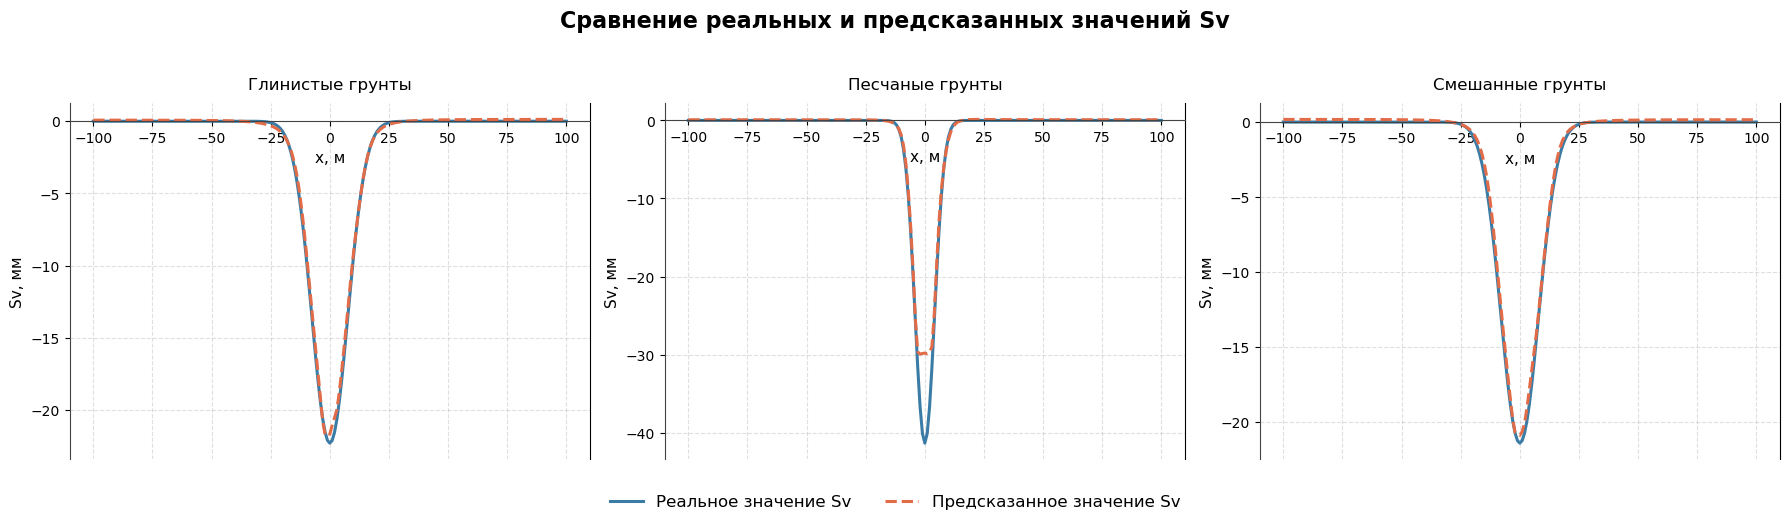

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Предсказанные значения: [[-7.87512  ]
 [ 1.6047151]
 [-2.8043058]
 [ 1.2090514]]
Истинные значения: [-1.34953546e-03 -9.40439551e+00 -2.11095311e+00 -5.19913987e-05]
Ошибка RMSE: 6.80330e+00, ошибка MAE: 5.19633e+00


In [36]:


# Создаем объект класса
model_obj_RNN = TunnelSettlementModelRNN(data_600, new_data)

# # Обучаем модель
model_obj_RNN.train_model()

# # Визуализируем результаты на основном датасете
model_obj_RNN.vizual_result()


y_pred = model_obj_RNN.check_new_data(new_data, y_true)

### Обучение полносвязной НС

#### Масштабирование признаков, так как Dense-сети чувствительны к разному машстабу признаков

In [228]:
class TunnelSettlementModelDense:
    def __init__(self, main_data, new_data=None):
        self.main_data_raw = main_data.copy()
        self.new_data_raw = new_data.copy() if new_data is not None else None
        self.data = None
        self.model_Dense = None
        self.label_encoders = {}  # для категориальных колонок
        self.prepared_X = None
        self.prepared_Y = None
        self.prepared_new_X = None
        self.prepare_main_data()
        self.scaler = StandardScaler()
        if self.new_data_raw is not None:
            self.prepare_new_data()

    """Функции расчета признаков"""
    @staticmethod
    def calc_ix(row):
        ix = 0
        if row['Тип грунтов'] == 'Глинистые':
            ix = 0.4 * row['Глубина заложения тоннеля, м'] + 1.6
        elif row['Тип грунтов'] == 'Песчаные':
            ix = 0.28 * row['Глубина заложения тоннеля, м'] - 0.1
        elif row['Тип грунтов'] == 'Смешанные':
            ix = 0.4 * row['Глубина заложения тоннеля, м'] + 1.92
        return ix

    @staticmethod
    def calc_feature_Sv_max(row):
        return ((np.pi * (row['Диаметр тоннеля, м'])**2 * (row['GLR %'] / 100)) /
                (4 * row['ix'] * (2 * np.pi)**0.5)) * 1000

    @staticmethod
    def calc_feature_S_v(row):
        return -row['Sv_max'] * np.exp(-(row['x']**2) / (2 * row['ix']**2))


    """Функции для подготовки основного датасета"""
    def prepare_main_data(self):
        data = self.main_data_raw.copy()
        data = data[['x','Тип грунтов','K','Диаметр тоннеля, м',
                     'Тип тоннеля','Технология строительства',
                     'GLR %','Глубина заложения тоннеля, м']]

        # Вычисляем признаки
        data['ix'] = data.apply(self.calc_ix, axis=1)
        data['Sv_max'] = data.apply(self.calc_feature_Sv_max, axis=1)
        data['Sv'] = data.apply(self.calc_feature_S_v, axis=1)

        # Кодируем категориальные переменные 
        for col in ['Технология строительства','Тип грунтов','Тип тоннеля']:
            le = LabelEncoder()
            data[col] = le.fit_transform(data[col])
            self.label_encoders[col] = le

        # Проверка и очистка данных от нулевых значений
        data.replace([np.inf, -np.inf], np.nan, inplace=True)
        data.dropna(inplace=True)

        self.data = data
        self.prepared_X = data[['x','Тип грунтов','ix','K','Диаметр тоннеля, м',
                                'Тип тоннеля','Технология строительства',
                                'GLR %','Глубина заложения тоннеля, м','Sv_max']]
        self.prepared_Y = data['Sv']

    """Подготовка данных для анализа качества работы модели"""
    def prepare_new_data(self):
        if self.new_data_raw is None:
            return None
        data = self.new_data_raw.copy()
        data = data[['x','Тип грунтов','K','Диаметр тоннеля, м',
                     'Тип тоннеля','Технология строительства',
                     'GLR %','Глубина заложения тоннеля, м']]
        data['ix'] = data.apply(self.calc_ix, axis=1)
        data['Sv_max'] = data.apply(self.calc_feature_Sv_max, axis=1)

        # Кодируем категориальные с использованием тех же LabelEncoder, что и на основном датасете
        for col in ['Тип грунтов','Тип тоннеля','Технология строительства']:
            le = self.label_encoders.get(col, LabelEncoder())
            data[col] = le.fit_transform(data[col])
            self.label_encoders[col] = le

        data.replace([np.inf, -np.inf], np.nan, inplace=True)
        data.dropna(inplace=True)

        self.prepared_new_X = data

    """Обучение модели"""
    def train_model(self):
        X_train, X_test, y_train, y_test = train_test_split(
            self.prepared_X, self.prepared_Y, test_size=0.2, random_state=42
        )
        start_time = time.time()
        X_train_scaled = self.scaler.fit_transform(X_train)
        X_test_scaled  = self.scaler.transform(X_test)

        self.model_Dense = Sequential()
        self.model_Dense.add(Dense(256, activation='relu', input_shape=(X_train_scaled.shape[1],)))
        self.model_Dense.add(Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)))

        self.model_Dense.add(Dense(64, activation='relu',))

        self.model_Dense.add(Dense(32, activation='relu'))

        self.model_Dense.add(Dense(16, activation='relu'))
        self.model_Dense.add(Dense(1))  # один выход для регрессии

        self.model_Dense.compile(optimizer=Adam(learning_rate=1e-4),loss='mse')

        early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

        self.model_Dense.fit(X_train_scaled, y_train, 
                        epochs=300, batch_size=32, 
                        verbose=2, validation_split=0.2,
                        callbacks=[early_stop])
        
        end_time = time.time()  # <-- сохраняем время окончания
        elapsed_time = end_time - start_time  # время в секундах

        # Проверка точности
        y_train_pred = self.model_Dense.predict(X_train_scaled)
        y_test_pred = self.model_Dense.predict(X_test_scaled)
        train_score = math.sqrt(mean_squared_error(y_train, y_train_pred))
        test_score = math.sqrt(mean_squared_error(y_test, y_test_pred))
        test_mae = mean_absolute_error(y_test, y_test_pred)
        print('Train Score: %.2f RMSE' % train_score)
        print('Test Score: %.2f RMSE' % test_score)

        # Добавляем предсказания в основной датасет
        self.data['Sv_pred_Dense'] = self.model_Dense.predict(self.scaler.transform(self.prepared_X))
        return {'test_score':test_mae, 'elapsed_time': elapsed_time}


    """Оценка качества модели на новых данных"""
    def check_new_data(self, new_data, y_true):
        self.new_data_raw = new_data
        self.prepare_new_data()
        X_new = self.prepared_new_X

        y_pred = self.model_Dense.predict(self.scaler.fit_transform(X_new))

        RMSE = mean_squared_error(y_true, y_pred, squared=False)
        MAE = mean_absolute_error(y_true, y_pred)

        print(f"Предсказанные значения: {np.array(y_pred)}")
        print(f"Истинные значения: {np.array(y_true)}")
        print(f"Ошибка RMSE: {RMSE:.5e}, ошибка MAE: {MAE:.5e}")
        return {'y_pred':y_pred,'MAE':MAE}

    """Визуализация результатов работы модели"""
    def plot_result(self, type_soil, column_pred='Sv_pred_Dense', column='Sv', ax=None):

        # 1. Фильтр по диапазону x
        subset = self.data[(self.data['x'] >= -100) & (self.data['x'] <= 100)]

        # 2. Фильтр по типу грунта
        if type_soil == 'Глинистые грунты':
            subset = subset[subset["Тип грунтов"] == 0]
        elif type_soil == 'Песчаные грунты':
            subset = subset[subset["Тип грунтов"] == 1]
        elif type_soil == 'Смешанные грунты':
            subset = subset[subset["Тип грунтов"] == 2]
        else:
            raise ValueError(f"Неизвестный тип грунта: {type_soil}")

        # 3. (Если нужно) оставить только первые уникальные x
        subset = subset.iloc[:subset['x'].nunique()]

        if ax is None:
            ax = plt.gca()

        real_line = ax.plot(
            subset["x"], subset[column],
            color="#3A7CA5", linewidth=2.2, linestyle='-',
            label="Реальное значение Sv"
        )
        pred_line = ax.plot(
            subset["x"], subset[column_pred],
            color="#E36C48", linewidth=2.2, linestyle='--',
            label="Предсказанное значение Sv"
        )

        ax.set_title(type_soil, fontsize=12, pad=10)
        ax.set_xlabel("x, м", fontsize=11)
        ax.set_ylabel("Sv, мм", fontsize=11)
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.spines['bottom'].set_position('zero')
        ax.spines['top'].set_visible(False)
        ax.spines['left'].set_color('#444')
        ax.spines['bottom'].set_color('#444')
        ax.tick_params(axis='both', which='major', labelsize=10)

        return real_line[0], pred_line[0]

    def vizual_result(self):
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        line1_real, line1_pred = self.plot_result('Глинистые грунты', ax=axes[0])
        line2_real, line2_pred = self.plot_result('Песчаные грунты', ax=axes[1])
        line3_real, line3_pred = self.plot_result('Смешанные грунты', ax=axes[2])

        fig.suptitle(
            "Сравнение реальных и предсказанных значений Sv",
            fontsize=16, fontweight='bold'
        )
        fig.legend(
            handles=[line1_real, line1_pred],
            labels=["Реальное значение Sv", "Предсказанное значение Sv"],
            loc='lower center',
            ncol=2,
            frameon=False,
            fontsize=12,
            bbox_to_anchor=(0.5, -0.05)
        )
        plt.tight_layout(rect=[0, 0.05, 1, 0.95])
        plt.show()

Epoch 1/300
13/13 - 1s - 49ms/step - loss: 45.4412 - val_loss: 39.0044
Epoch 2/300
13/13 - 0s - 4ms/step - loss: 45.0153 - val_loss: 38.6924
Epoch 3/300
13/13 - 0s - 4ms/step - loss: 44.7022 - val_loss: 38.4056
Epoch 4/300
13/13 - 0s - 4ms/step - loss: 44.4138 - val_loss: 38.1173
Epoch 5/300
13/13 - 0s - 4ms/step - loss: 44.1604 - val_loss: 37.8178
Epoch 6/300
13/13 - 0s - 4ms/step - loss: 43.8725 - val_loss: 37.5100
Epoch 7/300
13/13 - 0s - 4ms/step - loss: 43.5750 - val_loss: 37.1619
Epoch 8/300
13/13 - 0s - 4ms/step - loss: 43.2566 - val_loss: 36.7617
Epoch 9/300
13/13 - 0s - 4ms/step - loss: 42.8736 - val_loss: 36.3320
Epoch 10/300
13/13 - 0s - 4ms/step - loss: 42.5105 - val_loss: 35.9998
Epoch 11/300
13/13 - 0s - 5ms/step - loss: 42.1536 - val_loss: 35.6914
Epoch 12/300
13/13 - 0s - 4ms/step - loss: 41.8304 - val_loss: 35.3538
Epoch 13/300
13/13 - 0s - 4ms/step - loss: 41.4669 - val_loss: 35.0271
Epoch 14/300
13/13 - 0s - 4ms/step - loss: 41.0805 - val_loss: 34.7193
Epoch 15/300
1

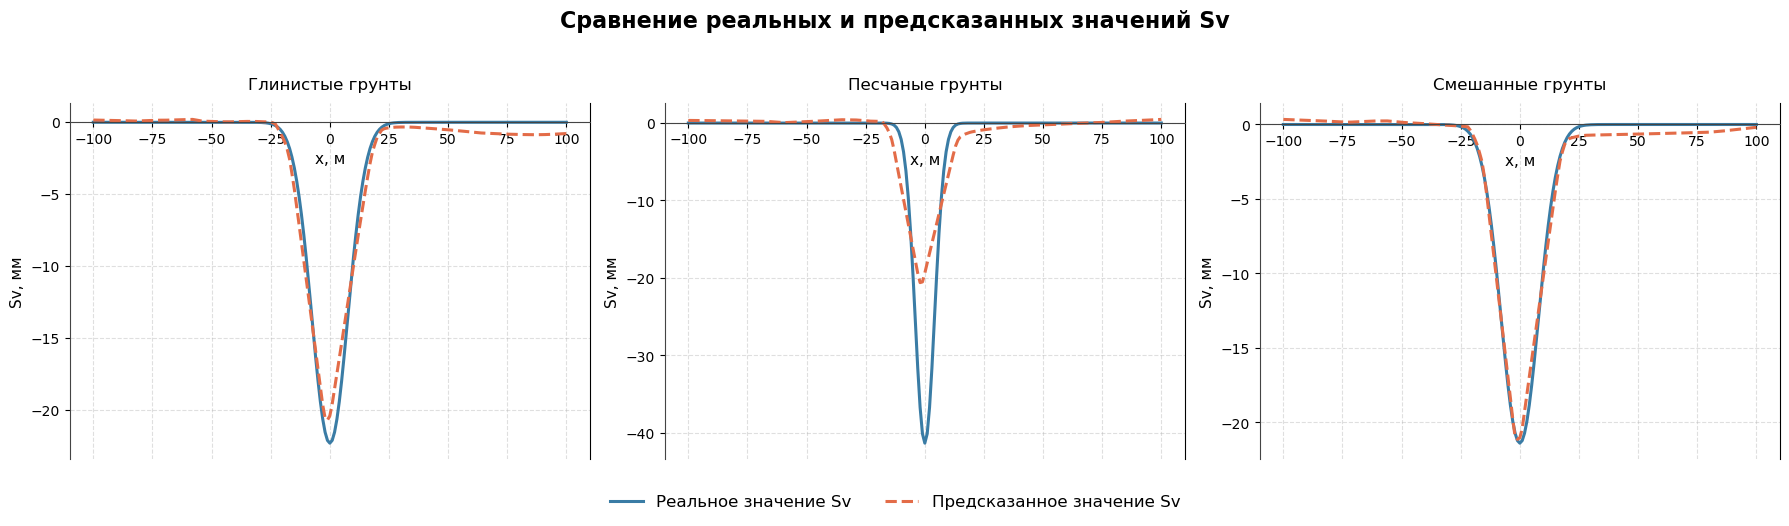

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Предсказанные значения: [[ 0.21816678]
 [-6.537916  ]
 [-0.79981095]
 [-0.1432815 ]]
Истинные значения: [-1.34953546e-03 -9.40439551e+00 -2.11095311e+00 -5.19913987e-05]
Ошибка RMSE: 1.58149e+00, ошибка MAE: 1.13509e+00


In [34]:


# # Создаем объект класса
model_obj_Dense = TunnelSettlementModelDense(data_600, new_data)

# # # Обучаем модель
model_obj_Dense.train_model()



# # Визуализируем результаты на основном датасете
model_obj_Dense.vizual_result()
y_pred = model_obj_Dense.check_new_data(new_data, y_true)

### Случайный лес

#### Поиск параметров

In [245]:
class TunnelSettlementModelRandomForest:
    def __init__(self, main_data, new_data=None):
        self.main_data_raw = main_data.copy()
        self.new_data_raw = new_data.copy() if new_data is not None else None
        self.data = None
        self.model = None
        self.label_encoders = {}  # для категориальных колонок
        self.prepared_X = None
        self.prepared_Y = None
        self.prepared_new_X = None
        self.prepare_main_data()
        if self.new_data_raw is not None:
            self.prepare_new_data()

    """Функции расчета признаков"""
    @staticmethod
    def calc_ix(row):
        ix = 0
        if row['Тип грунтов'] == 'Глинистые':
            ix = 0.4 * row['Глубина заложения тоннеля, м'] + 1.6
        elif row['Тип грунтов'] == 'Песчаные':
            ix = 0.28 * row['Глубина заложения тоннеля, м'] - 0.1
        elif row['Тип грунтов'] == 'Смешанные':
            ix = 0.4 * row['Глубина заложения тоннеля, м'] + 1.92
        return ix

    @staticmethod
    def calc_feature_Sv_max(row):
        return ((np.pi * (row['Диаметр тоннеля, м'])**2 * (row['GLR %'] / 100)) /
                (4 * row['ix'] * (2 * np.pi)**0.5)) * 1000

    @staticmethod
    def calc_feature_S_v(row):
        return -row['Sv_max'] * np.exp(-(row['x']**2) / (2 * row['ix']**2))


    """Функции для подготовки основного датасета"""
    def prepare_main_data(self):
        data = self.main_data_raw.copy()
        data = data[['x','Тип грунтов','K','Диаметр тоннеля, м',
                     'Тип тоннеля','Технология строительства',
                     'GLR %','Глубина заложения тоннеля, м']]

        # Вычисляем признаки
        data['ix'] = data.apply(self.calc_ix, axis=1)
        data['Sv_max'] = data.apply(self.calc_feature_Sv_max, axis=1)
        data['Sv'] = data.apply(self.calc_feature_S_v, axis=1)

        # Кодируем категориальные переменные 
        for col in ['Технология строительства','Тип грунтов','Тип тоннеля']:
            le = LabelEncoder()
            data[col] = le.fit_transform(data[col])
            self.label_encoders[col] = le

        # Проверка и очистка данных от нулевых значений
        data.replace([np.inf, -np.inf], np.nan, inplace=True)
        data.dropna(inplace=True)

        self.data = data
        self.prepared_X = data[['x','Тип грунтов','ix','K','Диаметр тоннеля, м',
                                'Тип тоннеля','Технология строительства',
                                'GLR %','Глубина заложения тоннеля, м','Sv_max']]
        self.prepared_Y = data['Sv']

    """Подготовка данных для анализа качества работы модели"""
    def prepare_new_data(self):
        if self.new_data_raw is None:
            return None
        data = self.new_data_raw.copy()
        data = data[['x','Тип грунтов','K','Диаметр тоннеля, м',
                     'Тип тоннеля','Технология строительства',
                     'GLR %','Глубина заложения тоннеля, м']]
        data['ix'] = data.apply(self.calc_ix, axis=1)
        data['Sv_max'] = data.apply(self.calc_feature_Sv_max, axis=1)

        # Кодируем категориальные с использованием тех же LabelEncoder, что и на основном датасете
        for col in ['Тип грунтов','Тип тоннеля','Технология строительства']:
            le = self.label_encoders.get(col, LabelEncoder())
            data[col] = le.fit_transform(data[col])
            self.label_encoders[col] = le

        data.replace([np.inf, -np.inf], np.nan, inplace=True)
        data.dropna(inplace=True)

        self.prepared_new_X = data

    """Обучение модели"""
    def train_model(self):
        X_train, X_test, y_train, y_test = train_test_split(
            self.prepared_X, self.prepared_Y, test_size=0.2, random_state=42
        )

        # Подбор параметров для градиентного бустинга
        param_grid = {
            'n_estimators': [5, 10, 25, 50, 100,200,500],
            'max_depth': [1, 5, 10, 20,50,100,200],
            'max_features': ['auto', 'sqrt', 'log2'],
            'min_samples_split':[1,5,10,15,20],}
        
        start_time = time.time()
        grid = GridSearchCV(RandomForestRegressor(random_state=10),
                            param_grid, cv=min(5, len(X_train)))
        grid.fit(X_train, y_train)
        print(f"Лучшие параметры: {grid.best_params_}")

        # Обучаем модель с лучшими параметрами
        self.model = RandomForestRegressor(
            n_estimators=grid.best_params_['n_estimators'],
            max_depth=grid.best_params_['max_depth'],
            max_features=grid.best_params_['max_features'],
            min_samples_split=grid.best_params_['min_samples_split'],
            random_state=10
        )
        self.model.fit(X_train, y_train)

        end_time = time.time()  # <-- сохраняем время окончания
        elapsed_time = end_time - start_time  # время в секундах

        # Проверка точности
        y_train_pred = self.model.predict(X_train)
        y_test_pred = self.model.predict(X_test)
        train_rmse = mean_squared_error(y_train, y_train_pred, squared=False)
        test_rmse = mean_squared_error(y_test, y_test_pred, squared=False)
        test_mae = mean_absolute_error(y_test, y_test_pred)
        print(f"Train Score: {train_rmse:.2e} RMSE")
        print(f"Test Score: {test_rmse:.2e} RMSE")

        # Добавляем предсказания в основной датасет
        self.data['Sv_pred_RF'] = self.model.predict(self.prepared_X)
        return {'test_score':test_mae, 'elapsed_time': elapsed_time}

    """Оценка качества модели на новых данных"""
    def check_new_data(self, new_data, y_true):
        self.new_data_raw = new_data
        self.prepare_new_data()
        X_new = self.prepared_new_X[self.model.feature_names_in_]

        y_pred = self.model.predict(X_new)

        RMSE = mean_squared_error(y_true, y_pred, squared=False)
        MAE = mean_absolute_error(y_true, y_pred)

        print(f"Предсказанные значения: {np.array(y_pred)}")
        print(f"Истинные значения: {np.array(y_true)}")
        print(f"Ошибка RMSE: {RMSE:.5e}, ошибка MAE: {MAE:.5e}")
        return {'y_pred':y_pred,'MAE':MAE}

    """Визуализация результатов работы модели"""
    def plot_result(self, type_soil, column_pred='Sv_pred_RF', column='Sv', ax=None):

        # 1. Фильтр по диапазону x
        subset = self.data[(self.data['x'] >= -100) & (self.data['x'] <= 100)]

        # 2. Фильтр по типу грунта
        if type_soil == 'Глинистые грунты':
            subset = subset[subset["Тип грунтов"] == 0]
        elif type_soil == 'Песчаные грунты':
            subset = subset[subset["Тип грунтов"] == 1]
        elif type_soil == 'Смешанные грунты':
            subset = subset[subset["Тип грунтов"] == 2]
        else:
            raise ValueError(f"Неизвестный тип грунта: {type_soil}")

        # 3. (Если нужно) оставить только первые уникальные x
        subset = subset.iloc[:subset['x'].nunique()]

        if ax is None:
            ax = plt.gca()

        real_line = ax.plot(
            subset["x"], subset[column],
            color="#3A7CA5", linewidth=2.2, linestyle='-',
            label="Реальное значение Sv"
        )
        pred_line = ax.plot(
            subset["x"], subset[column_pred],
            color="#E36C48", linewidth=2.2, linestyle='--',
            label="Предсказанное значение Sv"
        )

        ax.set_title(type_soil, fontsize=12, pad=10)
        ax.set_xlabel("x, м", fontsize=11)
        ax.set_ylabel("Sv, мм", fontsize=11)
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.spines['bottom'].set_position('zero')
        ax.spines['top'].set_visible(False)
        ax.spines['left'].set_color('#444')
        ax.spines['bottom'].set_color('#444')
        ax.tick_params(axis='both', which='major', labelsize=10)

        return real_line[0], pred_line[0]

    def vizual_result(self):

        
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        line1_real, line1_pred = self.plot_result('Глинистые грунты', ax=axes[0])
        line2_real, line2_pred = self.plot_result('Песчаные грунты', ax=axes[1])
        line3_real, line3_pred = self.plot_result('Смешанные грунты', ax=axes[2])

        fig.suptitle(
            "Сравнение реальных и предсказанных значений Sv",
            fontsize=16, fontweight='bold'
        )
        fig.legend(
            handles=[line1_real, line1_pred],
            labels=["Реальное значение Sv", "Предсказанное значение Sv"],
            loc='lower center',
            ncol=2,
            frameon=False,
            fontsize=12,
            bbox_to_anchor=(0.5, -0.05)
        )
        plt.tight_layout(rect=[0, 0.05, 1, 0.95])
        plt.show()

Лучшие параметры: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 100}
Train Score: 5.38e-01 RMSE
Test Score: 6.22e-01 RMSE


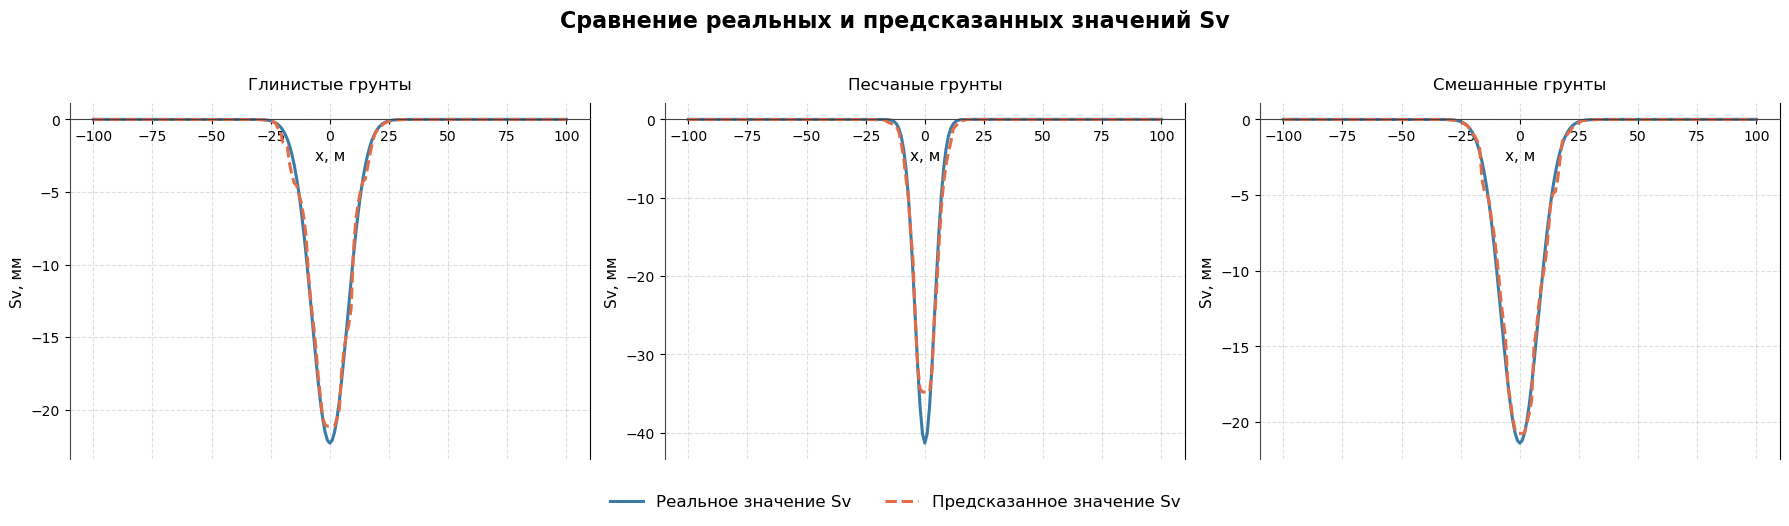

Предсказанные значения: [-1.76580905e-08 -1.00794968e+01 -3.03784527e+00 -5.59048471e-08]
Истинные значения: [-1.34953546e-03 -9.40439551e+00 -2.11095311e+00 -5.19913987e-05]
Ошибка RMSE: 5.73344e-01, ошибка MAE: 4.00849e-01


In [30]:


# # Создаем объект класса
model_obj_RF = TunnelSettlementModelRandomForest(data_600, new_data)

# # # Обучаем модель
model_obj_RF.train_model()



# # Визуализируем результаты на основном датасете
model_obj_RF.vizual_result()

y_pred = model_obj_RF.check_new_data(new_data, y_true)

## Анализ работы моделей на оценке других показателй:
1. Горизонтальные смещения земной поверхности в поперечном направлении
2. Горизонтальные относительные деформации земной поверхности в поперечном направлении

### Горизонтальные смещения земной поверхности в поперечном направлении

In [27]:
class TunnelPredictor_Sh:
    def __init__(self, main_data, model_gb=None, model_rf=None, model_rnn=None, model_dense=None, new_data=None):
        self.main_data_raw = main_data.copy()
        self.new_data_raw = new_data.copy() if new_data is not None else None

        self.model_gb = model_gb
        self.model_rf = model_rf
        self.model_rnn = model_rnn
        self.model_dense = model_dense

        self.label_encoders = {}
        self.data = None
        self.prepared_X = None
        self.prepared_Y = None
        self.scaler = StandardScaler()

        # подготовка основного датасета
        self.prepare_main_data()

        # предсказания моделей
        self.add_predictions()

        # вычисление s/h
        self.add_s_h_columns()

    @staticmethod
    def calc_ix(row):
        if row['Тип грунтов'] == 'Глинистые':
            return 0.4 * row['Глубина заложения тоннеля, м'] + 1.6
        elif row['Тип грунтов'] == 'Песчаные':
            return 0.28 * row['Глубина заложения тоннеля, м'] - 0.1
        elif row['Тип грунтов'] == 'Смешанные':
            return 0.4 * row['Глубина заложения тоннеля, м'] + 1.92
        return 0

    @staticmethod
    def calc_feature_Sv_max(row):
        return ((np.pi * (row['Диаметр тоннеля, м'])**2 * (row['GLR %'] / 100)) /
                (4 * row['ix'] * (2 * np.pi)**0.5)) * 1000

    @staticmethod
    def calc_feature_S_v(row):
        return -row['Sv_max'] * np.exp(-(row['x']**2) / (2 * row['ix']**2))

    @staticmethod
    def calc_s_h(row, pred_col):
        return (row['x'] * row[pred_col]) / row['Глубина заложения тоннеля, м']

    def prepare_main_data(self):
        data = self.main_data_raw.copy()
        data = data[['x','Тип грунтов','K','Диаметр тоннеля, м',
                     'Тип тоннеля','Технология строительства',
                     'GLR %','Глубина заложения тоннеля, м']]
        data['ix'] = data.apply(self.calc_ix, axis=1)
        data['Sv_max'] = data.apply(self.calc_feature_Sv_max, axis=1)
        data['Sv'] = data.apply(self.calc_feature_S_v, axis=1)

        # кодирование категориальных
        for col in ['Технология строительства','Тип грунтов','Тип тоннеля']:
            le = LabelEncoder()
            data[col] = le.fit_transform(data[col])
            self.label_encoders[col] = le

        data.replace([np.inf, -np.inf], np.nan, inplace=True)
        data.dropna(inplace=True)

        self.data = data
        self.prepared_X = data[['x','Тип грунтов','ix','K','Диаметр тоннеля, м',
                                'Тип тоннеля','Технология строительства',
                                'GLR %','Глубина заложения тоннеля, м','Sv_max']]
        self.prepared_Y = data['Sv']

    def add_predictions(self):
        X = self.prepared_X
        if self.model_gb:
            self.data["Sv_pred"] = self.model_gb.predict(X)
        if self.model_rf:
            self.data["Sv_pred_RF"] = self.model_rf.predict(X)
        if self.model_rnn:
            X_rnn = X.values.reshape((X.shape[0], X.shape[1], 1))
            self.data["Sv_pred_RNN"] = self.model_rnn.predict(X_rnn)
        if self.model_dense:
            self.data["Sv_pred_Dense"] = self.model_dense.predict(self.scaler.fit_transform(X))

    def add_s_h_columns(self):
        for col in ['Sv_pred','Sv_pred_RF','Sv_pred_RNN','Sv_pred_Dense']:
            if col in self.data:
                self.data[f's_h_{col.split("_")[-1]}'] = self.data.apply(lambda row: self.calc_s_h(row, col), axis=1)
        # Истинное s/h
        self.data['s_h_true'] = self.data.apply(lambda row: row['x'] * row['Sv'] / row['Глубина заложения тоннеля, м'], axis=1)

    def visualize_all(self):
        fig, axes = plt.subplots(1, 3, figsize=(20,6))
        soil_types = {'Глинистые грунты': 0, 'Песчаные грунты': 1, 'Смешанные грунты': 2}

        colors = {
            's_h_true': '#3A7CA5',
            's_h_pred': '#E36C48',
            's_h_RF': '#6C3483',
            's_h_RNN': '#28B463',
            's_h_Dense': '#F31128' #f31228
        }

        labels_map = {
            's_h_true': 'Истинное s/h',
            's_h_pred': 'GB',
            's_h_RF': 'RF',
            's_h_RNN': 'RNN',
            's_h_Dense': 'Dense'
        }

        for ax, (soil_name, soil_code) in zip(axes, soil_types.items()):
            subset_all = self.data[(self.data['x'] >= -100) & (self.data['x'] <= 100) & (self.data['Тип грунтов'] == soil_code)]
            subset = subset_all.iloc[:len(subset_all['x'].unique())]
            lines = []
            labels = []

            for col in ['s_h_true','s_h_pred','s_h_RF','s_h_RNN','s_h_Dense']:
                if col not in subset:
                    subset[col] = np.nan
                line, = ax.plot(
                    subset['x'], subset[col],
                    label=labels_map[col],
                    color=colors[col],
                    linestyle='-' if col=='s_h_true' else '--',
                    linewidth=2
                )
                lines.append(line)
                labels.append(labels_map[col])

            ax.set_title(soil_name, fontsize=12)
            ax.set_xlabel('x, м')
            ax.set_ylabel('s/h')
            ax.grid(True, linestyle='--', alpha=0.4)
            ax.legend(lines, labels, fontsize=12)

        plt.suptitle("Сравнение истинного и предсказанных s_h по типам грунтов", fontsize=16)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()





19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 726us/step


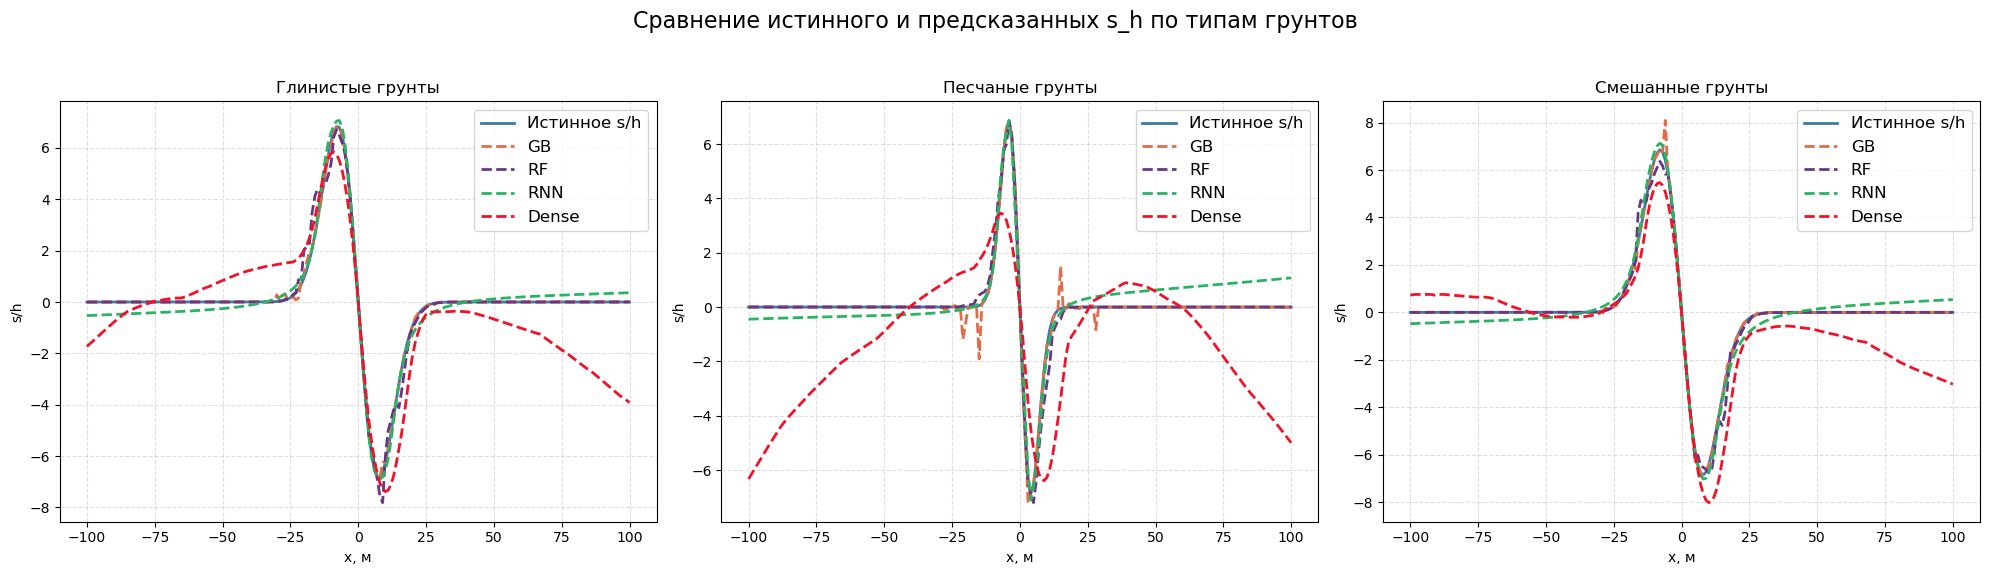

In [28]:
predictor = TunnelPredictor_Sh(
    main_data=data_600,
    model_gb=model_obj_GB.model,
    model_rf=model_obj_RF.model,
    model_rnn=model_obj_RNN.model,
    model_dense=model_obj_Dense.model_Dense
)

predictor.visualize_all()

### Горизонтальные относительные деформации земной поверхности в поперечном направлении

In [21]:
class TunnelPredictor_eh:
    def __init__(self, main_data, model_gb=None, model_rf=None, model_rnn=None, model_dense=None, new_data=None):
        self.main_data_raw = main_data.copy()
        self.new_data_raw = new_data.copy() if new_data is not None else None

        self.model_gb = model_gb
        self.model_rf = model_rf
        self.model_rnn = model_rnn
        self.model_dense = model_dense

        self.label_encoders = {}
        self.data = None
        self.prepared_X = None
        self.prepared_Y = None
        self.scaler = StandardScaler()

        # подготовка основного датасета
        self.prepare_main_data()

        # предсказания моделей
        self.add_predictions()

        # вычисление s/h
        self.add_s_h_columns()

    @staticmethod
    def calc_ix(row):
        if row['Тип грунтов'] == 'Глинистые':
            return 0.4 * row['Глубина заложения тоннеля, м'] + 1.6
        elif row['Тип грунтов'] == 'Песчаные':
            return 0.28 * row['Глубина заложения тоннеля, м'] - 0.1
        elif row['Тип грунтов'] == 'Смешанные':
            return 0.4 * row['Глубина заложения тоннеля, м'] + 1.92
        return 0

    @staticmethod
    def calc_feature_Sv_max(row):
        return ((np.pi * (row['Диаметр тоннеля, м'])**2 * (row['GLR %'] / 100)) /
                (4 * row['ix'] * (2 * np.pi)**0.5)) * 1000

    @staticmethod
    def calc_feature_S_v(row):
        return -row['Sv_max'] * np.exp(-(row['x']**2) / (2 * row['ix']**2))

    @staticmethod
    def calc_e_h(row, pred_col):
        return (row[pred_col]*(1-((row['x']**2/(row['ix']**2)))))/(row['Глубина заложения тоннеля, м']*1000)

    def prepare_main_data(self):
        data = self.main_data_raw.copy()
        data = data[['x','Тип грунтов','K','Диаметр тоннеля, м',
                     'Тип тоннеля','Технология строительства',
                     'GLR %','Глубина заложения тоннеля, м']]
        data['ix'] = data.apply(self.calc_ix, axis=1)
        data['Sv_max'] = data.apply(self.calc_feature_Sv_max, axis=1)
        data['Sv'] = data.apply(self.calc_feature_S_v, axis=1)

        # кодирование категориальных
        for col in ['Технология строительства','Тип грунтов','Тип тоннеля']:
            le = LabelEncoder()
            data[col] = le.fit_transform(data[col])
            self.label_encoders[col] = le

        data.replace([np.inf, -np.inf], np.nan, inplace=True)
        data.dropna(inplace=True)

        self.data = data
        self.prepared_X = data[['x','Тип грунтов','ix','K','Диаметр тоннеля, м',
                                'Тип тоннеля','Технология строительства',
                                'GLR %','Глубина заложения тоннеля, м','Sv_max']]
        self.prepared_Y = data['Sv']

    def add_predictions(self):
        X = self.prepared_X
        if self.model_gb:
            self.data["Sv_pred"] = self.model_gb.predict(X)
        if self.model_rf:
            self.data["Sv_pred_RF"] = self.model_rf.predict(X)
        if self.model_rnn:
            X_rnn = X.values.reshape((X.shape[0], X.shape[1], 1))
            self.data["Sv_pred_RNN"] = self.model_rnn.predict(X_rnn)
        if self.model_dense:
            self.data["Sv_pred_Dense"] = self.model_dense.predict(self.scaler.fit_transform(X))

    def add_s_h_columns(self):
        for col in ['Sv_pred','Sv_pred_RF','Sv_pred_RNN','Sv_pred_Dense']:
            if col in self.data:
                self.data[f'e_h_{col.split("_")[-1]}'] = self.data.apply(lambda row: self.calc_e_h(row, col), axis=1)
        # Истинное s/h
        self.data['e_h_true'] = self.data.apply(lambda row: (row['Sv']*(1-((row['x']**2/(row['ix']**2)))))/(row['Глубина заложения тоннеля, м']*1000), axis=1)
        

    def visualize_all(self):
        fig, axes = plt.subplots(1, 3, figsize=(20,6))
        soil_types = {'Глинистые грунты': 0, 'Песчаные грунты': 1, 'Смешанные грунты': 2}

        colors = {
            'e_h_true': '#3A7CA5',
            'e_h_pred': '#E36C48',
            'e_h_RF': '#6C3483',
            'e_h_RNN': '#28B463',
            'e_h_Dense': '#F31128' #f31228
        }

        labels_map = {
            'e_h_true': 'Истинное s/h',
            'e_h_pred': 'GB',
            'e_h_RF': 'RF',
            'e_h_RNN': 'RNN',
            'e_h_Dense': 'Dense'
        }

        

        for ax, (soil_name, soil_code) in zip(axes, soil_types.items()):
            subset_all = self.data[(self.data['x'] >= -100) & (self.data['x'] <= 100) & (self.data['Тип грунтов'] == soil_code)]
            subset = subset_all.iloc[:len(subset_all['x'].unique())]
            
            lines = []
            labels = []

            for col in ['e_h_true','e_h_pred','e_h_RF','e_h_RNN','e_h_Dense']:
                if col not in subset:
                    subset[col] = np.nan
                line, = ax.plot(
                    subset['x'], subset[col],
                    label=labels_map[col],
                    color=colors[col],
                    linestyle='-' if col=='s_h_true' else '--',
                    linewidth=2
                )
                lines.append(line)
                labels.append(labels_map[col])

            ax.set_title(soil_name, fontsize=12)
            ax.set_xlabel('x, м')
            ax.set_ylabel('s/h')
            ax.grid(True, linestyle='--', alpha=0.4)
            ax.legend(lines, labels, fontsize=12)

        plt.suptitle("Сравнение истинного и предсказанных s_h по типам грунтов", fontsize=16)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 787us/step


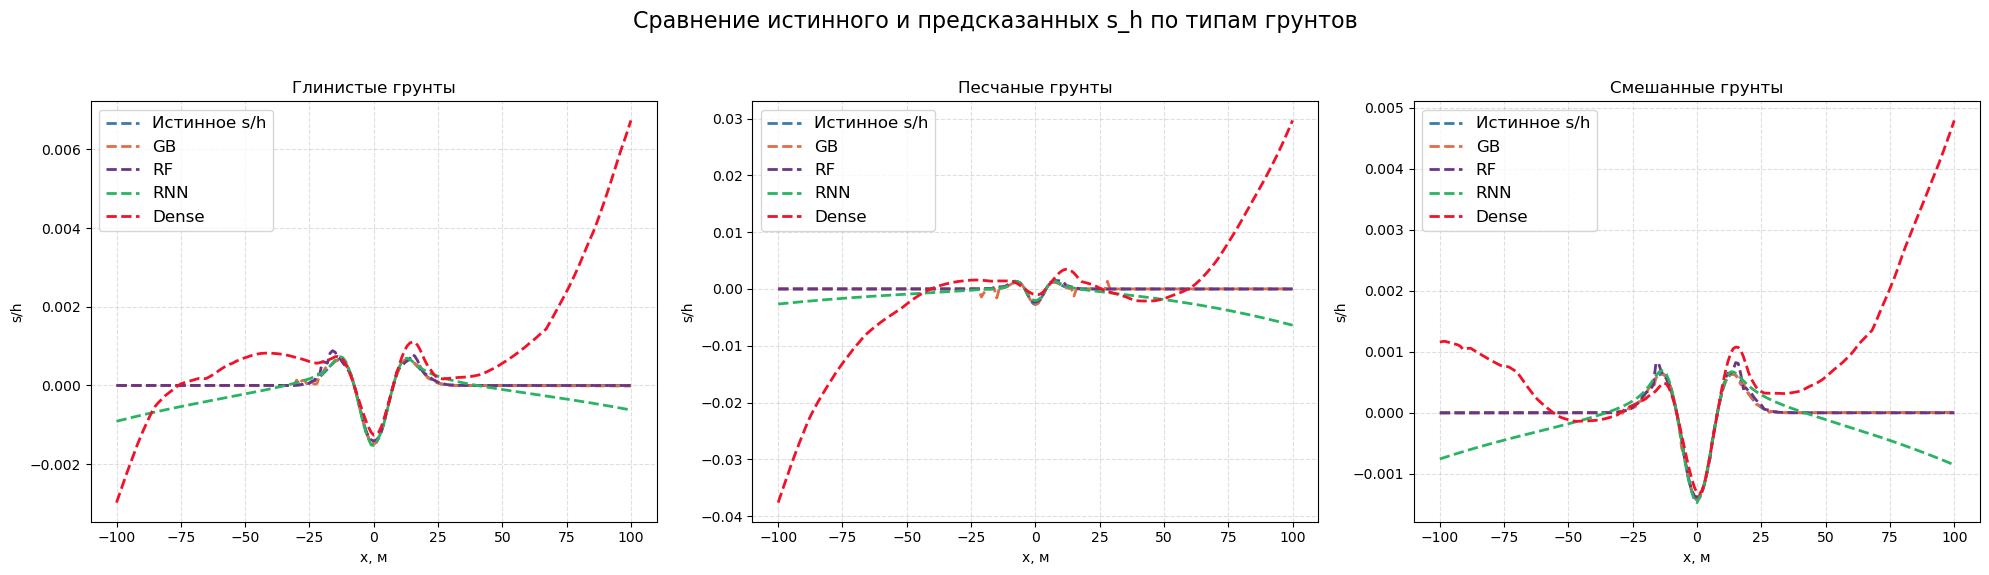

In [22]:
predictor = TunnelPredictor_eh(
    main_data=data_600,
    model_gb=model_obj_GB.model,
    model_rf=model_obj_RF.model,
    model_rnn=model_obj_RNN.model,
    model_dense=model_obj_Dense.model_Dense
)

predictor.visualize_all()

## Сравнение работы моделей для разных выборок (с разными размерами)

### Gradient Boosting

In [272]:
dict_score_time_GB = {}
dict_score_time_GB_new_data = {}

#### Выборка размером 600

Train Score: 5.25e-01 RMSE
Test Score: 7.59e-01 RMSE


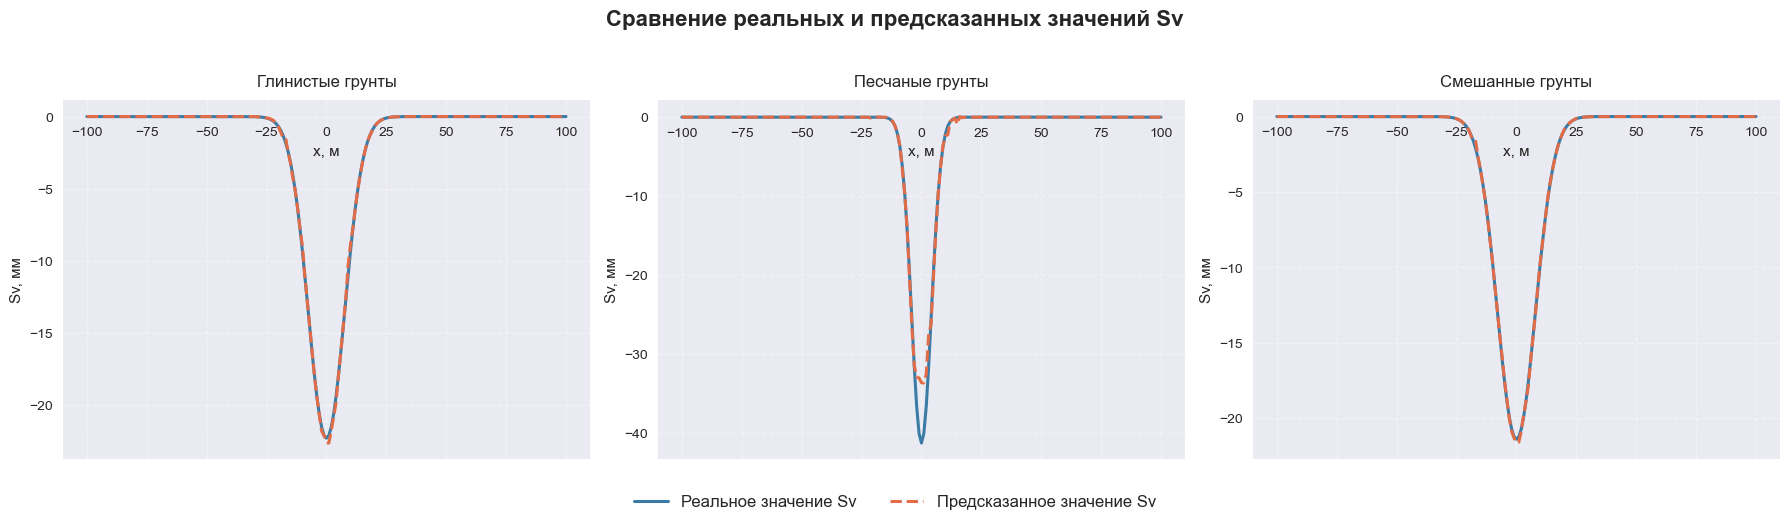

Предсказанные значения: [ 3.9760815e-03 -9.6135960e+00 -2.1111522e+00 -1.9681428e-03]
Истинные значения: [-1.34953546e-03 -9.40439551e+00 -2.11095311e+00 -5.19913987e-05]
Ошибка RMSE: 1.04639e-01, ошибка MAE: 5.41603e-02
Предсказанные значения: [ 3.9760815e-03 -9.6135960e+00 -2.1111522e+00 -1.9681428e-03]
Истинные значения: [-1.34953546e-03 -9.40439551e+00 -2.11095311e+00 -5.19913987e-05]
Ошибка RMSE: 1.04639e-01, ошибка MAE: 5.41603e-02


In [273]:
model_obj_GB_600 = TunnelSettlementModel(data_600, new_data)

dict_600 = model_obj_GB_600.train_model()

model_obj_GB_600.vizual_result()

y_pred, MAE_new_data_600 = model_obj_GB_600.check_new_data(new_data, y_true)['y_pred'], model_obj_GB_600.check_new_data(new_data, y_true)['MAE']

dict_score_time_GB['Параметры выборки 600']=dict_600
dict_score_time_GB_new_data['MAE для выборки 600']=MAE_new_data_600

#### Размер 1800

Train Score: 1.36e-01 RMSE
Test Score: 3.08e-01 RMSE


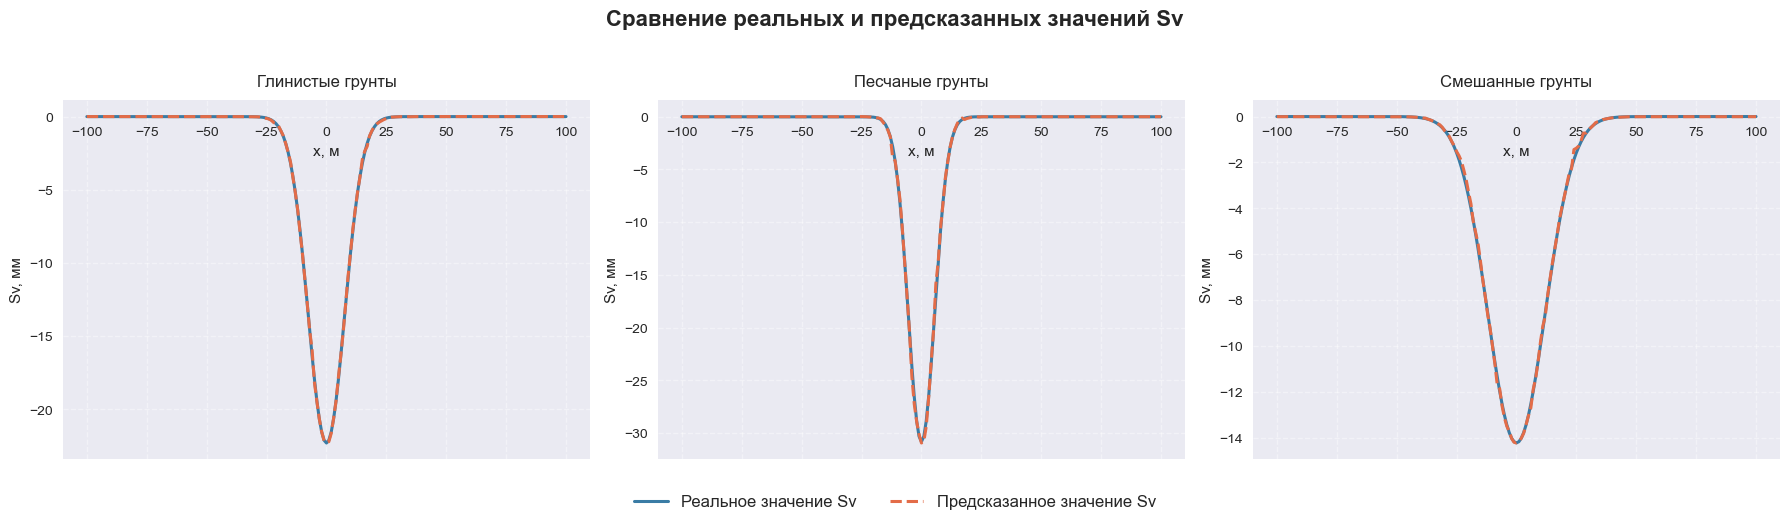

Предсказанные значения: [-2.1896362e-03 -9.8308811e+00 -2.4534299e+00  2.1614982e-03]
Истинные значения: [-1.34953546e-03 -9.40439551e+00 -2.11095311e+00 -5.19913987e-05]
Ошибка RMSE: 2.73489e-01, ошибка MAE: 1.93004e-01
Предсказанные значения: [-2.1896362e-03 -9.8308811e+00 -2.4534299e+00  2.1614982e-03]
Истинные значения: [-1.34953546e-03 -9.40439551e+00 -2.11095311e+00 -5.19913987e-05]
Ошибка RMSE: 2.73489e-01, ошибка MAE: 1.93004e-01


In [274]:
model_obj_GB_1800 = TunnelSettlementModel(data_1800, new_data)

dict_1800 = model_obj_GB_1800.train_model()

model_obj_GB_1800.vizual_result()

y_pred, MAE_new_data_1800 = model_obj_GB_1800.check_new_data(new_data, y_true)['y_pred'], model_obj_GB_1800.check_new_data(new_data, y_true)['MAE']

dict_score_time_GB['Параметры выборки 1800']=dict_1800
dict_score_time_GB_new_data['MAE для выборки 1800']=MAE_new_data_1800

#### Размер 4800

Train Score: 5.00e-02 RMSE
Test Score: 1.16e-01 RMSE


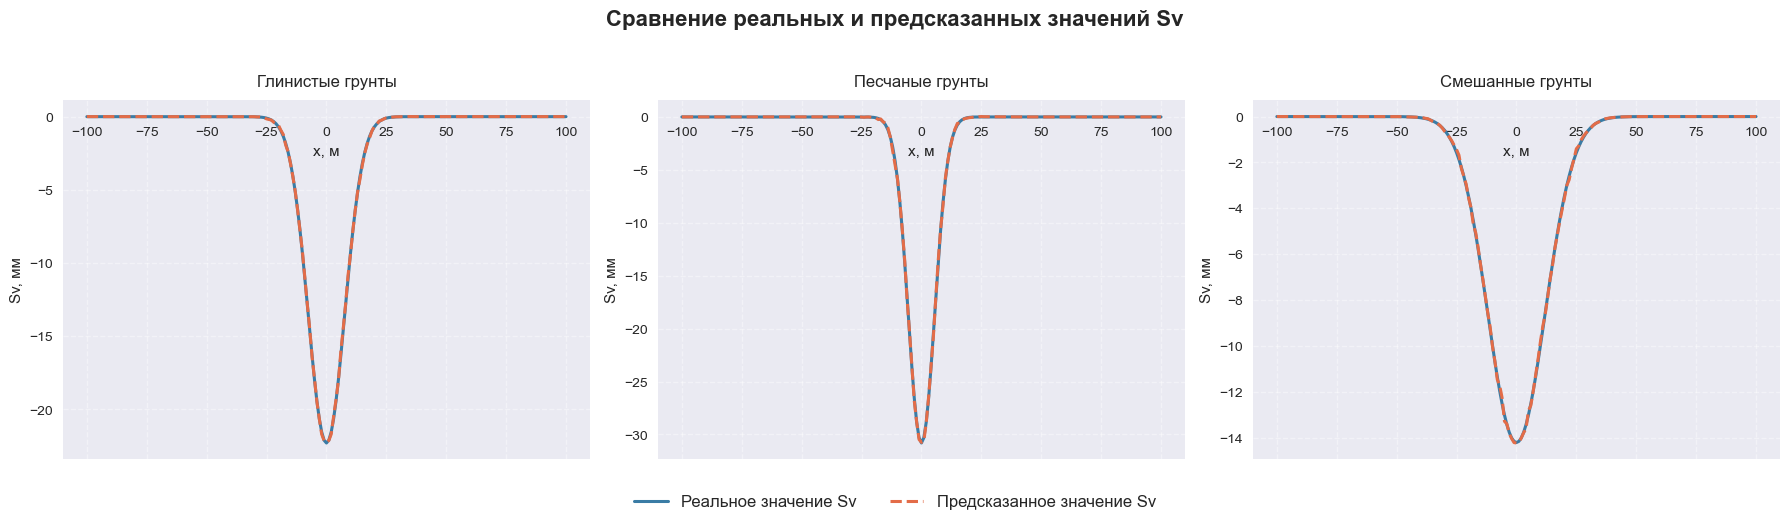

Предсказанные значения: [-5.1769945e-03 -9.4187269e+00 -2.1717675e+00 -1.1683537e-03]
Истинные значения: [-1.34953546e-03 -9.40439551e+00 -2.11095311e+00 -5.19913987e-05]
Ошибка RMSE: 3.13036e-02, ошибка MAE: 2.00224e-02
Предсказанные значения: [-5.1769945e-03 -9.4187269e+00 -2.1717675e+00 -1.1683537e-03]
Истинные значения: [-1.34953546e-03 -9.40439551e+00 -2.11095311e+00 -5.19913987e-05]
Ошибка RMSE: 3.13036e-02, ошибка MAE: 2.00224e-02


In [275]:
model_obj_GB_4800 = TunnelSettlementModel(data_4800, new_data)

dict_4800 = model_obj_GB_4800.train_model()

model_obj_GB_4800.vizual_result()

y_pred, MAE_new_data_4800 = model_obj_GB_4800.check_new_data(new_data, y_true)['y_pred'], model_obj_GB_4800.check_new_data(new_data, y_true)['MAE']

dict_score_time_GB['Параметры выборки 4800']=dict_4800
dict_score_time_GB_new_data['MAE для выборки 4800']=MAE_new_data_4800

#### Выборка 7200

Train Score: 1.58e+00 RMSE
Test Score: 1.41e+00 RMSE


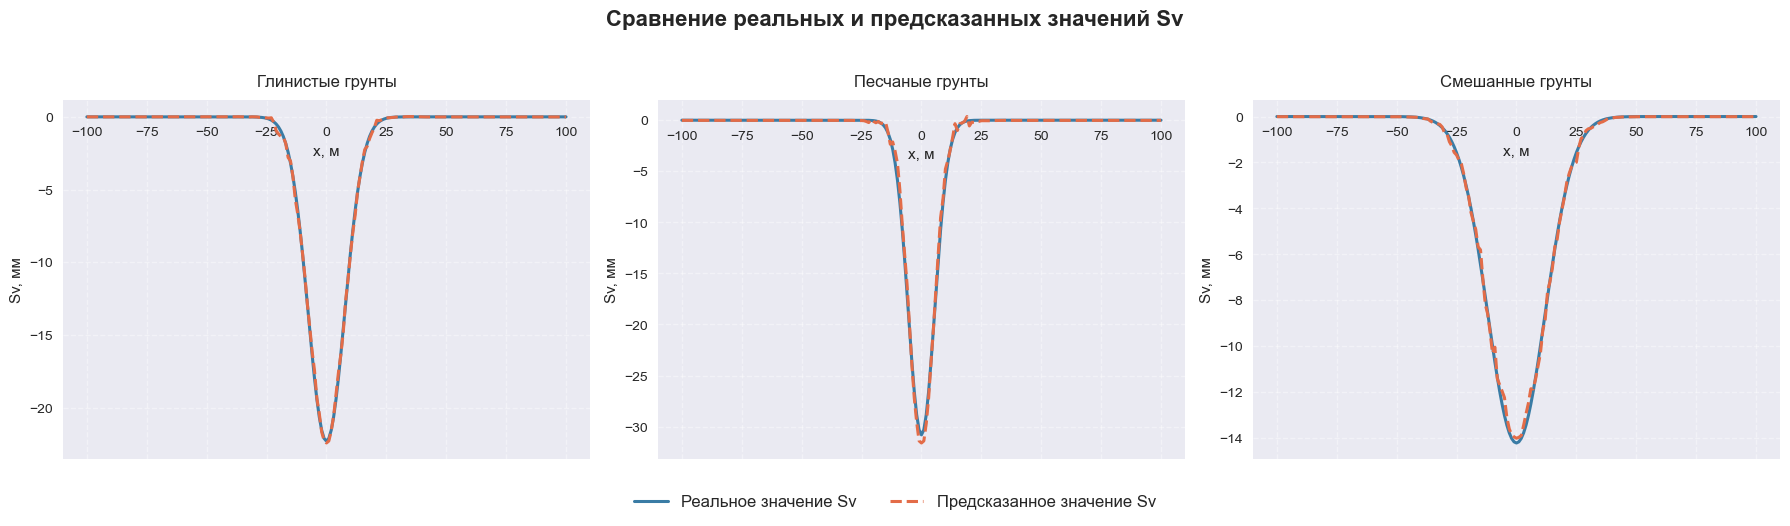

Предсказанные значения: [ 1.4770771e-02 -9.6458197e+00 -1.8050157e+00 -3.1642036e-03]
Истинные значения: [-1.34953546e-03 -9.40439551e+00 -2.11095311e+00 -5.19913987e-05]
Ошибка RMSE: 1.95034e-01, ошибка MAE: 1.41649e-01
Предсказанные значения: [ 1.4770771e-02 -9.6458197e+00 -1.8050157e+00 -3.1642036e-03]
Истинные значения: [-1.34953546e-03 -9.40439551e+00 -2.11095311e+00 -5.19913987e-05]
Ошибка RMSE: 1.95034e-01, ошибка MAE: 1.41649e-01


In [276]:
model_obj_GB_7200 = TunnelSettlementModel(data_7200, new_data)

dict_7200 = model_obj_GB_7200.train_model()

model_obj_GB_7200.vizual_result()

y_pred, MAE_new_data_7200 = model_obj_GB_7200.check_new_data(new_data, y_true)['y_pred'], model_obj_GB_7200.check_new_data(new_data, y_true)['MAE']

dict_score_time_GB['Параметры выборки 7200']=dict_7200
dict_score_time_GB_new_data['MAE выборки 7200']=MAE_new_data_7200

#### Размер 14400

Train Score: 9.13e-01 RMSE
Test Score: 1.32e+00 RMSE


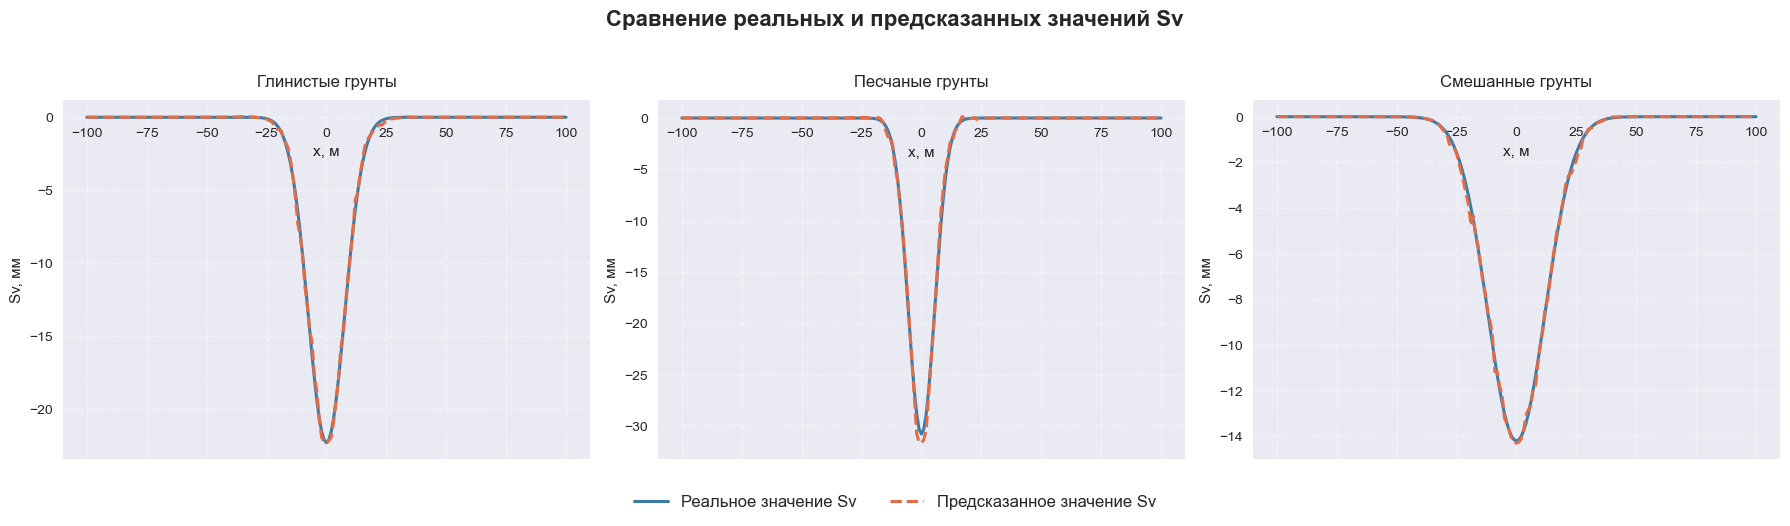

Предсказанные значения: [-1.2432278e-02 -9.5292368e+00 -1.8772061e+00 -1.7733668e-03]
Истинные значения: [-1.34953546e-03 -9.40439551e+00 -2.11095311e+00 -5.19913987e-05]
Ошибка RMSE: 1.32617e-01, ошибка MAE: 9.28481e-02
Предсказанные значения: [-1.2432278e-02 -9.5292368e+00 -1.8772061e+00 -1.7733668e-03]
Истинные значения: [-1.34953546e-03 -9.40439551e+00 -2.11095311e+00 -5.19913987e-05]
Ошибка RMSE: 1.32617e-01, ошибка MAE: 9.28481e-02


In [277]:
model_obj_GB_14400 = TunnelSettlementModel(data_14400, new_data)

dict_14400 = model_obj_GB_14400.train_model()


model_obj_GB_14400.vizual_result()

y_pred, MAE_new_data_14400 = model_obj_GB_14400.check_new_data(new_data, y_true)['y_pred'], model_obj_GB_14400.check_new_data(new_data, y_true)['MAE']

dict_score_time_GB['Параметры выборки 14400']=dict_14400
dict_score_time_GB_new_data['MAE для выборки 14400']=MAE_new_data_14400

#### Размер 28800

Train Score: 6.39e-01 RMSE
Test Score: 7.74e-01 RMSE


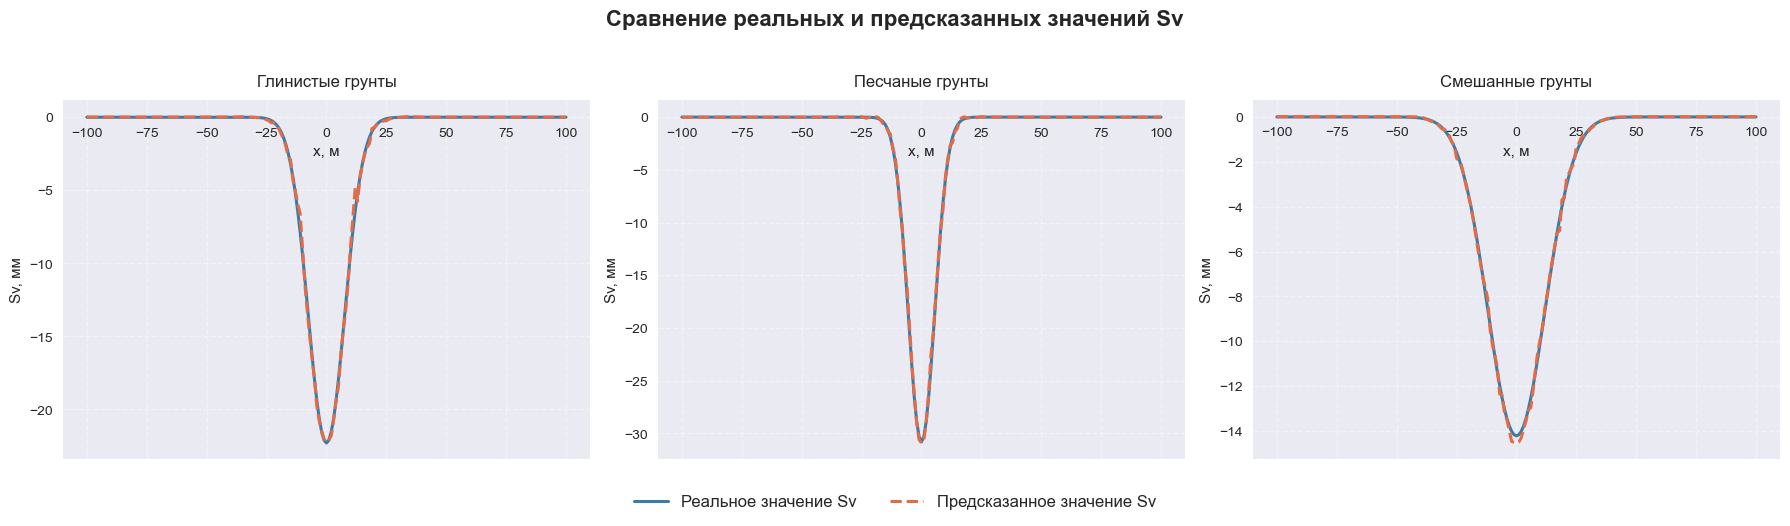

Предсказанные значения: [ 0.01554483 -9.710478   -2.1841235  -0.01326635]
Истинные значения: [-1.34953546e-03 -9.40439551e+00 -2.11095311e+00 -5.19913987e-05]
Ошибка RMSE: 1.57718e-01, ошибка MAE: 1.02340e-01
Предсказанные значения: [ 0.01554483 -9.710478   -2.1841235  -0.01326635]
Истинные значения: [-1.34953546e-03 -9.40439551e+00 -2.11095311e+00 -5.19913987e-05]
Ошибка RMSE: 1.57718e-01, ошибка MAE: 1.02340e-01


In [278]:
model_obj_GB_28800 = TunnelSettlementModel(data_28800, new_data)

dict_28800 = model_obj_GB_28800.train_model()


model_obj_GB_28800.vizual_result()

y_pred, MAE_new_data_28800 = model_obj_GB_28800.check_new_data(new_data, y_true)['y_pred'], model_obj_GB_28800.check_new_data(new_data, y_true)['MAE']

dict_score_time_GB['Параметры выборки 28800']=dict_28800
dict_score_time_GB_new_data['MAE выборки 28800']=MAE_new_data_28800

In [279]:
dict_score_time_GB

{'Параметры выборки 600': {'test_score': 0.14891542596567417,
  'elapsed_time': 0.27193212509155273},
 'Параметры выборки 1800': {'test_score': 0.08106043135828359,
  'elapsed_time': 0.511073112487793},
 'Параметры выборки 4800': {'test_score': 0.03879071438398752,
  'elapsed_time': 0.1610889434814453},
 'Параметры выборки 7200': {'test_score': 0.20729297684740033,
  'elapsed_time': 0.4619429111480713},
 'Параметры выборки 14400': {'test_score': 0.16374870944662573,
  'elapsed_time': 0.6003711223602295},
 'Параметры выборки 28800': {'test_score': 0.12734147375825253,
  'elapsed_time': 0.5424580574035645}}

In [212]:
dict_score_time_GB_new_data

{'MAE для выборки 600': 0.05416032074541252,
 'MAE для выборки 1800': 0.19300400662194378,
 'MAE для выборки 4800': 0.020022398910874258,
 'MAE выборки 7200': 0.14164852496752572,
 'MAE для выборки 14400': 0.09284810612546662,
 'MAE выборки 28800': 0.10234036368607011}

### Рекуррентная НС

In [216]:
dict_score_time_RNN = {}
dict_score_time_RNN_new_data = {}

#### Размер 600

Epoch 1/100
16/16 - 1s - 52ms/step - loss: 40.3241
Epoch 2/100
16/16 - 0s - 3ms/step - loss: 39.0559
Epoch 3/100
16/16 - 0s - 3ms/step - loss: 38.6978
Epoch 4/100
16/16 - 0s - 3ms/step - loss: 38.4270
Epoch 5/100
16/16 - 0s - 3ms/step - loss: 36.8713
Epoch 6/100
16/16 - 0s - 3ms/step - loss: 33.5872
Epoch 7/100
16/16 - 0s - 3ms/step - loss: 26.2361
Epoch 8/100
16/16 - 0s - 3ms/step - loss: 19.7474
Epoch 9/100
16/16 - 0s - 3ms/step - loss: 17.5530
Epoch 10/100
16/16 - 0s - 3ms/step - loss: 14.2666
Epoch 11/100
16/16 - 0s - 3ms/step - loss: 12.3213
Epoch 12/100
16/16 - 0s - 3ms/step - loss: 11.0801
Epoch 13/100
16/16 - 0s - 3ms/step - loss: 9.8107
Epoch 14/100
16/16 - 0s - 3ms/step - loss: 9.2060
Epoch 15/100
16/16 - 0s - 3ms/step - loss: 8.3563
Epoch 16/100
16/16 - 0s - 3ms/step - loss: 7.8061
Epoch 17/100
16/16 - 0s - 3ms/step - loss: 7.2378
Epoch 18/100
16/16 - 0s - 3ms/step - loss: 6.9101
Epoch 19/100
16/16 - 0s - 3ms/step - loss: 6.4632
Epoch 20/100
16/16 - 0s - 3ms/step - loss: 6.0

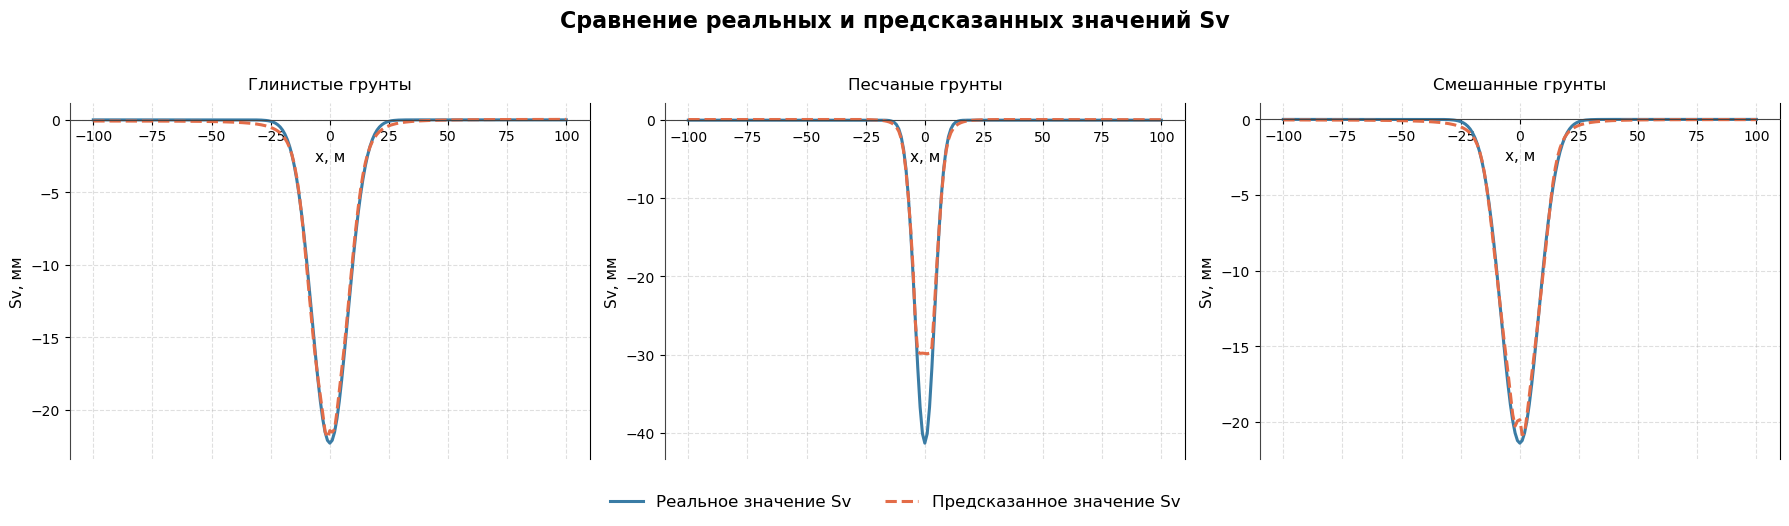

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Предсказанные значения: [[-6.775193 ]
 [ 3.494916 ]
 [-1.3553553]
 [ 5.0892177]]
Истинные значения: [-1.34953546e-03 -9.40439551e+00 -2.11095311e+00 -5.19913987e-05]
Ошибка RMSE: 7.72575e+00, ошибка MAE: 6.37951e+00
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Предсказанные значения: [[-6.775193 ]
 [ 3.494916 ]
 [-1.3553553]
 [ 5.0892177]]
Истинные значения: [-1.34953546e-03 -9.40439551e+00 -2.11095311e+00 -5.19913987e-05]
Ошибка RMSE: 7.72575e+00, ошибка MAE: 6.37951e+00
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Предсказанные значения: [[-6.775193 ]
 [ 3.494916 ]
 [-1.3553553]
 [ 5.0892177]]
Истинные значения: [-1.34953546e-03 -9.40439551e+00 -2.11095311e+00 -5.19913987e-05]
Ошибка RMSE: 7.72575e+00, ошибка MAE: 6.37951e+00


In [217]:
model_obj_RNN_600 = TunnelSettlementModelRNN(data_600, new_data)

# # Обучаем модель
dict_RNN_600 = model_obj_RNN_600.train_model()

# # Визуализируем результаты на основном датасете
model_obj_RNN_600.vizual_result()


y_pred = model_obj_RNN_600.check_new_data(new_data, y_true)

y_pred, MAE_RNN_new_data_600 = model_obj_RNN_600.check_new_data(new_data, y_true)['y_pred'], model_obj_RNN_600.check_new_data(new_data, y_true)['MAE']

dict_score_time_RNN['Параметры выборки 600']=dict_RNN_600
dict_score_time_RNN_new_data['MAE для выборки 600']=  MAE_RNN_new_data_600 

#### Размер 1800

Epoch 1/100
46/46 - 1s - 19ms/step - loss: 28.8787
Epoch 2/100
46/46 - 0s - 2ms/step - loss: 28.1588
Epoch 3/100
46/46 - 0s - 3ms/step - loss: 26.4453
Epoch 4/100
46/46 - 0s - 2ms/step - loss: 14.9392
Epoch 5/100
46/46 - 0s - 2ms/step - loss: 8.3915
Epoch 6/100
46/46 - 0s - 2ms/step - loss: 6.1524
Epoch 7/100
46/46 - 0s - 2ms/step - loss: 4.9995
Epoch 8/100
46/46 - 0s - 2ms/step - loss: 4.1164
Epoch 9/100
46/46 - 0s - 2ms/step - loss: 3.5064
Epoch 10/100
46/46 - 0s - 2ms/step - loss: 3.0435
Epoch 11/100
46/46 - 0s - 2ms/step - loss: 2.7508
Epoch 12/100
46/46 - 0s - 2ms/step - loss: 2.5859
Epoch 13/100
46/46 - 0s - 2ms/step - loss: 2.6050
Epoch 14/100
46/46 - 0s - 2ms/step - loss: 2.1966
Epoch 15/100
46/46 - 0s - 2ms/step - loss: 2.0537
Epoch 16/100
46/46 - 0s - 2ms/step - loss: 1.8879
Epoch 17/100
46/46 - 0s - 2ms/step - loss: 1.7478
Epoch 18/100
46/46 - 0s - 2ms/step - loss: 1.5608
Epoch 19/100
46/46 - 0s - 2ms/step - loss: 1.3916
Epoch 20/100
46/46 - 0s - 2ms/step - loss: 1.2463
Epoc

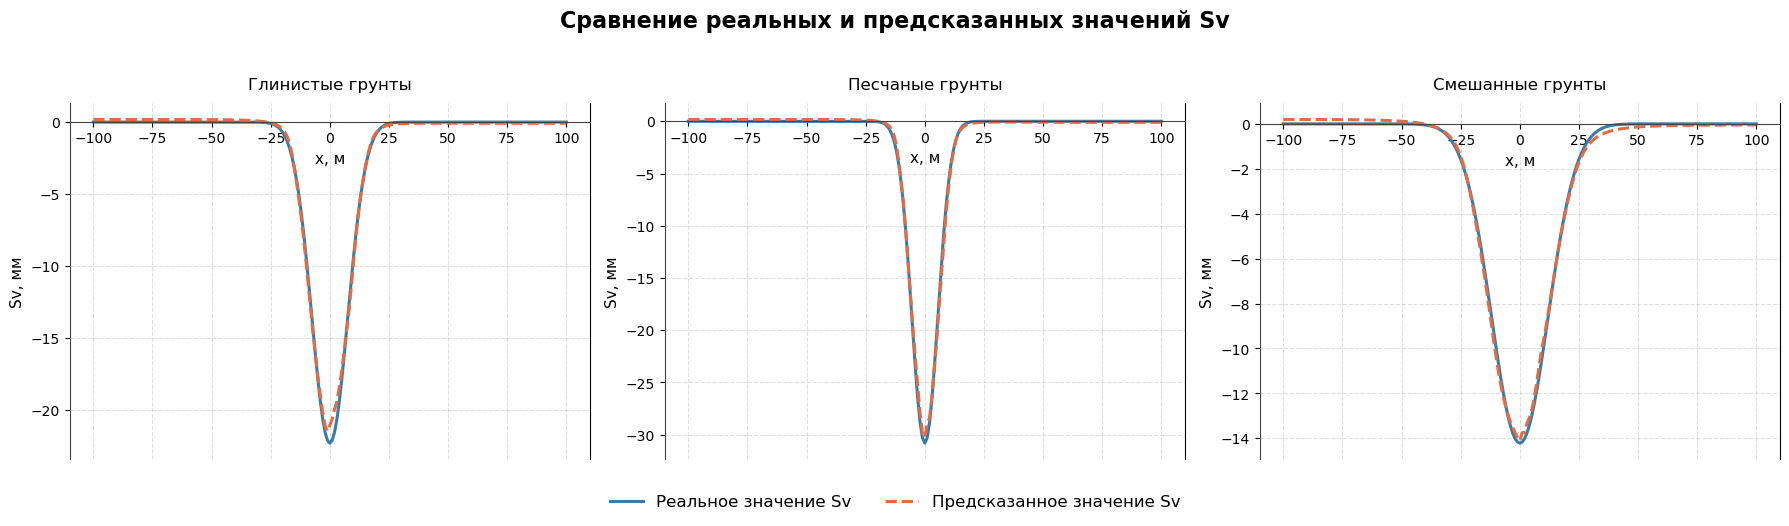

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Предсказанные значения: [[ -9.443337]
 [-13.083163]
 [-10.52607 ]
 [-19.619513]]
Истинные значения: [-1.34953546e-03 -9.40439551e+00 -2.11095311e+00 -5.19913987e-05]
Ошибка RMSE: 1.18155e+01, ошибка MAE: 1.02888e+01
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Предсказанные значения: [[ -9.443337]
 [-13.083163]
 [-10.52607 ]
 [-19.619513]]
Истинные значения: [-1.34953546e-03 -9.40439551e+00 -2.11095311e+00 -5.19913987e-05]
Ошибка RMSE: 1.18155e+01, ошибка MAE: 1.02888e+01
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Предсказанные значения: [[ -9.443337]
 [-13.083163]
 [-10.52607 ]
 [-19.619513]]
Истинные значения: [-1.34953546e-03 -9.40439551e+00 -2.11095311e+00 -5.19913987e-05]
Ошибка RMSE: 1.18155e+01, ошибка MAE: 1.02888e+01


In [219]:
model_obj_RNN_1800 = TunnelSettlementModelRNN(data_1800, new_data)

# # Обучаем модель
dict_RNN_1800 = model_obj_RNN_1800.train_model()

# # Визуализируем результаты на основном датасете
model_obj_RNN_1800.vizual_result()


y_pred = model_obj_RNN_1800.check_new_data(new_data, y_true)

y_pred, MAE_RNN_new_data_1800 = model_obj_RNN_1800.check_new_data(new_data, y_true)['y_pred'], model_obj_RNN_1800.check_new_data(new_data, y_true)['MAE']

dict_score_time_RNN['Параметры выборки 1800']=dict_RNN_1800
dict_score_time_RNN_new_data['MAE для выборки 1800']=  MAE_RNN_new_data_1800

#### Размер 4800

Epoch 1/100
121/121 - 2s - 14ms/step - loss: 20.4002
Epoch 2/100
121/121 - 0s - 2ms/step - loss: 5.1675
Epoch 3/100
121/121 - 0s - 2ms/step - loss: 3.1494
Epoch 4/100
121/121 - 0s - 2ms/step - loss: 2.1217
Epoch 5/100
121/121 - 0s - 2ms/step - loss: 1.4794
Epoch 6/100
121/121 - 0s - 2ms/step - loss: 1.1563
Epoch 7/100
121/121 - 0s - 2ms/step - loss: 0.9015
Epoch 8/100
121/121 - 0s - 2ms/step - loss: 0.7999
Epoch 9/100
121/121 - 0s - 2ms/step - loss: 0.6938
Epoch 10/100
121/121 - 0s - 2ms/step - loss: 0.6001
Epoch 11/100
121/121 - 0s - 2ms/step - loss: 0.5018
Epoch 12/100
121/121 - 0s - 2ms/step - loss: 0.3947
Epoch 13/100
121/121 - 0s - 2ms/step - loss: 0.3868
Epoch 14/100
121/121 - 0s - 2ms/step - loss: 0.3980
Epoch 15/100
121/121 - 0s - 2ms/step - loss: 0.2775
Epoch 16/100
121/121 - 0s - 2ms/step - loss: 0.2572
Epoch 17/100
121/121 - 0s - 2ms/step - loss: 0.2463
Epoch 18/100
121/121 - 0s - 2ms/step - loss: 0.2102
Epoch 19/100
121/121 - 0s - 2ms/step - loss: 0.1931
Epoch 20/100
121/12

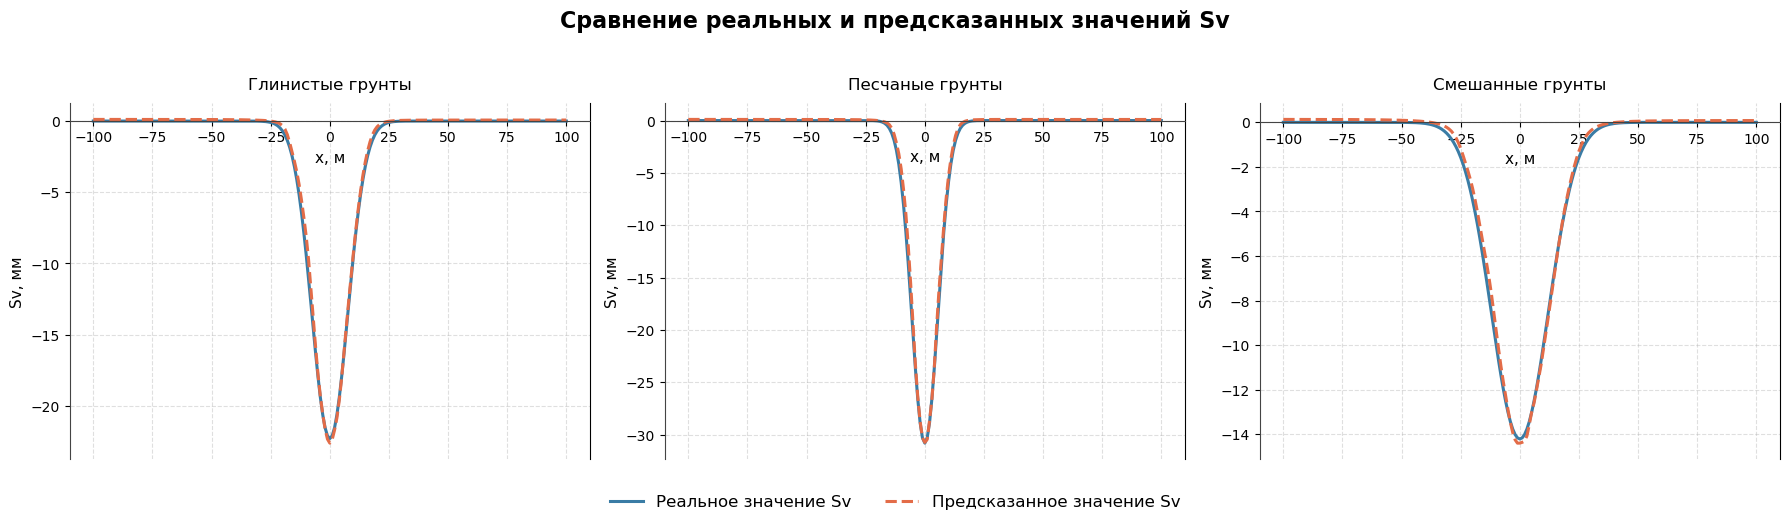

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Предсказанные значения: [[ -4.247528 ]
 [-15.443462 ]
 [ -7.4808245]
 [-15.685005 ]]
Истинные значения: [-1.34953546e-03 -9.40439551e+00 -2.11095311e+00 -5.19913987e-05]
Ошибка RMSE: 9.07405e+00, ошибка MAE: 7.83502e+00
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Предсказанные значения: [[ -4.247528 ]
 [-15.443462 ]
 [ -7.4808245]
 [-15.685005 ]]
Истинные значения: [-1.34953546e-03 -9.40439551e+00 -2.11095311e+00 -5.19913987e-05]
Ошибка RMSE: 9.07405e+00, ошибка MAE: 7.83502e+00
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Предсказанные значения: [[ -4.247528 ]
 [-15.443462 ]
 [ -7.4808245]
 [-15.685005 ]]
Истинные значения: [-1.34953546e-03 -9.40439551e+00 -2.11095311e+00 -5.19913987e-05]
Ошибка RMSE: 9.07405e+00, ошибка MAE: 7.83502e+00


In [221]:
model_obj_RNN_4800 = TunnelSettlementModelRNN(data_4800, new_data)

# # Обучаем модель
dict_RNN_4800 = model_obj_RNN_4800.train_model()

# # Визуализируем результаты на основном датасете
model_obj_RNN_4800.vizual_result()


y_pred = model_obj_RNN_4800.check_new_data(new_data, y_true)

y_pred, MAE_RNN_new_data_4800 = model_obj_RNN_4800.check_new_data(new_data, y_true)['y_pred'], model_obj_RNN_4800.check_new_data(new_data, y_true)['MAE']

dict_score_time_RNN['Параметры выборки 4800']=dict_RNN_4800
dict_score_time_RNN_new_data['MAE для выборки 4800']=  MAE_RNN_new_data_4800

#### Размер 7200

Epoch 1/100
181/181 - 1s - 7ms/step - loss: 108.7630
Epoch 2/100
181/181 - 0s - 2ms/step - loss: 60.0192
Epoch 3/100
181/181 - 0s - 2ms/step - loss: 42.9680
Epoch 4/100
181/181 - 0s - 2ms/step - loss: 32.0641
Epoch 5/100
181/181 - 0s - 2ms/step - loss: 24.0478
Epoch 6/100
181/181 - 0s - 2ms/step - loss: 19.0908
Epoch 7/100
181/181 - 0s - 2ms/step - loss: 15.5811
Epoch 8/100
181/181 - 0s - 2ms/step - loss: 13.3557
Epoch 9/100
181/181 - 0s - 2ms/step - loss: 11.1742
Epoch 10/100
181/181 - 0s - 2ms/step - loss: 10.4319
Epoch 11/100
181/181 - 0s - 2ms/step - loss: 8.8275
Epoch 12/100
181/181 - 0s - 2ms/step - loss: 7.5531
Epoch 13/100
181/181 - 0s - 2ms/step - loss: 7.1893
Epoch 14/100
181/181 - 0s - 2ms/step - loss: 6.2815
Epoch 15/100
181/181 - 0s - 2ms/step - loss: 5.5033
Epoch 16/100
181/181 - 0s - 2ms/step - loss: 5.9695
Epoch 17/100
181/181 - 0s - 2ms/step - loss: 4.7816
Epoch 18/100
181/181 - 0s - 2ms/step - loss: 4.4237
Epoch 19/100
181/181 - 0s - 2ms/step - loss: 3.8670
Epoch 20/1

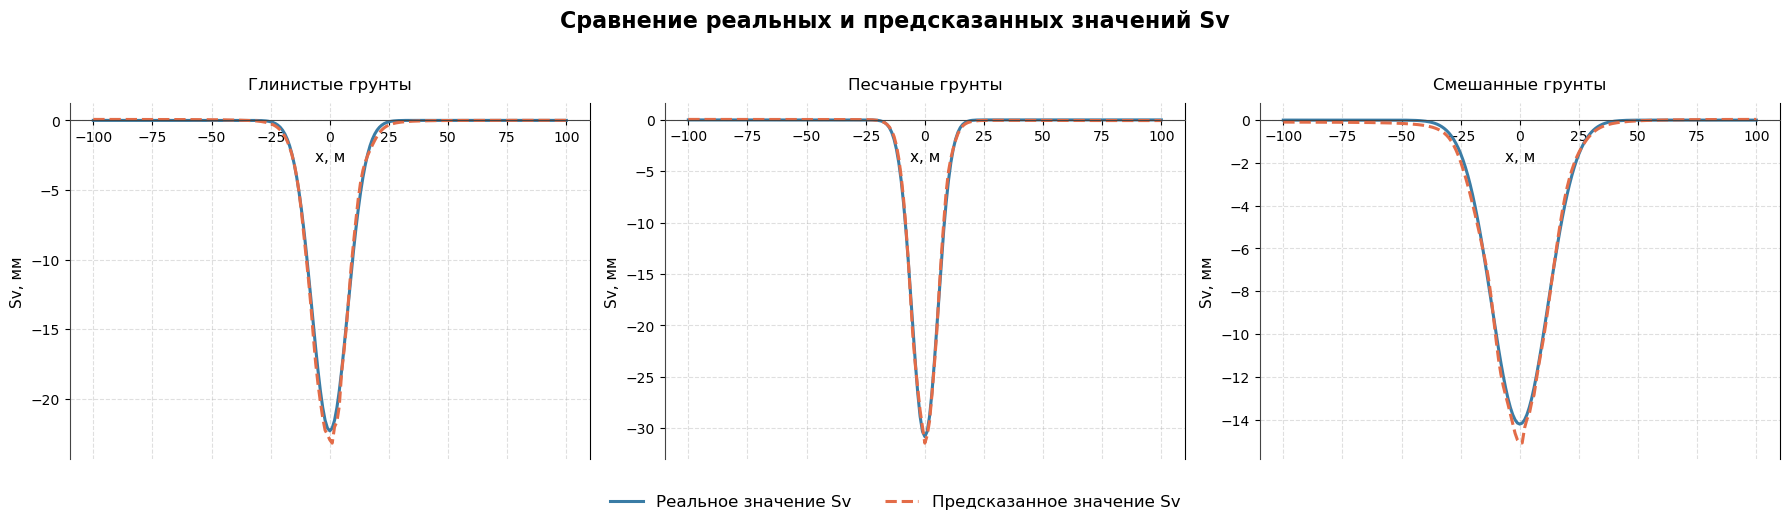

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Предсказанные значения: [[-19.15504 ]
 [-31.915508]
 [-31.36084 ]
 [-22.15542 ]]
Истинные значения: [-1.34953546e-03 -9.40439551e+00 -2.11095311e+00 -5.19913987e-05]
Ошибка RMSE: 2.35586e+01, ошибка MAE: 2.32675e+01
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Предсказанные значения: [[-19.15504 ]
 [-31.915508]
 [-31.36084 ]
 [-22.15542 ]]
Истинные значения: [-1.34953546e-03 -9.40439551e+00 -2.11095311e+00 -5.19913987e-05]
Ошибка RMSE: 2.35586e+01, ошибка MAE: 2.32675e+01
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Предсказанные значения: [[-19.15504 ]
 [-31.915508]
 [-31.36084 ]
 [-22.15542 ]]
Истинные значения: [-1.34953546e-03 -9.40439551e+00 -2.11095311e+00 -5.19913987e-05]
Ошибка RMSE: 2.35586e+01, ошибка MAE: 2.32675e+01


In [224]:
model_obj_RNN_7200 = TunnelSettlementModelRNN(data_7200, new_data)

# # Обучаем модель
dict_RNN_7200 = model_obj_RNN_7200.train_model()

# # Визуализируем результаты на основном датасете
model_obj_RNN_7200.vizual_result()


y_pred = model_obj_RNN_7200.check_new_data(new_data, y_true)

y_pred, MAE_RNN_new_data_7200 = model_obj_RNN_7200.check_new_data(new_data, y_true)['y_pred'], model_obj_RNN_7200.check_new_data(new_data, y_true)['MAE']

dict_score_time_RNN['Параметры выборки 7200']=dict_RNN_7200
dict_score_time_RNN_new_data['MAE для выборки 7200']=  MAE_RNN_new_data_7200

#### Размер 14400

Epoch 1/100
362/362 - 2s - 5ms/step - loss: 82.1503
Epoch 2/100
362/362 - 1s - 2ms/step - loss: 35.6181
Epoch 3/100
362/362 - 1s - 2ms/step - loss: 21.1437
Epoch 4/100
362/362 - 1s - 2ms/step - loss: 14.5461
Epoch 5/100
362/362 - 1s - 2ms/step - loss: 10.0752
Epoch 6/100
362/362 - 1s - 2ms/step - loss: 7.9300
Epoch 7/100
362/362 - 1s - 2ms/step - loss: 6.2782
Epoch 8/100
362/362 - 1s - 2ms/step - loss: 5.3055
Epoch 9/100
362/362 - 1s - 2ms/step - loss: 4.2906
Epoch 10/100
362/362 - 1s - 2ms/step - loss: 3.7402
Epoch 11/100
362/362 - 1s - 2ms/step - loss: 3.0255
Epoch 12/100
362/362 - 1s - 2ms/step - loss: 2.4723
Epoch 13/100
362/362 - 1s - 2ms/step - loss: 2.9399
Epoch 14/100
362/362 - 1s - 2ms/step - loss: 2.2375
Epoch 15/100
362/362 - 1s - 2ms/step - loss: 2.0972
Epoch 16/100
362/362 - 1s - 2ms/step - loss: 1.7880
Epoch 17/100
362/362 - 1s - 2ms/step - loss: 1.4828
Epoch 18/100
362/362 - 1s - 2ms/step - loss: 1.6691
Epoch 19/100
362/362 - 1s - 2ms/step - loss: 1.1179
Epoch 20/100
362

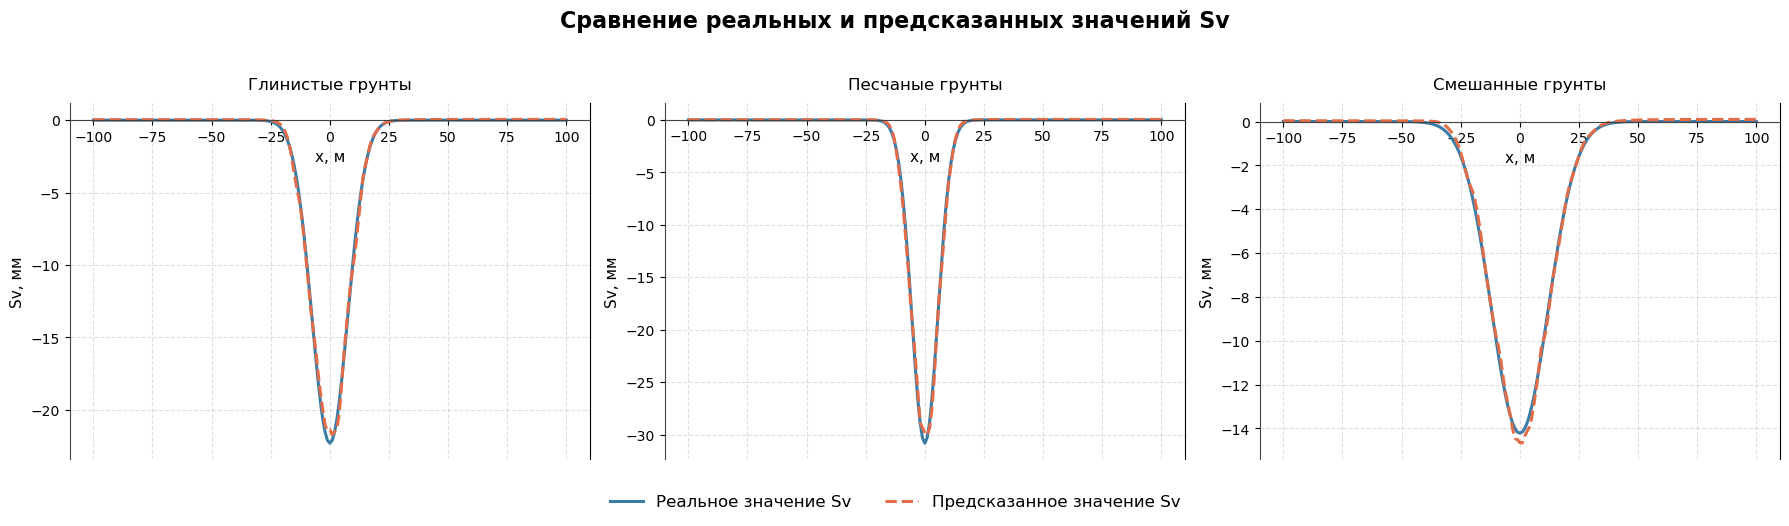

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Предсказанные значения: [[ -50.794754]
 [ -75.81805 ]
 [-117.61112 ]
 [ -87.51043 ]]
Истинные значения: [-1.34953546e-03 -9.40439551e+00 -2.11095311e+00 -5.19913987e-05]
Ошибка RMSE: 8.36497e+01, ошибка MAE: 8.00544e+01
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Предсказанные значения: [[ -50.794754]
 [ -75.81805 ]
 [-117.61112 ]
 [ -87.51043 ]]
Истинные значения: [-1.34953546e-03 -9.40439551e+00 -2.11095311e+00 -5.19913987e-05]
Ошибка RMSE: 8.36497e+01, ошибка MAE: 8.00544e+01
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Предсказанные значения: [[ -50.794754]
 [ -75.81805 ]
 [-117.61112 ]
 [ -87.51043 ]]
Истинные значения: [-1.34953546e-03 -9.40439551e+00 -2.11095311e+00 -5.19913987e-05]
Ошибка RMSE: 8.36497e+01, ошибка MAE: 8.00544e+01


In [223]:
model_obj_RNN_14400 = TunnelSettlementModelRNN(data_14400, new_data)

# # Обучаем модель
dict_RNN_14400 = model_obj_RNN_14400.train_model()

# # Визуализируем результаты на основном датасете
model_obj_RNN_14400.vizual_result()


y_pred = model_obj_RNN_14400.check_new_data(new_data, y_true)

y_pred, MAE_RNN_new_data_14400 = model_obj_RNN_14400.check_new_data(new_data, y_true)['y_pred'], model_obj_RNN_14400.check_new_data(new_data, y_true)['MAE']

dict_score_time_RNN['Параметры выборки 14400']=dict_RNN_14400
dict_score_time_RNN_new_data['MAE для выборки 14400']=  MAE_RNN_new_data_14400

#### Размер 28800

Epoch 1/100
724/724 - 2s - 3ms/step - loss: 61.8186
Epoch 2/100
724/724 - 1s - 2ms/step - loss: 20.1827
Epoch 3/100
724/724 - 1s - 2ms/step - loss: 9.8295
Epoch 4/100
724/724 - 1s - 2ms/step - loss: 6.6046
Epoch 5/100
724/724 - 1s - 2ms/step - loss: 4.3638
Epoch 6/100
724/724 - 1s - 2ms/step - loss: 3.4452
Epoch 7/100
724/724 - 1s - 2ms/step - loss: 2.4537
Epoch 8/100
724/724 - 1s - 2ms/step - loss: 2.2259
Epoch 9/100
724/724 - 1s - 2ms/step - loss: 1.6353
Epoch 10/100
724/724 - 1s - 2ms/step - loss: 1.4441
Epoch 11/100
724/724 - 1s - 2ms/step - loss: 1.2653
Epoch 12/100
724/724 - 1s - 2ms/step - loss: 1.1349
Epoch 13/100
724/724 - 1s - 2ms/step - loss: 0.7763
Epoch 14/100
724/724 - 1s - 2ms/step - loss: 1.3041
Epoch 15/100
724/724 - 1s - 2ms/step - loss: 0.7002
Epoch 16/100
724/724 - 1s - 2ms/step - loss: 0.8495
Epoch 17/100
724/724 - 1s - 2ms/step - loss: 0.7118
Epoch 18/100
724/724 - 1s - 2ms/step - loss: 0.7462
Epoch 19/100
724/724 - 1s - 2ms/step - loss: 0.4422
Epoch 20/100
724/72

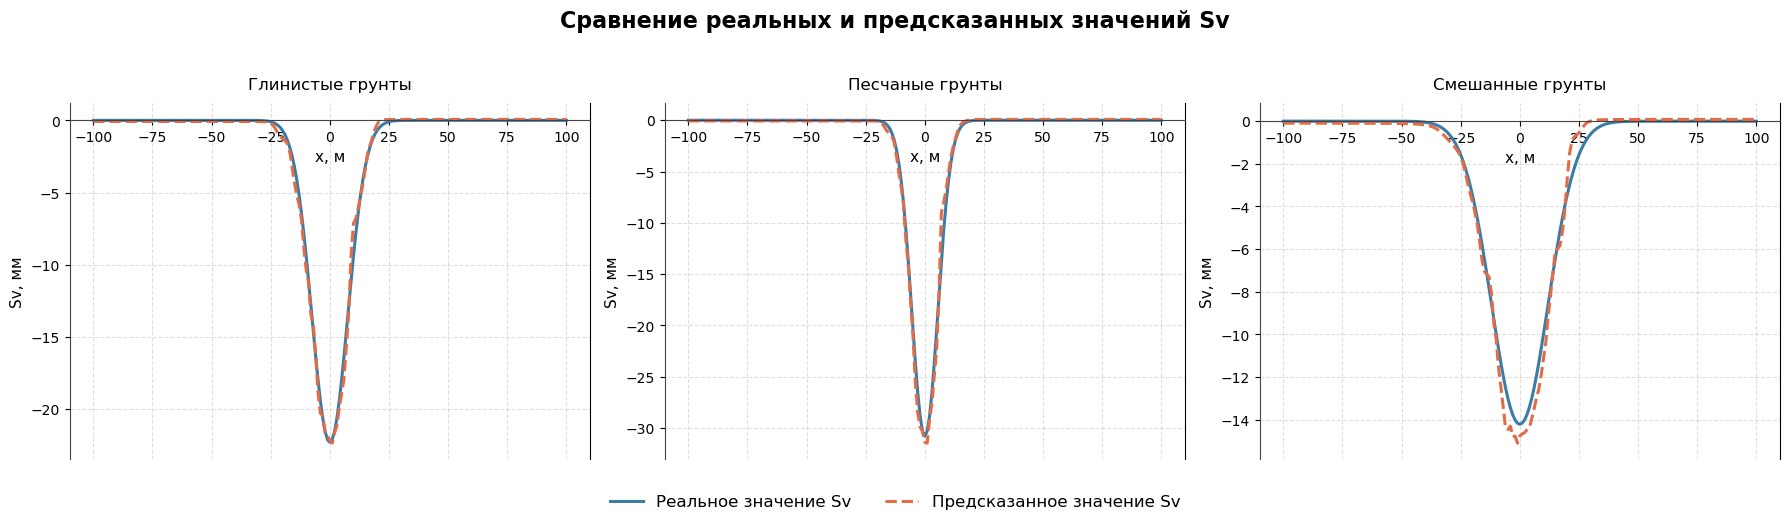

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Предсказанные значения: [[ -2.2787216 ]
 [ -1.78494   ]
 [-11.09425   ]
 [ -0.40311146]]
Истинные значения: [-1.34953546e-03 -9.40439551e+00 -2.11095311e+00 -5.19913987e-05]
Ошибка RMSE: 6.00218e+00, ошибка MAE: 4.82080e+00
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Предсказанные значения: [[ -2.2787216 ]
 [ -1.78494   ]
 [-11.09425   ]
 [ -0.40311146]]
Истинные значения: [-1.34953546e-03 -9.40439551e+00 -2.11095311e+00 -5.19913987e-05]
Ошибка RMSE: 6.00218e+00, ошибка MAE: 4.82080e+00
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Предсказанные значения: [[ -2.2787216 ]
 [ -1.78494   ]
 [-11.09425   ]
 [ -0.40311146]]
Истинные значения: [-1.34953546e-03 -9.40439551e+00 -2.11095311e+00 -5.19913987e-05]
Ошибка RMSE: 6.00218e+00, ошибка MAE: 4.82080e+00


In [225]:
model_obj_RNN_28800 = TunnelSettlementModelRNN(data_28800, new_data)

# # Обучаем модель
dict_RNN_28800 = model_obj_RNN_28800.train_model()

# # Визуализируем результаты на основном датасете
model_obj_RNN_28800.vizual_result()


y_pred = model_obj_RNN_28800.check_new_data(new_data, y_true)

y_pred, MAE_RNN_new_data_28800 = model_obj_RNN_28800.check_new_data(new_data, y_true)['y_pred'], model_obj_RNN_28800.check_new_data(new_data, y_true)['MAE']

dict_score_time_RNN['Параметры выборки 28800']=dict_RNN_28800
dict_score_time_RNN_new_data['MAE для выборки 28800']=  MAE_RNN_new_data_28800

In [226]:
dict_score_time_RNN

{'Параметры выборки 600': {'test_score': 0.23130970786488733,
  'elapsed_time': 5.61351203918457},
 'Параметры выборки 1800': {'test_score': 0.20021970712407539,
  'elapsed_time': 10.729228019714355},
 'Параметры выборки 4800': {'test_score': 0.17409661913750082,
  'elapsed_time': 24.227758169174194},
 'Параметры выборки 7200': {'test_score': 0.18801913068024023,
  'elapsed_time': 34.18413996696472},
 'Параметры выборки 14400': {'test_score': 0.15457938558407155,
  'elapsed_time': 61.46247100830078},
 'Параметры выборки 28800': {'test_score': 0.3497832099893485,
  'elapsed_time': 123.9901270866394}}

In [227]:
dict_score_time_RNN_new_data

{'MAE для выборки 600': 6.379505663157343,
 'MAE для выборки 1800': 10.28883318853557,
 'MAE для выборки 4800': 7.835017489911912,
 'MAE для выборки 7200': 23.267514752866624,
 'MAE для выборки 14400': 80.05440049123942,
 'MAE для выборки 28800': 4.820795905731919}

### Полносвязная НС

In [230]:
dict_score_time_Dense = {}
dict_score_time_Dense_new_data = {}

#### Размер 600

Epoch 1/300
13/13 - 1s - 52ms/step - loss: 44.5447 - val_loss: 38.2120
Epoch 2/300
13/13 - 0s - 4ms/step - loss: 44.2041 - val_loss: 37.9153
Epoch 3/300
13/13 - 0s - 4ms/step - loss: 43.9101 - val_loss: 37.5927
Epoch 4/300
13/13 - 0s - 4ms/step - loss: 43.5635 - val_loss: 37.2791
Epoch 5/300
13/13 - 0s - 4ms/step - loss: 43.2146 - val_loss: 36.9185
Epoch 6/300
13/13 - 0s - 4ms/step - loss: 42.8432 - val_loss: 36.5368
Epoch 7/300
13/13 - 0s - 6ms/step - loss: 42.4240 - val_loss: 36.1445
Epoch 8/300
13/13 - 0s - 5ms/step - loss: 42.0507 - val_loss: 35.7302
Epoch 9/300
13/13 - 0s - 4ms/step - loss: 41.6431 - val_loss: 35.3153
Epoch 10/300
13/13 - 0s - 6ms/step - loss: 41.2550 - val_loss: 34.9234
Epoch 11/300
13/13 - 0s - 8ms/step - loss: 40.9020 - val_loss: 34.5560
Epoch 12/300
13/13 - 0s - 7ms/step - loss: 40.5470 - val_loss: 34.1823
Epoch 13/300
13/13 - 0s - 5ms/step - loss: 40.2129 - val_loss: 33.8458
Epoch 14/300
13/13 - 0s - 5ms/step - loss: 39.8937 - val_loss: 33.4865
Epoch 15/300
1

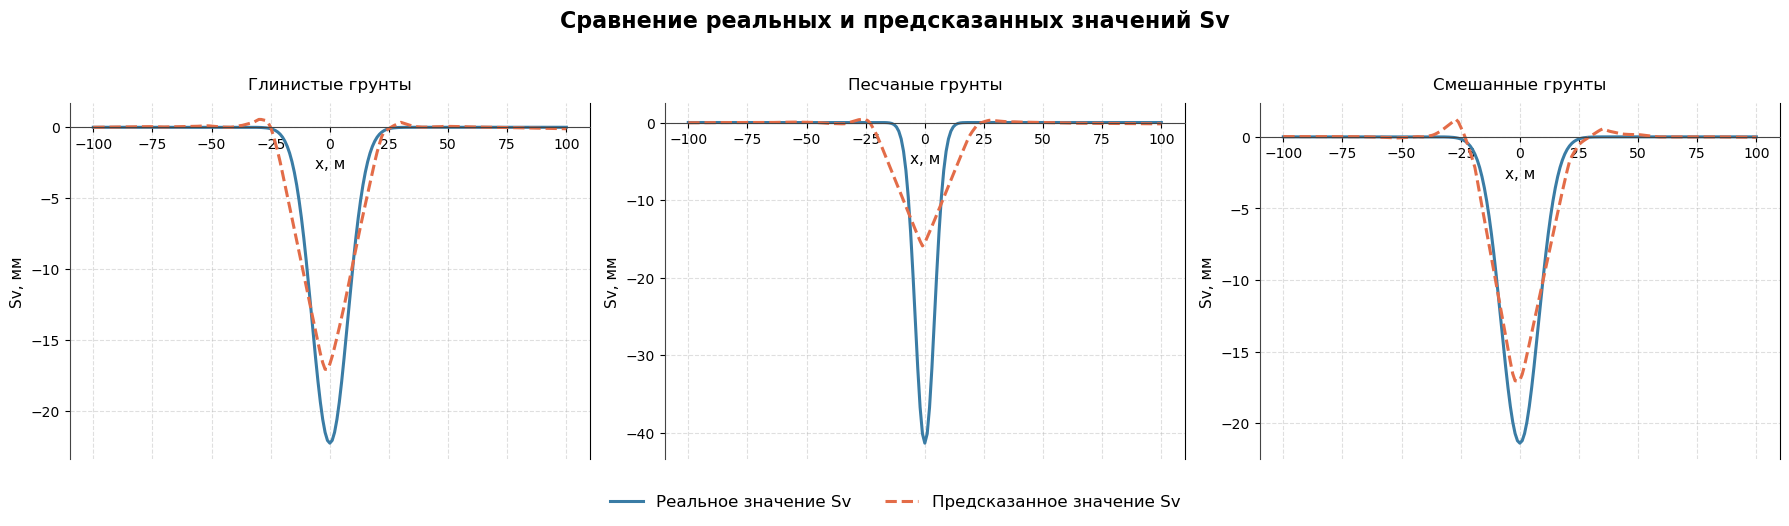

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Предсказанные значения: [[-0.1635454 ]
 [-7.7101493 ]
 [-7.3907733 ]
 [-0.07254127]]
Истинные значения: [-1.34953546e-03 -9.40439551e+00 -2.11095311e+00 -5.19913987e-05]
Ошибка RMSE: 2.77392e+00, ошибка MAE: 1.80219e+00
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Предсказанные значения: [[-0.1635454 ]
 [-7.7101493 ]
 [-7.3907733 ]
 [-0.07254127]]
Истинные значения: [-1.34953546e-03 -9.40439551e+00 -2.11095311e+00 -5.19913987e-05]
Ошибка RMSE: 2.77392e+00, ошибка MAE: 1.80219e+00


In [231]:
model_obj_Dense_600 = TunnelSettlementModelDense(data_600, new_data)

# # # Обучаем модель
dict_Dense_600 = model_obj_Dense_600.train_model()

model_obj_Dense_600.vizual_result()

y_pred, MAE_Dense_new_data_600 = model_obj_Dense_600.check_new_data(new_data, y_true)['y_pred'], model_obj_Dense_600.check_new_data(new_data, y_true)['MAE']

dict_score_time_Dense['Параметры выборки 600']=dict_Dense_600
dict_score_time_Dense_new_data['MAE для выборки 600']=  MAE_Dense_new_data_600 

#### Размер 1800

Epoch 1/300
37/37 - 2s - 61ms/step - loss: 33.2181 - val_loss: 27.3460
Epoch 2/300
37/37 - 0s - 2ms/step - loss: 32.4660 - val_loss: 26.4144
Epoch 3/300
37/37 - 0s - 2ms/step - loss: 31.2167 - val_loss: 25.1947
Epoch 4/300
37/37 - 0s - 2ms/step - loss: 29.9817 - val_loss: 24.4027
Epoch 5/300
37/37 - 0s - 2ms/step - loss: 29.1935 - val_loss: 23.9457
Epoch 6/300
37/37 - 0s - 2ms/step - loss: 28.6238 - val_loss: 23.4196
Epoch 7/300
37/37 - 0s - 2ms/step - loss: 27.8448 - val_loss: 22.6155
Epoch 8/300
37/37 - 0s - 2ms/step - loss: 26.8896 - val_loss: 21.6638
Epoch 9/300
37/37 - 0s - 2ms/step - loss: 25.6059 - val_loss: 20.3157
Epoch 10/300
37/37 - 0s - 2ms/step - loss: 23.8977 - val_loss: 18.6982
Epoch 11/300
37/37 - 0s - 2ms/step - loss: 21.9025 - val_loss: 17.0381
Epoch 12/300
37/37 - 0s - 2ms/step - loss: 20.0714 - val_loss: 15.6094
Epoch 13/300
37/37 - 0s - 2ms/step - loss: 18.4136 - val_loss: 14.5840
Epoch 14/300
37/37 - 0s - 2ms/step - loss: 17.1224 - val_loss: 13.8686
Epoch 15/300
3

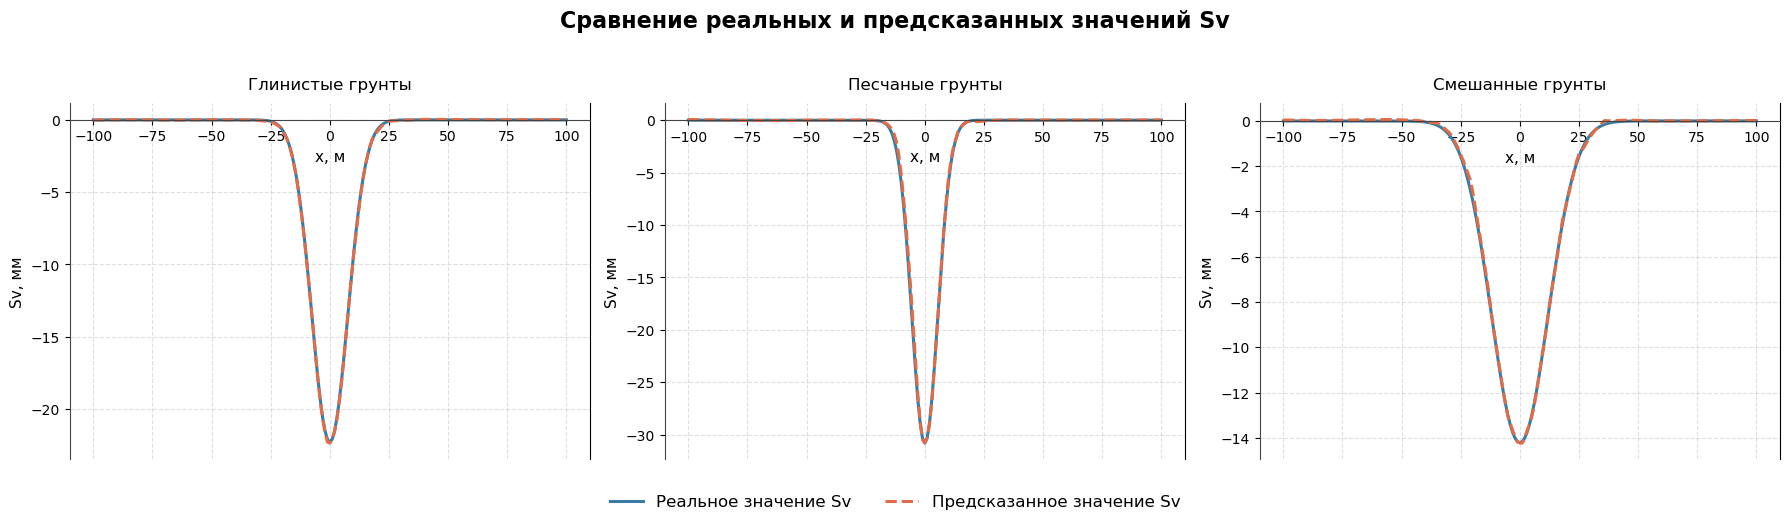

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Предсказанные значения: [[ 0.39866918]
 [-4.728652  ]
 [-2.16437   ]
 [ 0.01756233]]
Истинные значения: [-1.34953546e-03 -9.40439551e+00 -2.11095311e+00 -5.19913987e-05]
Ошибка RMSE: 2.34658e+00, ошибка MAE: 1.28670e+00
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Предсказанные значения: [[ 0.39866918]
 [-4.728652  ]
 [-2.16437   ]
 [ 0.01756233]]
Истинные значения: [-1.34953546e-03 -9.40439551e+00 -2.11095311e+00 -5.19913987e-05]
Ошибка RMSE: 2.34658e+00, ошибка MAE: 1.28670e+00


In [233]:
model_obj_Dense_1800 = TunnelSettlementModelDense(data_1800, new_data)

# # # Обучаем модель
dict_Dense_1800 = model_obj_Dense_1800.train_model()

model_obj_Dense_1800.vizual_result()

y_pred, MAE_Dense_new_data_1800 = model_obj_Dense_1800.check_new_data(new_data, y_true)['y_pred'], model_obj_Dense_1800.check_new_data(new_data, y_true)['MAE']

dict_score_time_Dense['Параметры выборки 1800']=dict_Dense_1800
dict_score_time_Dense_new_data['MAE для выборки 1800']=  MAE_Dense_new_data_1800 

#### Размер 4800

Epoch 1/300
97/97 - 1s - 9ms/step - loss: 31.2783 - val_loss: 23.0372
Epoch 2/300
97/97 - 0s - 1ms/step - loss: 28.6575 - val_loss: 20.6373
Epoch 3/300
97/97 - 0s - 1ms/step - loss: 26.0273 - val_loss: 18.7547
Epoch 4/300
97/97 - 0s - 1ms/step - loss: 22.3138 - val_loss: 14.8960
Epoch 5/300
97/97 - 0s - 1ms/step - loss: 17.5837 - val_loss: 11.8887
Epoch 6/300
97/97 - 0s - 1ms/step - loss: 14.0136 - val_loss: 9.2098
Epoch 7/300
97/97 - 0s - 1ms/step - loss: 11.0784 - val_loss: 7.4388
Epoch 8/300
97/97 - 0s - 1ms/step - loss: 8.6797 - val_loss: 5.2453
Epoch 9/300
97/97 - 0s - 1ms/step - loss: 6.7359 - val_loss: 3.7939
Epoch 10/300
97/97 - 0s - 2ms/step - loss: 5.4397 - val_loss: 2.9738
Epoch 11/300
97/97 - 0s - 1ms/step - loss: 4.2343 - val_loss: 2.4518
Epoch 12/300
97/97 - 0s - 1ms/step - loss: 3.5007 - val_loss: 1.7065
Epoch 13/300
97/97 - 0s - 1ms/step - loss: 2.8760 - val_loss: 1.3596
Epoch 14/300
97/97 - 0s - 1ms/step - loss: 2.4494 - val_loss: 1.1787
Epoch 15/300
97/97 - 0s - 2ms/s

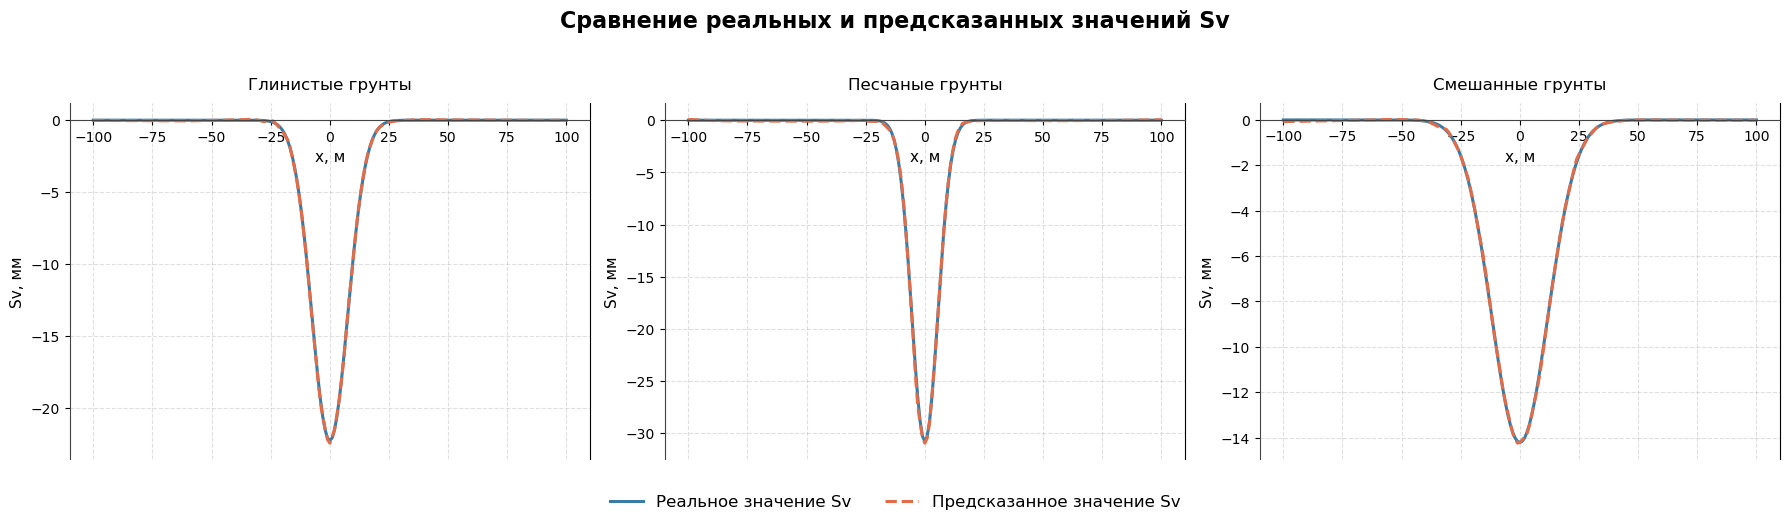

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Предсказанные значения: [[ 0.13226093]
 [-3.4667568 ]
 [-0.0346273 ]
 [-0.01541362]]
Истинные значения: [-1.34953546e-03 -9.40439551e+00 -2.11095311e+00 -5.19913987e-05]
Ошибка RMSE: 3.14582e+00, ошибка MAE: 2.04073e+00
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Предсказанные значения: [[ 0.13226093]
 [-3.4667568 ]
 [-0.0346273 ]
 [-0.01541362]]
Истинные значения: [-1.34953546e-03 -9.40439551e+00 -2.11095311e+00 -5.19913987e-05]
Ошибка RMSE: 3.14582e+00, ошибка MAE: 2.04073e+00


In [235]:
model_obj_Dense_4800 = TunnelSettlementModelDense(data_4800, new_data)

# # # Обучаем модель
dict_Dense_4800 = model_obj_Dense_4800.train_model()

model_obj_Dense_4800.vizual_result()

y_pred, MAE_Dense_new_data_4800 = model_obj_Dense_4800.check_new_data(new_data, y_true)['y_pred'], model_obj_Dense_4800.check_new_data(new_data, y_true)['MAE']

dict_score_time_Dense['Параметры выборки 4800']=dict_Dense_4800
dict_score_time_Dense_new_data['MAE для выборки 4800']=  MAE_Dense_new_data_4800 

#### Размер 7200

Epoch 1/300
145/145 - 1s - 6ms/step - loss: 136.3976 - val_loss: 160.7756
Epoch 2/300
145/145 - 0s - 1ms/step - loss: 124.1937 - val_loss: 150.0590
Epoch 3/300
145/145 - 0s - 1ms/step - loss: 118.5460 - val_loss: 142.4934
Epoch 4/300
145/145 - 0s - 1ms/step - loss: 106.6625 - val_loss: 121.4564
Epoch 5/300
145/145 - 0s - 1ms/step - loss: 83.7643 - val_loss: 93.5940
Epoch 6/300
145/145 - 0s - 2ms/step - loss: 63.5929 - val_loss: 71.6748
Epoch 7/300
145/145 - 0s - 1ms/step - loss: 48.7252 - val_loss: 54.0421
Epoch 8/300
145/145 - 0s - 1ms/step - loss: 37.6427 - val_loss: 41.1576
Epoch 9/300
145/145 - 0s - 1ms/step - loss: 29.7156 - val_loss: 31.8584
Epoch 10/300
145/145 - 0s - 1ms/step - loss: 23.7003 - val_loss: 25.8643
Epoch 11/300
145/145 - 0s - 1ms/step - loss: 20.1190 - val_loss: 20.1462
Epoch 12/300
145/145 - 0s - 1ms/step - loss: 16.8635 - val_loss: 17.4140
Epoch 13/300
145/145 - 0s - 1ms/step - loss: 14.6160 - val_loss: 15.4922
Epoch 14/300
145/145 - 0s - 1ms/step - loss: 12.6803

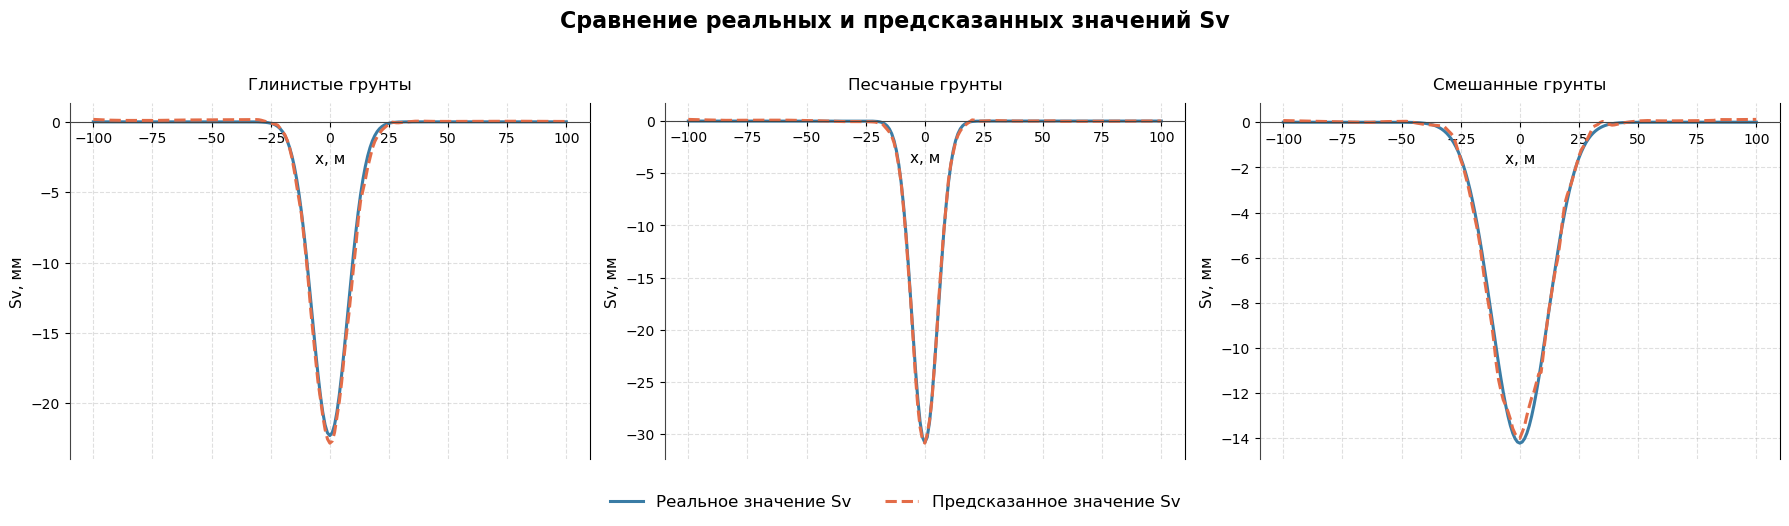

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Предсказанные значения: [[ -0.04274209]
 [-16.1492    ]
 [  0.22046821]
 [  0.04655044]]
Истинные значения: [-1.34953546e-03 -9.40439551e+00 -2.11095311e+00 -5.19913987e-05]
Ошибка RMSE: 3.56833e+00, ошибка MAE: 2.29106e+00
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Предсказанные значения: [[ -0.04274209]
 [-16.1492    ]
 [  0.22046821]
 [  0.04655044]]
Истинные значения: [-1.34953546e-03 -9.40439551e+00 -2.11095311e+00 -5.19913987e-05]
Ошибка RMSE: 3.56833e+00, ошибка MAE: 2.29106e+00


In [237]:
model_obj_Dense_7200 = TunnelSettlementModelDense(data_7200, new_data)

# # # Обучаем модель
dict_Dense_7200 = model_obj_Dense_7200.train_model()

model_obj_Dense_7200.vizual_result()

y_pred, MAE_Dense_new_data_7200 = model_obj_Dense_7200.check_new_data(new_data, y_true)['y_pred'], model_obj_Dense_7200.check_new_data(new_data, y_true)['MAE']

dict_score_time_Dense['Параметры выборки 7200']=dict_Dense_7200
dict_score_time_Dense_new_data['MAE для выборки 7200']=  MAE_Dense_new_data_7200 

#### Размер 14400

Epoch 1/300
290/290 - 1s - 4ms/step - loss: 133.3373 - val_loss: 131.3602
Epoch 2/300
290/290 - 0s - 2ms/step - loss: 119.3985 - val_loss: 123.3290
Epoch 3/300
290/290 - 1s - 2ms/step - loss: 97.0597 - val_loss: 83.7734
Epoch 4/300
290/290 - 0s - 1ms/step - loss: 64.9806 - val_loss: 57.9226
Epoch 5/300
290/290 - 0s - 952us/step - loss: 44.0214 - val_loss: 36.7522
Epoch 6/300
290/290 - 0s - 862us/step - loss: 27.1887 - val_loss: 23.7367
Epoch 7/300
290/290 - 0s - 1ms/step - loss: 17.8350 - val_loss: 16.1885
Epoch 8/300
290/290 - 0s - 937us/step - loss: 13.0099 - val_loss: 12.3277
Epoch 9/300
290/290 - 0s - 942us/step - loss: 10.0781 - val_loss: 10.6255
Epoch 10/300
290/290 - 0s - 957us/step - loss: 7.9667 - val_loss: 7.6558
Epoch 11/300
290/290 - 0s - 930us/step - loss: 6.4376 - val_loss: 6.8242
Epoch 12/300
290/290 - 0s - 961us/step - loss: 5.3068 - val_loss: 4.8275
Epoch 13/300
290/290 - 0s - 860us/step - loss: 4.5781 - val_loss: 4.2833
Epoch 14/300
290/290 - 0s - 934us/step - loss: 3

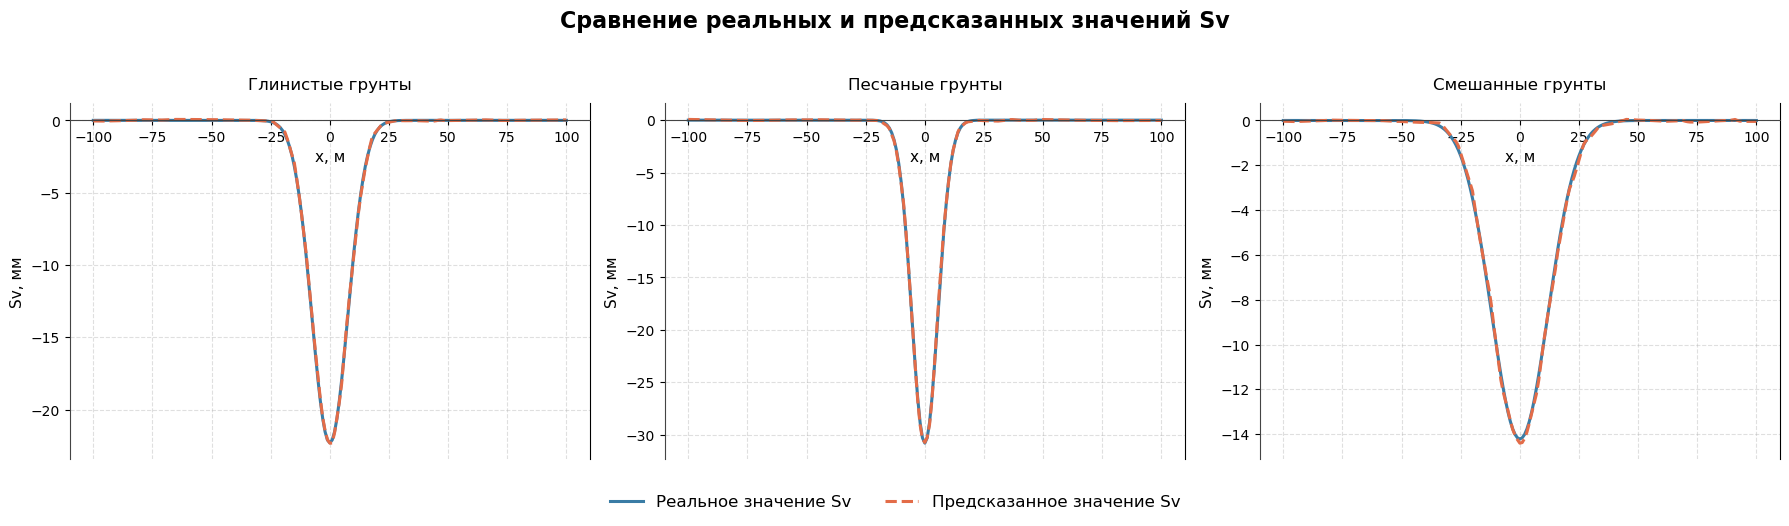

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Предсказанные значения: [[ -0.13324429]
 [-19.624546  ]
 [  0.05105518]
 [ -0.0710571 ]]
Истинные значения: [-1.34953546e-03 -9.40439551e+00 -2.11095311e+00 -5.19913987e-05]
Ошибка RMSE: 5.22370e+00, ошибка MAE: 3.14626e+00
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Предсказанные значения: [[ -0.13324429]
 [-19.624546  ]
 [  0.05105518]
 [ -0.0710571 ]]
Истинные значения: [-1.34953546e-03 -9.40439551e+00 -2.11095311e+00 -5.19913987e-05]
Ошибка RMSE: 5.22370e+00, ошибка MAE: 3.14626e+00


In [239]:
model_obj_Dense_14400 = TunnelSettlementModelDense(data_14400, new_data)

# # # Обучаем модель
dict_Dense_14400 = model_obj_Dense_14400.train_model()

model_obj_Dense_14400.vizual_result()

y_pred, MAE_Dense_new_data_14400 = model_obj_Dense_14400.check_new_data(new_data, y_true)['y_pred'], model_obj_Dense_14400.check_new_data(new_data, y_true)['MAE']

dict_score_time_Dense['Параметры выборки 14400']=dict_Dense_14400
dict_score_time_Dense_new_data['MAE для выборки 14400']=  MAE_Dense_new_data_14400 

#### Размер 28800

Epoch 1/300
579/579 - 1s - 2ms/step - loss: 113.9843 - val_loss: 62.1360
Epoch 2/300
579/579 - 1s - 1ms/step - loss: 37.7781 - val_loss: 15.2950
Epoch 3/300
579/579 - 1s - 919us/step - loss: 12.9593 - val_loss: 7.1110
Epoch 4/300
579/579 - 0s - 819us/step - loss: 6.7758 - val_loss: 6.1275
Epoch 5/300
579/579 - 0s - 800us/step - loss: 4.6045 - val_loss: 2.8613
Epoch 6/300
579/579 - 0s - 824us/step - loss: 3.2544 - val_loss: 2.2215
Epoch 7/300
579/579 - 1s - 1ms/step - loss: 2.6362 - val_loss: 3.0843
Epoch 8/300
579/579 - 1s - 1ms/step - loss: 1.8683 - val_loss: 1.7597
Epoch 9/300
579/579 - 0s - 832us/step - loss: 1.5569 - val_loss: 2.1956
Epoch 10/300
579/579 - 0s - 812us/step - loss: 1.2213 - val_loss: 0.7984
Epoch 11/300
579/579 - 1s - 919us/step - loss: 0.9559 - val_loss: 0.9820
Epoch 12/300
579/579 - 1s - 869us/step - loss: 0.7404 - val_loss: 0.3677
Epoch 13/300
579/579 - 1s - 902us/step - loss: 0.5615 - val_loss: 0.4562
Epoch 14/300
579/579 - 0s - 835us/step - loss: 0.5059 - val_lo

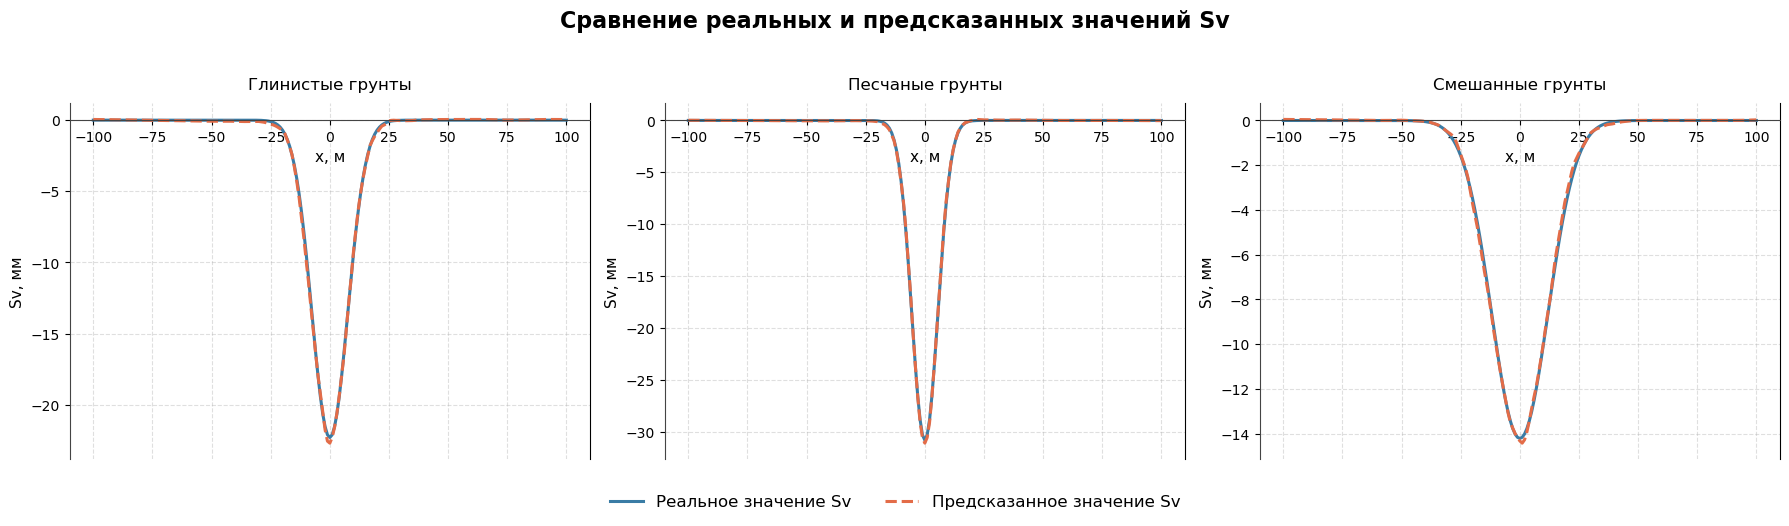

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Предсказанные значения: [[ 4.9276650e-04]
 [-1.5987000e+01]
 [ 4.0254667e-02]
 [ 7.7096969e-03]]
Истинные значения: [-1.34953546e-03 -9.40439551e+00 -2.11095311e+00 -5.19913987e-05]
Ошибка RMSE: 3.46260e+00, ошибка MAE: 2.18585e+00
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Предсказанные значения: [[ 4.9276650e-04]
 [-1.5987000e+01]
 [ 4.0254667e-02]
 [ 7.7096969e-03]]
Истинные значения: [-1.34953546e-03 -9.40439551e+00 -2.11095311e+00 -5.19913987e-05]
Ошибка RMSE: 3.46260e+00, ошибка MAE: 2.18585e+00


In [241]:
model_obj_Dense_28800 = TunnelSettlementModelDense(data_28800, new_data)

# # # Обучаем модель
dict_Dense_28800 = model_obj_Dense_28800.train_model()

model_obj_Dense_28800.vizual_result()

y_pred, MAE_Dense_new_data_28800 = model_obj_Dense_28800.check_new_data(new_data, y_true)['y_pred'], model_obj_Dense_28800.check_new_data(new_data, y_true)['MAE']

dict_score_time_Dense['Параметры выборки 28800']=dict_Dense_28800
dict_score_time_Dense_new_data['MAE для выборки 28800']=  MAE_Dense_new_data_28800 

In [242]:
dict_score_time_Dense

{'Параметры выборки 600': {'test_score': 1.0105738056428897,
  'elapsed_time': 6.4587318897247314},
 'Параметры выборки 1800': {'test_score': 0.07643927042131787,
  'elapsed_time': 21.344377040863037},
 'Параметры выборки 4800': {'test_score': 0.048861223763053636,
  'elapsed_time': 12.016173124313354},
 'Параметры выборки 7200': {'test_score': 0.19380861477839628,
  'elapsed_time': 11.962587833404541},
 'Параметры выборки 14400': {'test_score': 0.07497151983971714,
  'elapsed_time': 27.766204118728638},
 'Параметры выборки 28800': {'test_score': 0.06954842810905427,
  'elapsed_time': 21.642255783081055}}

In [243]:
dict_score_time_Dense_new_data

{'MAE для выборки 600': 1.8021878869760064,
 'MAE для выборки 1800': 1.2866983743898068,
 'MAE для выборки 4800': 2.040734150112091,
 'MAE для выборки 7200': 2.29105530745768,
 'MAE для выборки 14400': 3.146264672321132,
 'MAE для выборки 28800': 2.1858541807603804}

### Случайный лес

In [244]:
dict_score_time_RF = {}
dict_score_time_RF_new_data = {}

#### Размер 600

Лучшие параметры: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 500}
Train Score: 5.15e-01 RMSE
Test Score: 6.08e-01 RMSE


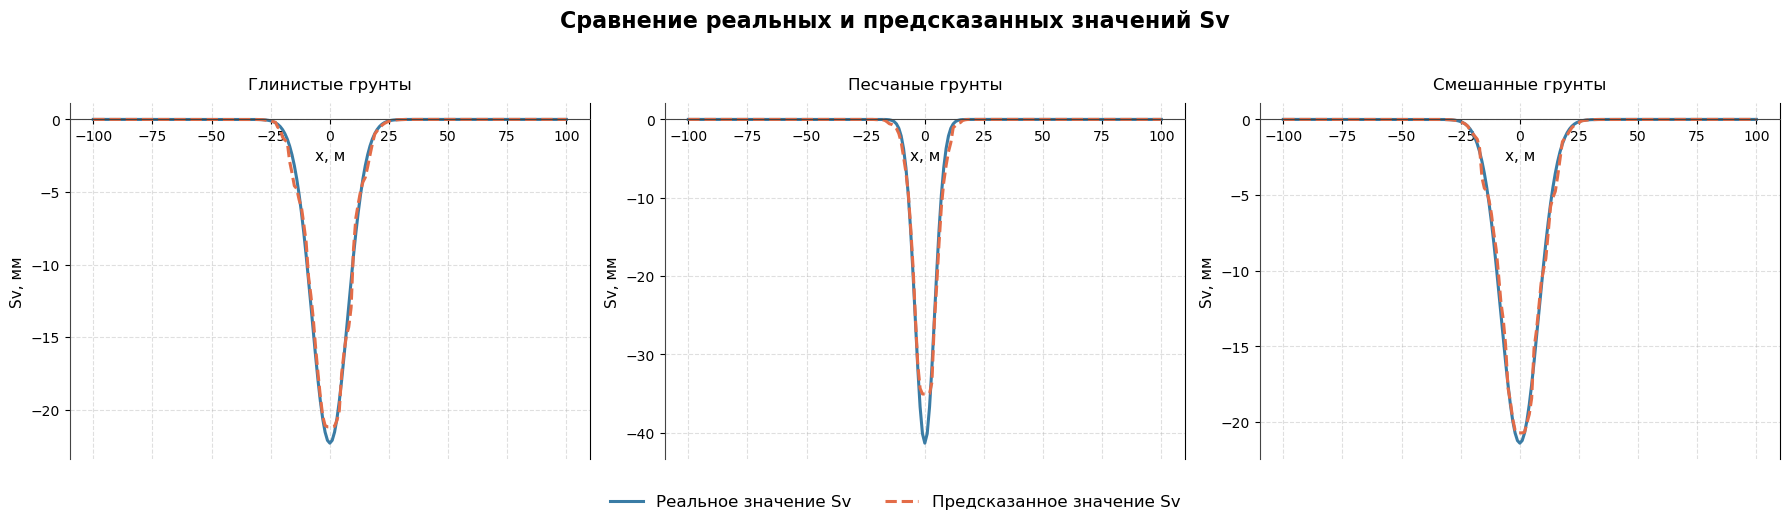

Предсказанные значения: [-6.90889641e-06 -9.83494394e+00 -2.89957642e+00 -1.10673084e-05]
Истинные значения: [-1.34953546e-03 -9.40439551e+00 -2.11095311e+00 -5.19913987e-05]
Ошибка RMSE: 4.49250e-01, ошибка MAE: 3.05139e-01
Предсказанные значения: [-6.90889641e-06 -9.83494394e+00 -2.89957642e+00 -1.10673084e-05]
Истинные значения: [-1.34953546e-03 -9.40439551e+00 -2.11095311e+00 -5.19913987e-05]
Ошибка RMSE: 4.49250e-01, ошибка MAE: 3.05139e-01


In [246]:

model_obj_RF_600 = TunnelSettlementModelRandomForest(data_600, new_data)


dict_RF_600 = model_obj_RF_600.train_model()

model_obj_RF_600.vizual_result()


y_pred, MAE_RF_new_data_600 = model_obj_RF_600.check_new_data(new_data, y_true)['y_pred'], model_obj_RF_600.check_new_data(new_data, y_true)['MAE']

dict_score_time_RF['Параметры выборки 600']=dict_RF_600
dict_score_time_RF_new_data['MAE для выборки 600']=  MAE_RF_new_data_600 

#### Размер 1800

Лучшие параметры: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 25}
Train Score: 4.65e-01 RMSE
Test Score: 7.41e-01 RMSE


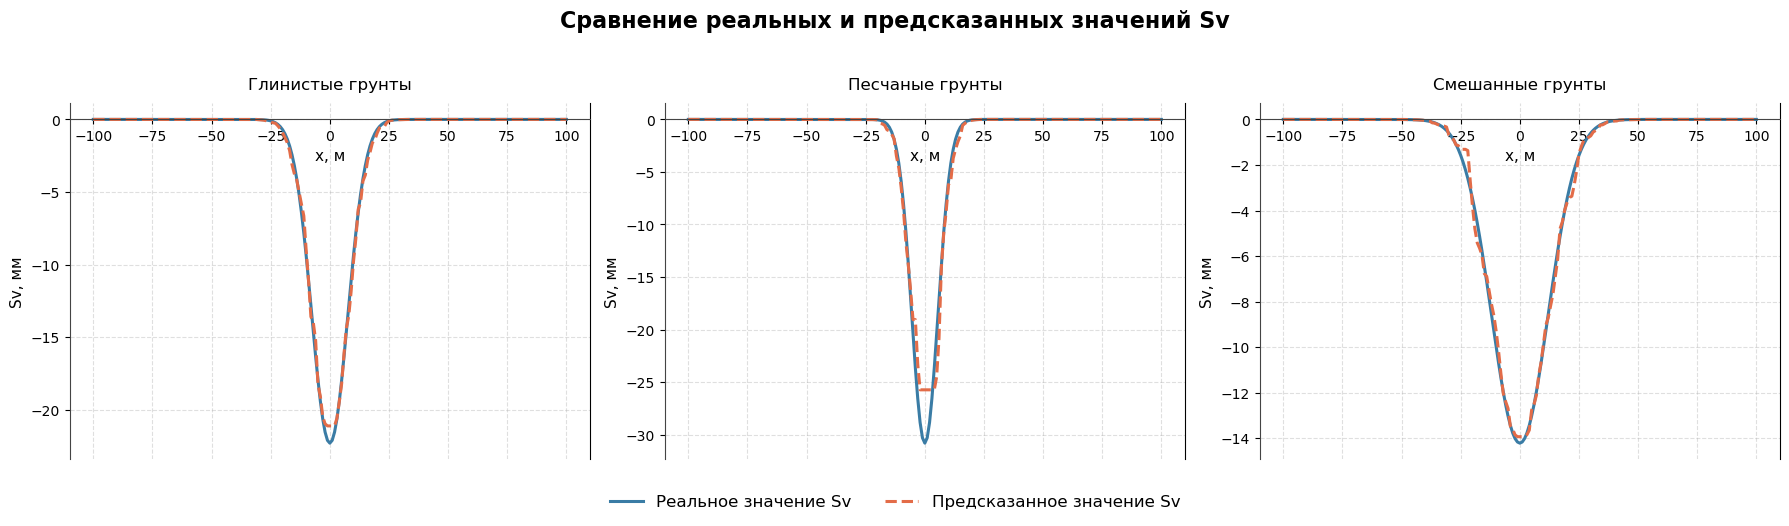

Предсказанные значения: [-1.52399972e-03 -9.54849460e+00 -2.65049551e+00 -4.61425260e-05]
Истинные значения: [-1.34953546e-03 -9.40439551e+00 -2.11095311e+00 -5.19913987e-05]
Ошибка RMSE: 2.79227e-01, ошибка MAE: 1.70955e-01
Предсказанные значения: [-1.52399972e-03 -9.54849460e+00 -2.65049551e+00 -4.61425260e-05]
Истинные значения: [-1.34953546e-03 -9.40439551e+00 -2.11095311e+00 -5.19913987e-05]
Ошибка RMSE: 2.79227e-01, ошибка MAE: 1.70955e-01


In [247]:

model_obj_RF_1800 = TunnelSettlementModelRandomForest(data_1800, new_data)


dict_RF_1800 = model_obj_RF_1800.train_model()

model_obj_RF_1800.vizual_result()


y_pred, MAE_RF_new_data_1800 = model_obj_RF_1800.check_new_data(new_data, y_true)['y_pred'], model_obj_RF_1800.check_new_data(new_data, y_true)['MAE']

dict_score_time_RF['Параметры выборки 1800']=dict_RF_1800
dict_score_time_RF_new_data['MAE для выборки 1800']=  MAE_RF_new_data_1800 

#### Размер 4800

Лучшие параметры: {'max_depth': 50, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 200}
Train Score: 1.51e-01 RMSE
Test Score: 3.09e-01 RMSE


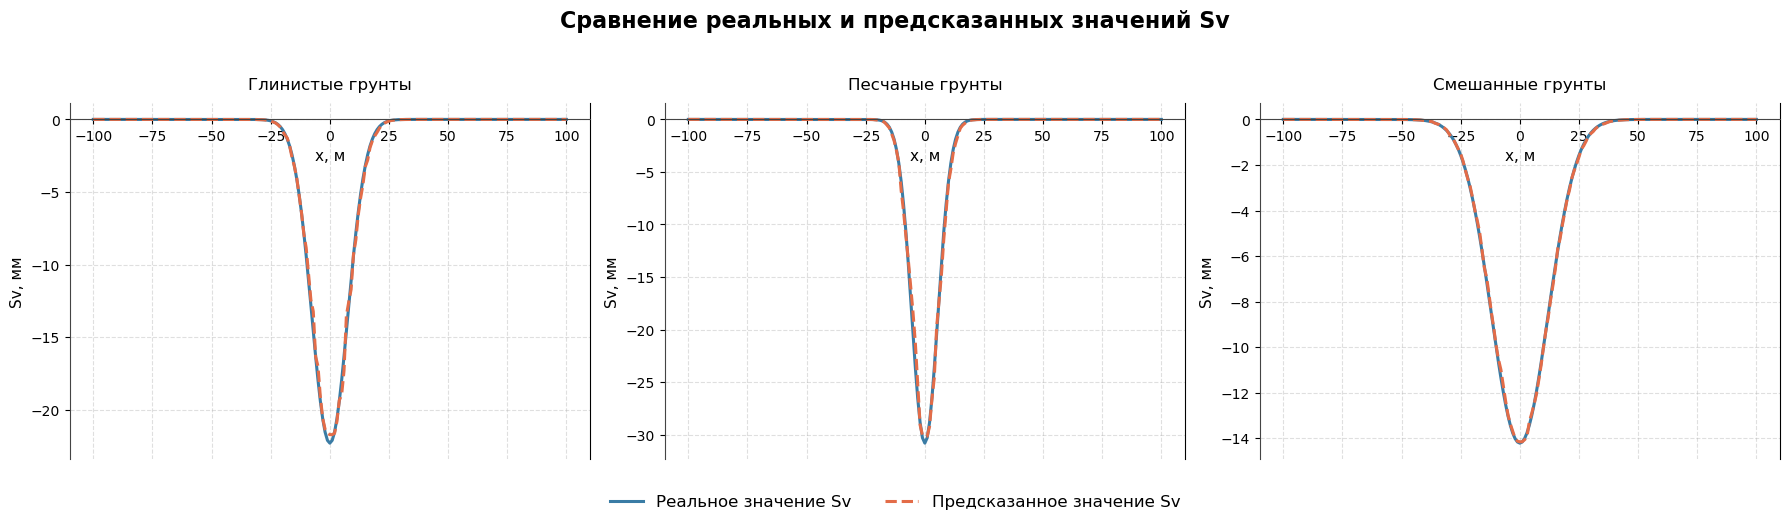

Предсказанные значения: [-1.36999548e-03 -9.45708145e+00 -2.86556592e+00 -7.32921690e-05]
Истинные значения: [-1.34953546e-03 -9.40439551e+00 -2.11095311e+00 -5.19913987e-05]
Ошибка RMSE: 3.78225e-01, ошибка MAE: 2.01835e-01
Предсказанные значения: [-1.36999548e-03 -9.45708145e+00 -2.86556592e+00 -7.32921690e-05]
Истинные значения: [-1.34953546e-03 -9.40439551e+00 -2.11095311e+00 -5.19913987e-05]
Ошибка RMSE: 3.78225e-01, ошибка MAE: 2.01835e-01


In [249]:
model_obj_RF_4800 = TunnelSettlementModelRandomForest(data_4800, new_data)


dict_RF_4800 = model_obj_RF_4800.train_model()

model_obj_RF_4800.vizual_result()


y_pred, MAE_RF_new_data_4800 = model_obj_RF_4800.check_new_data(new_data, y_true)['y_pred'], model_obj_RF_4800.check_new_data(new_data, y_true)['MAE']

dict_score_time_RF['Параметры выборки 4800']=dict_RF_4800
dict_score_time_RF_new_data['MAE для выборки 4800']=  MAE_RF_new_data_4800

#### Размер 7200

Лучшие параметры: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 200}
Train Score: 6.64e-01 RMSE
Test Score: 9.93e-01 RMSE


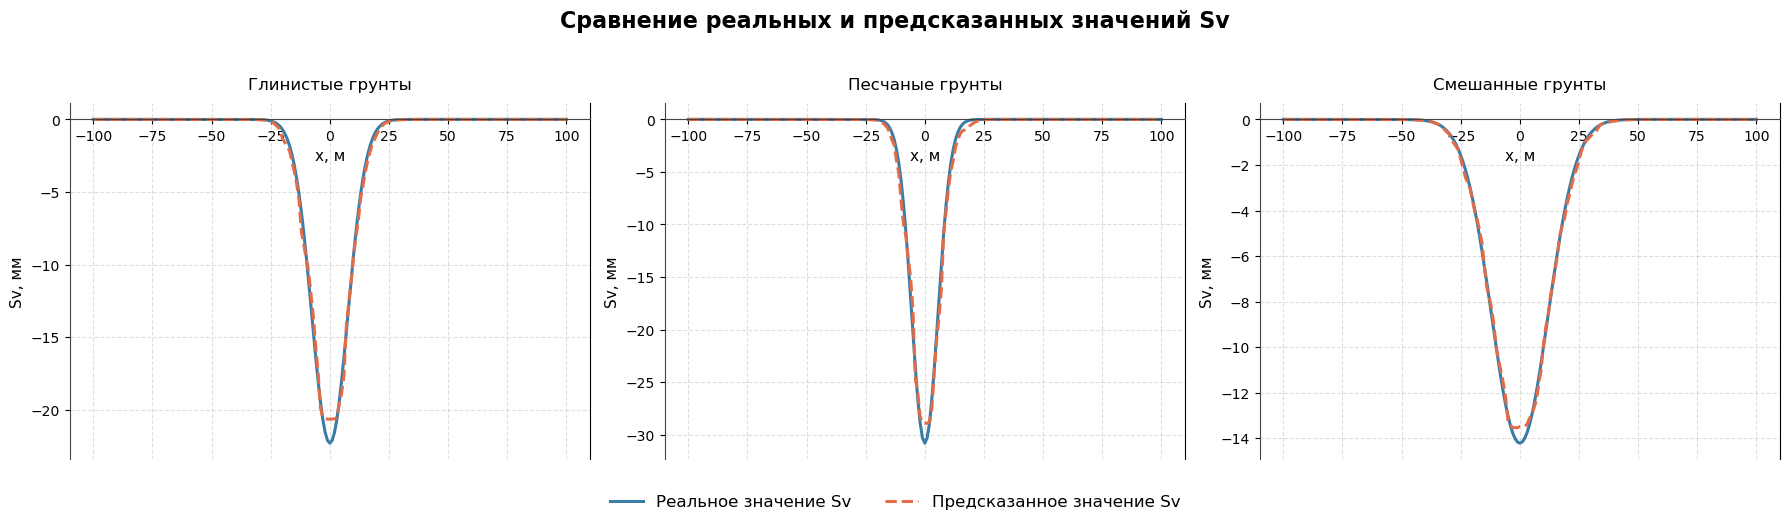

Предсказанные значения: [-1.54490436e-03 -9.57555008e+00 -3.08144282e+00 -7.18151310e-05]
Истинные значения: [-1.34953546e-03 -9.40439551e+00 -2.11095311e+00 -5.19913987e-05]
Ошибка RMSE: 4.92733e-01, ошибка MAE: 2.85465e-01
Предсказанные значения: [-1.54490436e-03 -9.57555008e+00 -3.08144282e+00 -7.18151310e-05]
Истинные значения: [-1.34953546e-03 -9.40439551e+00 -2.11095311e+00 -5.19913987e-05]
Ошибка RMSE: 4.92733e-01, ошибка MAE: 2.85465e-01


In [250]:
model_obj_RF_7200 = TunnelSettlementModelRandomForest(data_7200, new_data)


dict_RF_7200 = model_obj_RF_7200.train_model()

model_obj_RF_7200.vizual_result()


y_pred, MAE_RF_new_data_7200 = model_obj_RF_7200.check_new_data(new_data, y_true)['y_pred'], model_obj_RF_7200.check_new_data(new_data, y_true)['MAE']

dict_score_time_RF['Параметры выборки 7200']=dict_RF_7200
dict_score_time_RF_new_data['MAE для выборки 7200']=  MAE_RF_new_data_7200

#### Размер 14400

Лучшие параметры: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 200}
Train Score: 2.93e-01 RMSE
Test Score: 6.75e-01 RMSE


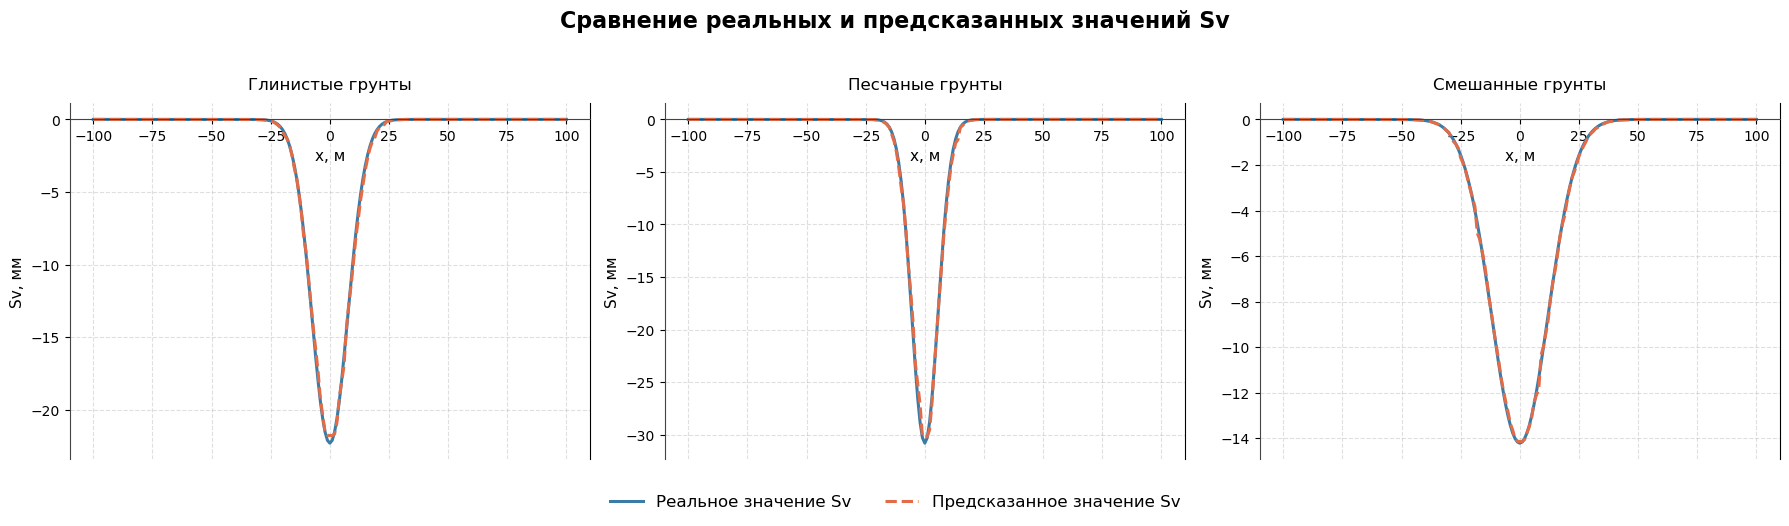

Предсказанные значения: [-1.45519654e-03 -9.56284715e+00 -2.76492909e+00 -5.68665031e-05]
Истинные значения: [-1.34953546e-03 -9.40439551e+00 -2.11095311e+00 -5.19913987e-05]
Ошибка RMSE: 3.36449e-01, ошибка MAE: 2.03135e-01
Предсказанные значения: [-1.45519654e-03 -9.56284715e+00 -2.76492909e+00 -5.68665031e-05]
Истинные значения: [-1.34953546e-03 -9.40439551e+00 -2.11095311e+00 -5.19913987e-05]
Ошибка RMSE: 3.36449e-01, ошибка MAE: 2.03135e-01


In [251]:
model_obj_RF_14400 = TunnelSettlementModelRandomForest(data_14400, new_data)


dict_RF_14400 = model_obj_RF_14400.train_model()

model_obj_RF_14400.vizual_result()


y_pred, MAE_RF_new_data_14400 = model_obj_RF_14400.check_new_data(new_data, y_true)['y_pred'], model_obj_RF_14400.check_new_data(new_data, y_true)['MAE']

dict_score_time_RF['Параметры выборки 14400']=dict_RF_14400
dict_score_time_RF_new_data['MAE для выборки 14400']=  MAE_RF_new_data_14400

#### Размер 28800

Лучшие параметры: {'max_depth': 50, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 500}
Train Score: 9.51e-02 RMSE
Test Score: 1.76e-01 RMSE


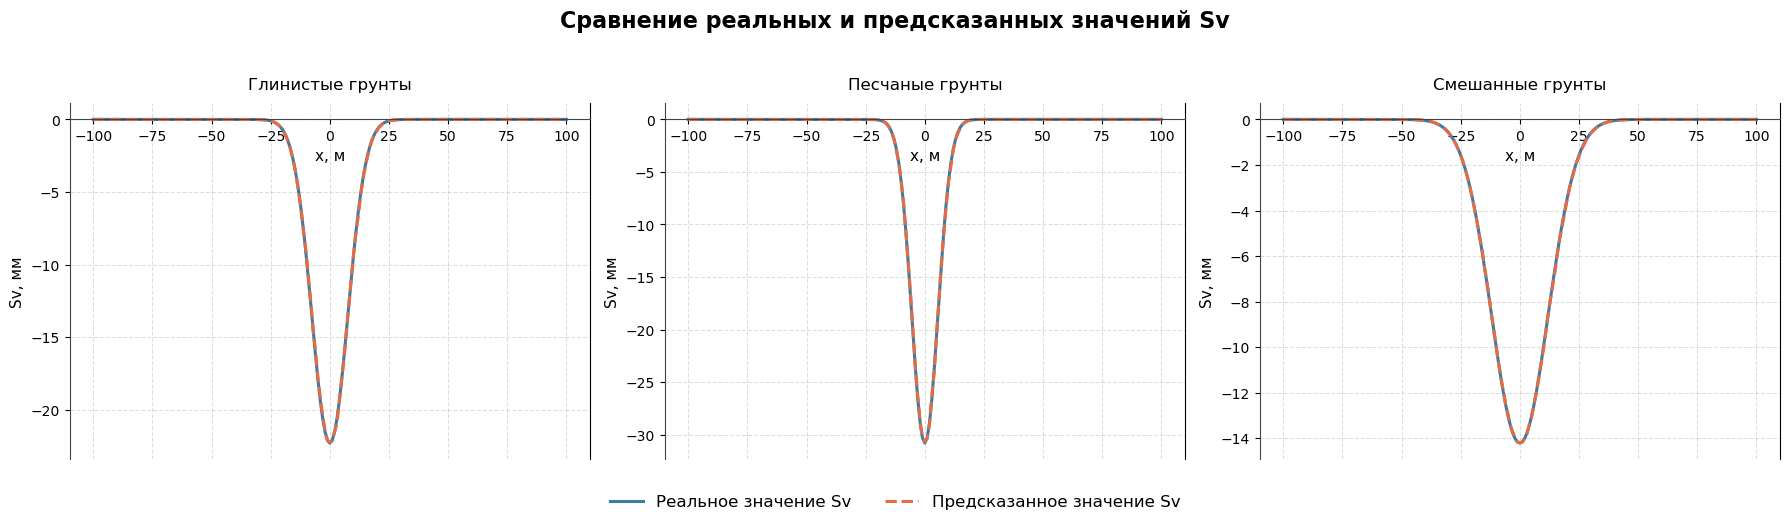

Предсказанные значения: [-1.51324357e-03 -9.46332060e+00 -2.17791465e+00 -5.83252169e-05]
Истинные значения: [-1.34953546e-03 -9.40439551e+00 -2.11095311e+00 -5.19913987e-05]
Ошибка RMSE: 4.45983e-02, ошибка MAE: 3.15142e-02
Предсказанные значения: [-1.51324357e-03 -9.46332060e+00 -2.17791465e+00 -5.83252169e-05]
Истинные значения: [-1.34953546e-03 -9.40439551e+00 -2.11095311e+00 -5.19913987e-05]
Ошибка RMSE: 4.45983e-02, ошибка MAE: 3.15142e-02


In [252]:
model_obj_RF_28800 = TunnelSettlementModelRandomForest(data_28800, new_data)


dict_RF_28800 = model_obj_RF_28800.train_model()

model_obj_RF_28800.vizual_result()


y_pred, MAE_RF_new_data_28800 = model_obj_RF_28800.check_new_data(new_data, y_true)['y_pred'], model_obj_RF_28800.check_new_data(new_data, y_true)['MAE']

dict_score_time_RF['Параметры выборки 28800']=dict_RF_28800
dict_score_time_RF_new_data['MAE для выборки 28800']=  MAE_RF_new_data_28800

In [253]:
dict_score_time_RF

{'Параметры выборки 600': {'test_score': 0.17987601870409642,
  'elapsed_time': 118.19354605674744},
 'Параметры выборки 1800': {'test_score': 0.2288483018125394,
  'elapsed_time': 172.17037725448608},
 'Параметры выборки 4800': {'test_score': 0.0928486056607769,
  'elapsed_time': 326.69293332099915},
 'Параметры выборки 7200': {'test_score': 0.2928806925109952,
  'elapsed_time': 442.17817187309265},
 'Параметры выборки 14400': {'test_score': 0.15539088878987442,
  'elapsed_time': 821.5525670051575},
 'Параметры выборки 28800': {'test_score': 0.04442994674835441,
  'elapsed_time': 1545.1817278862}}

In [254]:
dict_score_time_RF_new_data

{'MAE для выборки 600': 0.3051388228833954,
 'MAE для выборки 1800': 0.17095545101776569,
 'MAE для выборки 4800': 0.20183512779066048,
 'MAE для выборки 7200': 0.2854648692943835,
 'MAE для выборки 14400': 0.20313453805606072,
 'MAE для выборки 28800': 0.03151416793534057}

In [301]:
dict_score_time_RF_new_data

{'MAE для выборки 600': 0.3051388228833954,
 'MAE для выборки 1800': 0.17095545101776569,
 'MAE для выборки 4800': 0.20183512779066048,
 'MAE для выборки 7200': 0.2854648692943835,
 'MAE для выборки 14400': 0.20313453805606072,
 'MAE для выборки 28800': 0.03151416793534057}

In [297]:
def plot_4_models_effect_log(dict1, dict2, dict3, dict4,
                         names=("Модель 1", "Модель 2", "Модель 3", "Модель 4")):

    # Создаем сетку 2x2
    fig, axes = plt.subplots(2, 2, figsize=(16, 8))
    axes = axes.ravel()

    model_dicts = [dict1, dict2, dict3, dict4]

    for ax, model_dict, title in zip(axes, model_dicts, names):

        # ---- ВСТАВЛЯЕМ ТВОЮ ЛОГИКУ ПОСТРОЕНИЯ ----
        eff = {k: v['test_score'] * np.log(v['elapsed_time']) for k, v in model_dict.items()}

        labels = [key.split()[-1] for key in eff.keys()]
        values = list(eff.values())

        bar_color = "#3A7CA5"
        edge_color = "#2a5675"

        bars = ax.bar(
            labels, values,
            color=bar_color,
            edgecolor=edge_color,
            linewidth=1.4
        )

        ax.set_title(title,
                     fontsize=15,
                     fontweight="bold",
                     pad=10)

        ax.set_xlabel("Размер выборки", fontsize=12)
        ax.set_ylabel("MAE × log(Time)", fontsize=12)

        ax.grid(True, linestyle='--', alpha=0.35)

        # Оформление осей в стиле Sv-графиков
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_color('#444')
        ax.spines['bottom'].set_color('#444')

        ax.tick_params(axis='both', labelsize=11)

        # Подписи над столбцами
        for bar in bars:
            h = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                h,
                f"{h:.3f}",
                ha='center', va='bottom',
                fontsize=10
            )

    # Общий заголовок для всей фигуры
    fig.suptitle(
        "Сравнение эффективности моделей\nMAE × log(Time)",
        fontsize=18,
        fontweight='bold',
        y=1.02
    )

    plt.tight_layout()
    plt.show()



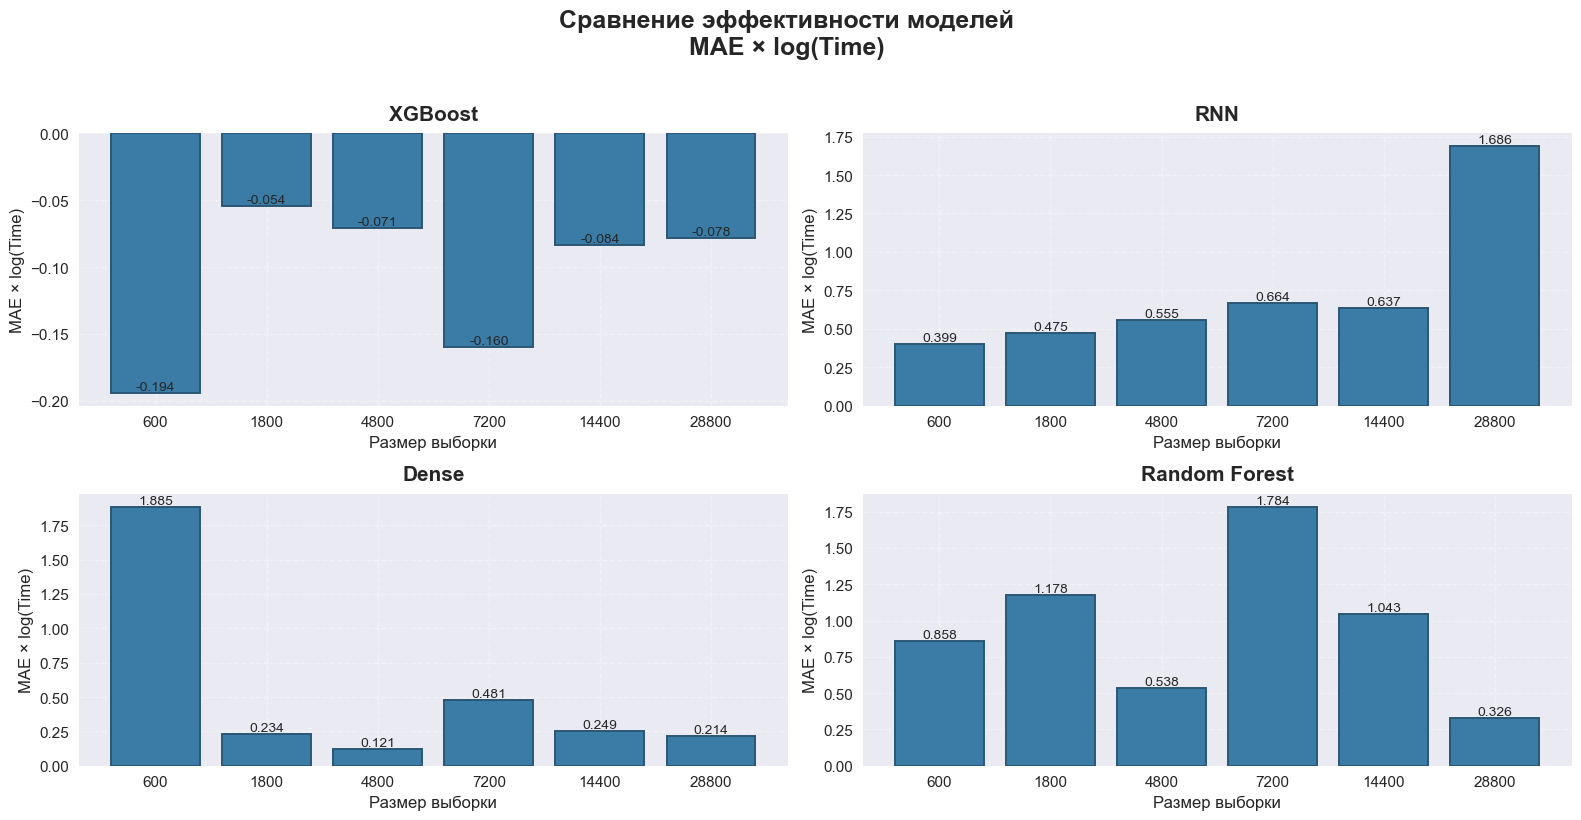

In [298]:
plot_4_models_effect_log(dict_score_time_GB,dict_score_time_RNN,dict_score_time_Dense,dict_score_time_RF,names=('XGBoost','RNN','Dense','Random Forest',))


In [299]:
def plot_4_models_effect(dict1, dict2, dict3, dict4,
                         names=("Модель 1", "Модель 2", "Модель 3", "Модель 4")):

    # Создаем сетку 2x2
    fig, axes = plt.subplots(2, 2, figsize=(16, 8))
    axes = axes.ravel()

    model_dicts = [dict1, dict2, dict3, dict4]

    for ax, model_dict, title in zip(axes, model_dicts, names):

        # ---- ВСТАВЛЯЕМ ТВОЮ ЛОГИКУ ПОСТРОЕНИЯ ----
        eff = {k: v['test_score'] * (v['elapsed_time']) for k, v in model_dict.items()}

        labels = [key.split()[-1] for key in eff.keys()]
        values = list(eff.values())

        bar_color = "#3A7CA5"
        edge_color = "#2a5675"

        bars = ax.bar(
            labels, values,
            color=bar_color,
            edgecolor=edge_color,
            linewidth=1.4
        )

        ax.set_title(title,
                     fontsize=15,
                     fontweight="bold",
                     pad=10)

        ax.set_xlabel("Размер выборки", fontsize=12)
        ax.set_ylabel("MAE × Time", fontsize=12)

        ax.grid(True, linestyle='--', alpha=0.35)

        # Оформление осей в стиле Sv-графиков
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_color('#444')
        ax.spines['bottom'].set_color('#444')

        ax.tick_params(axis='both', labelsize=11)

        # Подписи над столбцами
        for bar in bars:
            h = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                h,
                f"{h:.3f}",
                ha='center', va='bottom',
                fontsize=10
            )

    # Общий заголовок для всей фигуры
    fig.suptitle(
        "Сравнение эффективности моделей\nMAE × log(Time)",
        fontsize=18,
        fontweight='bold',
        y=1.02
    )

    plt.tight_layout()
    plt.show()

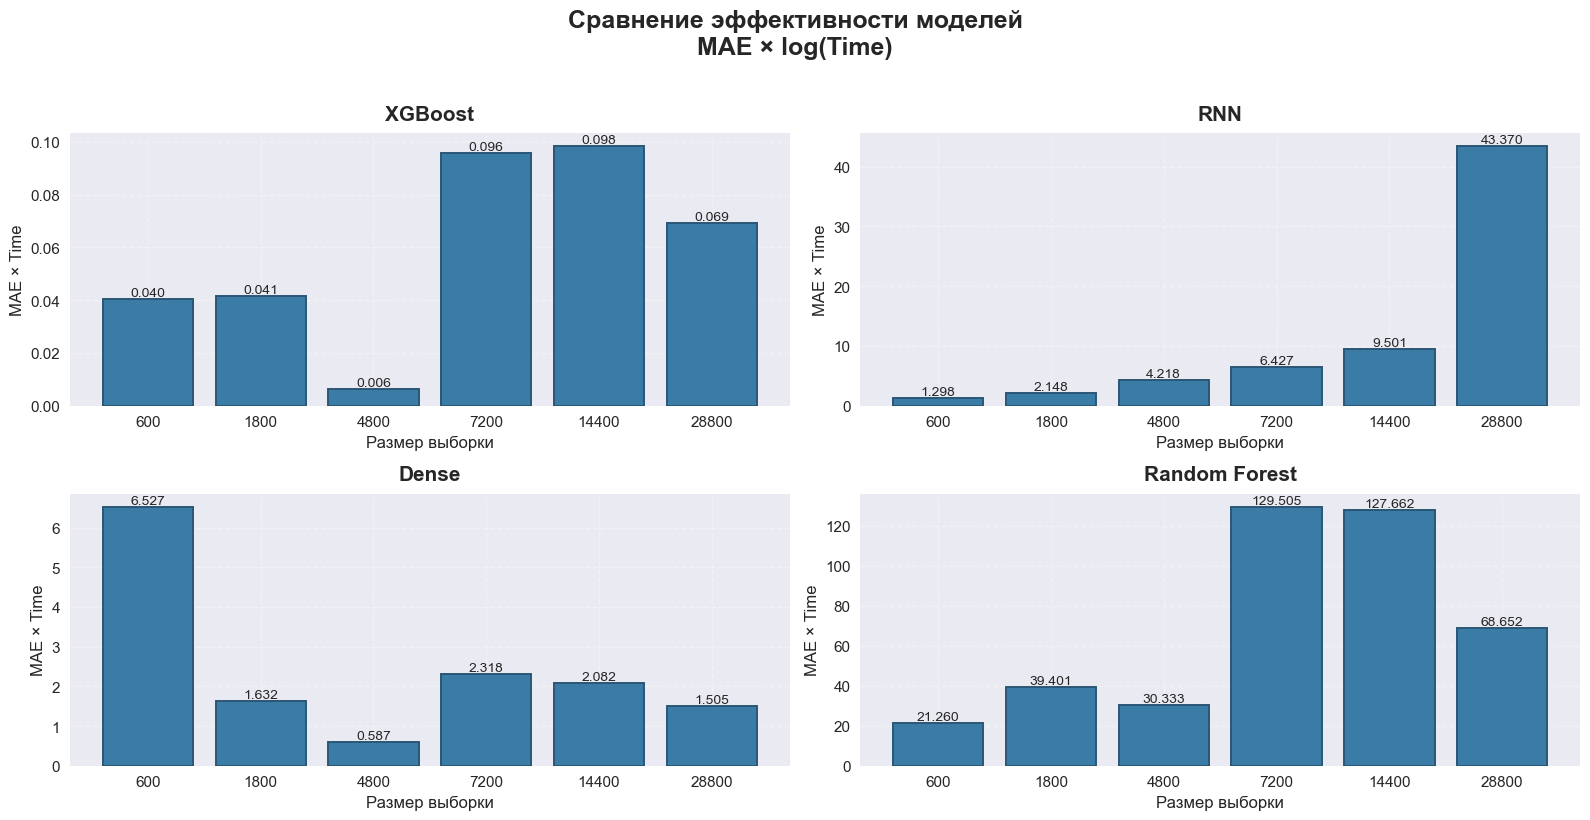

In [300]:
plot_4_models_effect(dict_score_time_GB,dict_score_time_RNN,dict_score_time_Dense,dict_score_time_RF,names=('XGBoost','RNN','Dense','Random Forest',))

In [305]:


def plot_4_models_mae(dict1, dict2, dict3, dict4,
                       names=("Модель 1", "Модель 2", "Модель 3", "Модель 4")):

    # Создаем сетку 2x2
    fig, axes = plt.subplots(2, 2, figsize=(16, 8))
    axes = axes.ravel()

    model_dicts = [dict1, dict2, dict3, dict4]

    for ax, model_dict, title in zip(axes, model_dicts, names):

        # Берем ключи словаря и значения MAE
        labels = [key.split()[-1] for key in model_dict.keys()]  # "600", "1800" и т.д.
        values = list(model_dict.values())

        bar_color = "#3A7CA5"
        edge_color = "#2a5675"

        bars = ax.bar(
            labels, values,
            color=bar_color,
            edgecolor=edge_color,
            linewidth=1.4
        )

        ax.set_title(title,
                     fontsize=15,
                     fontweight="bold",
                     pad=10)

        ax.set_xlabel("Размер выборки", fontsize=12)
        ax.set_ylabel("MAE", fontsize=12)

        ax.grid(True, linestyle='--', alpha=0.35)

        # Оформление осей
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_color('#444')
        ax.spines['bottom'].set_color('#444')

        ax.tick_params(axis='both', labelsize=11)

        # Подписи над столбцами
        for bar in bars:
            h = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                h,
                f"{h:.3f}",
                ha='center', va='bottom',
                fontsize=10
            )

    # Общий заголовок
    fig.suptitle(
        "Сравнение эффективности моделей\nMAE",
        fontsize=18,
        fontweight='bold',
        y=1.02
    )

    plt.tight_layout()
    plt.show()


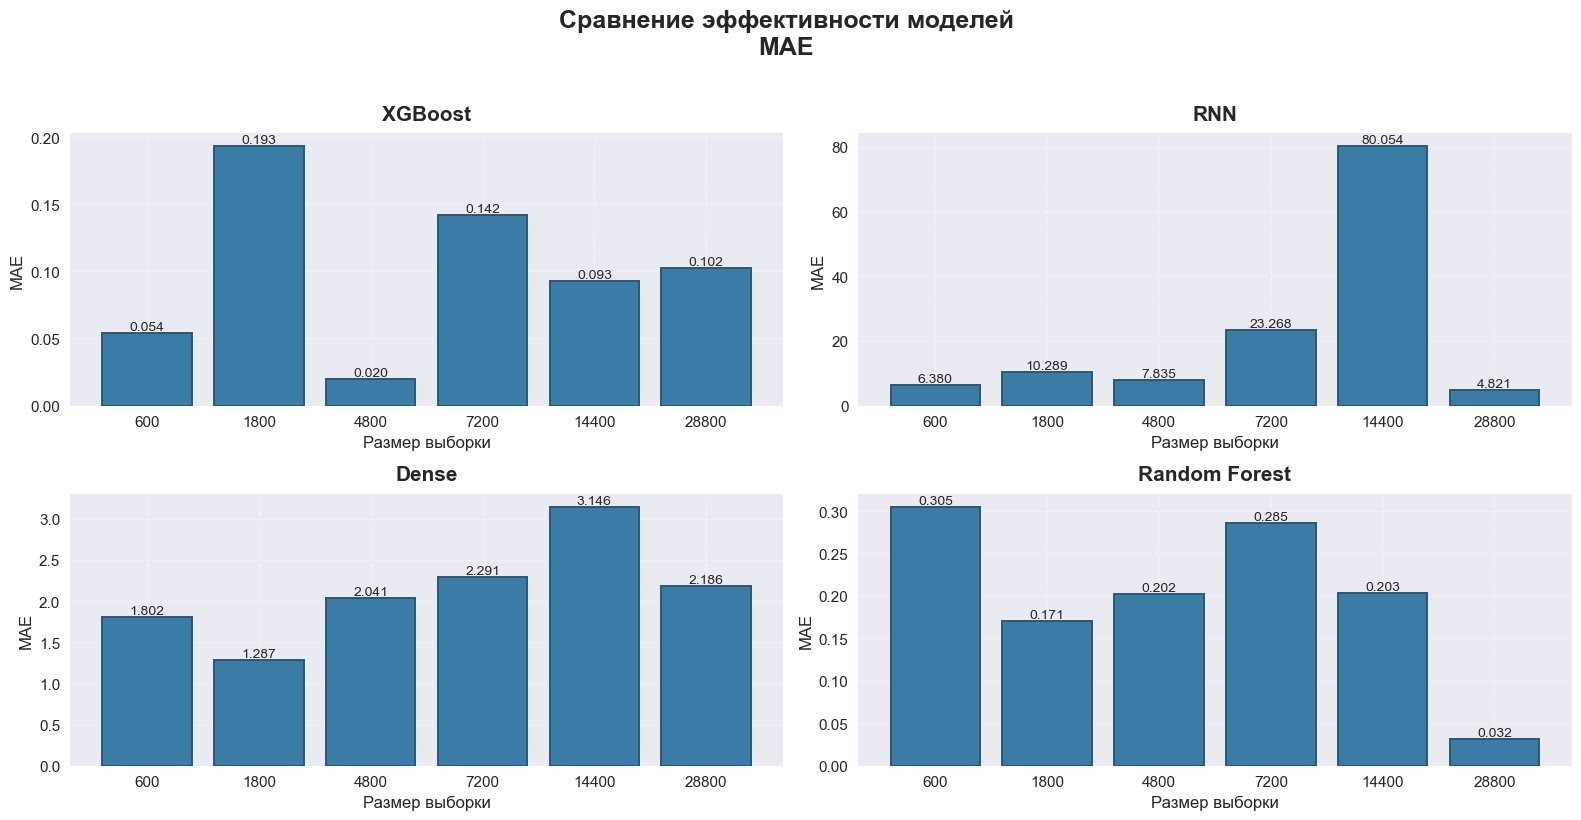

In [306]:
plot_4_models_mae(dict_score_time_GB_new_data,dict_score_time_RNN_new_data,dict_score_time_Dense_new_data,dict_score_time_RF_new_data,names=('XGBoost','RNN','Dense','Random Forest',))